# CSoNet 2026 Semantic Annotation — Gemini 2.5 Flash-Lite

This notebook generates full-dataset semantic annotations for the CSoNet 2026 Reddit inter-community conflict prediction study using Gemini 2.5 Flash-Lite. It applies the paper's leakage-controlled annotation protocol: each row is labeled from the post text, source community, and target community only; outcome labels, train/validation/test membership, future information, target-derived features, and model predictions are not provided to the annotator.

**Recommended runtime:** Google Colab standard CPU runtime is sufficient for API-based annotation. High-RAM is recommended for loading and merging full-dataset artifacts; a GPU is not required unless later cells are adapted for local inference.

**Repository role:** Run this notebook before model training if Gemini semantic features need to be regenerated. The main outputs are structured semantic-label files, diagnostics, parse/error logs, and manifest files saved to Google Drive so runs can resume after interruption.

**Reproducibility note:** Keep API keys outside the notebook, avoid committing raw/private credentials, and preserve the output manifest with any released annotation artifact.


In [98]:
# Cell 1: Install packages, mount Drive, and import dependencies

from google.colab import drive, userdata
drive.mount('/content/drive')

!pip -q install -U google-genai pyarrow pydantic tqdm psutil scipy seaborn scikit-learn statsmodels openpyxl

import os
import re
import gc
import csv
import json
import time
import math
import pickle
import random
import hashlib
import traceback
from pathlib import Path
from datetime import datetime, timezone
from typing import Literal

import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, fisher_exact
from scipy.spatial.distance import jensenshannon
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm
from pydantic import BaseModel, ConfigDict, Field, ValidationError

from google import genai
from google.genai import types

print("google-genai imported successfully")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
google-genai imported successfully


In [99]:
# Cell 2: Configuration
from getpass import getpass

PROJECT_ROOT = Path("/content/drive/MyDrive/csonet2026_conflict_prediction")
DATA_DIR = PROJECT_ROOT / "conflict_data"
DETAIL_DIR = DATA_DIR / "detailed_data"
EMBED_DIR = DATA_DIR / "embeddings"
RESULTS_DIR = PROJECT_ROOT / "results"

META_SPLIT_PATH = RESULTS_DIR / "pickle_metafeatures_original_splits.parquet"
SPLIT_IDS_PATH = RESULTS_DIR / "original_split_ids_extracted.csv"
WORD_MAP_PATH = RESULTS_DIR / "token_id_to_word.parquet"
RECOVERED_TEXT_PATH = RESULTS_DIR / "recovered_tokenized_post_text.parquet"
RECOVERED_SPLIT_TEXT_PATH = RESULTS_DIR / "recovered_text_original_splits.parquet"
CROSSLINK_MAP_PATH = RESULTS_DIR / "crosslink_post_target_map.parquet"

TOKENIZED_POSTS_PATH = DETAIL_DIR / "tokenized_posts.tsv"
CROSSLINKS_PATH = DETAIL_DIR / "post_crosslinks_info.tsv"
GLOVE_PATH = EMBED_DIR / "glove_word_embeds.txt"

TRAIN_PKL = DATA_DIR / "preprocessed_train_data.pkl"
VAL_PKL = DATA_DIR / "preprocessed_val_data.pkl"
TEST_PKL = DATA_DIR / "preprocessed_test_data.pkl"

# Gemini-only output root. It cannot overwrite GPT results.
RUN_ROOT = RESULTS_DIR / "llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results"
QUEUE_DIR = RUN_ROOT / "queue"
QUEUE_DIR.mkdir(parents=True, exist_ok=True)

FULL_QUEUE_PARQUET = QUEUE_DIR / "full_dataset_semantic_queue_legacy_exact_v5_116224.parquet"
FULL_QUEUE_CSV = QUEUE_DIR / "full_dataset_semantic_queue_legacy_exact_v5_116224.csv"
QUEUE_MANIFEST = QUEUE_DIR / "full_dataset_queue_legacy_exact_v5_manifest.json"

# The GPT notebook is authoritative for full-queue prompt equivalence.
GPT_REFERENCE_RUN_ROOT = RESULTS_DIR / "llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5"
GPT_REFERENCE_QUEUE_CANDIDATES = [
    GPT_REFERENCE_RUN_ROOT / "queue" / "full_dataset_semantic_queue_legacy_exact_v5_116224.parquet",
    GPT_REFERENCE_RUN_ROOT / "queue" / "full_dataset_semantic_queue_legacy_exact_v5_116224.csv",
]

LEGACY_14K_QUEUE_CANDIDATES = [
    RESULTS_DIR / "llm_semantic_enrichment_openai_gpt4o_mini_boolean_v5_10k" / "queues" / "gpt4o_mini_extended_14k_queue.pkl",
    RESULTS_DIR / "llm_semantic_enrichment_openai_gpt4o_mini_boolean_v5_10k" / "queues" / "gpt4o_mini_extended_14k_queue.csv",
]
PROMPT_OVERLAP_AUDIT_CSV = QUEUE_DIR / "legacy_14k_prompt_overlap_audit.csv"
FULL_PROMPT_EQUIVALENCE_MISMATCH_CSV = QUEUE_DIR / "gpt_gemini_prompt_equivalence_mismatches.csv"
FULL_PROMPT_EQUIVALENCE_JSON = QUEUE_DIR / "gpt_gemini_prompt_equivalence_audit.json"

EXPECTED_SPLIT_COUNTS = {"train": 93696, "val": 11264, "test": 11264}
EXPECTED_TOTAL = sum(EXPECTED_SPLIT_COUNTS.values())

MODEL_ID = "gemini-2.5-flash-lite"
PROVIDER_ID = "gemini_2_5_flash_lite"
RUN_GEMINI = True

MAX_INPUT_CHARS = 12000
MAX_RETRIES = 8
BASE_SLEEP_SECONDS = 1.5
MAX_BACKOFF_SECONDS = 90
STATUS_EVERY = 25
FSYNC_EVERY = 10
RANDOM_SEED = 42
REQUIRE_EXACT_AUTHORITATIVE_COUNTS = True
REQUIRE_COMPLETE_RECOVERED_TEXT = True
REQUIRE_LEGACY_14K_PROMPT_AUDIT = True

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def load_api_key(secret_name, provider_name, required=True):
    """Load a Colab secret, falling back to a masked runtime-only prompt."""
    if not required:
        return None

    key = None
    try:
        key = userdata.get(secret_name)
        if key:
            print(f"{provider_name}: loaded {secret_name} from Colab Secrets.")
    except Exception as exc:
        print(
            f"{provider_name}: Colab secret {secret_name} is unavailable "
            f"({type(exc).__name__})."
        )

    if not key:
        key = getpass(
            f"Paste your {provider_name} API key for this runtime only "
            f"(input will be hidden): "
        ).strip()

    if not key:
        raise ValueError(
            f"No {provider_name} API key supplied. Add the Colab secret "
            f"{secret_name}, or set RUN_GEMINI=False."
        )
    return key


GEMINI_API_KEY = load_api_key(
    "GEMINI_API_KEY",
    "Gemini",
    required=RUN_GEMINI,
)

if GEMINI_API_KEY:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

print("Project root:", PROJECT_ROOT)
print("Gemini-only output root:", RUN_ROOT)
print("GPT reference queue root:", GPT_REFERENCE_RUN_ROOT)
print("Expected full-dataset rows:", EXPECTED_TOTAL)
print("Gemini enabled:", RUN_GEMINI)


Gemini: loaded GEMINI_API_KEY from Colab Secrets.
Project root: /content/drive/MyDrive/csonet2026_conflict_prediction
Gemini-only output root: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results
GPT reference queue root: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5
Expected full-dataset rows: 116224
Gemini enabled: True


In [100]:
# Cell 3: General utilities
def utc_now():
    return datetime.now(timezone.utc).isoformat()


def atomic_json_dump(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)
        f.flush()
        os.fsync(f.fileno())
    os.replace(tmp, path)


def normalize_post_id(value):
    if pd.isna(value):
        return None
    value = str(value).strip()
    if value.endswith(".0") and value[:-2].isdigit():
        value = value[:-2]
    return value or None


def choose_column(columns, exact=(), contains=()):
    lower = {str(c).lower(): c for c in columns}
    for name in exact:
        if name.lower() in lower:
            return lower[name.lower()]
    for needle in contains:
        matches = [c for c in columns if needle.lower() in str(c).lower()]
        if matches:
            return matches[0]
    return None


def normalize_split(value):
    value = str(value).strip().lower()
    aliases = {
        "validation": "val",
        "valid": "val",
        "dev": "val",
        "training": "train",
        "testing": "test",
    }
    return aliases.get(value, value)


def normalize_binary_label(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    if isinstance(value, (int, np.integer, float, np.floating)):
        return int(float(value) > 0)
    text = str(value).strip().lower()
    if text in {"1", "true", "burst", "positive", "yes", "mobilization", "conflict"}:
        return 1
    if text in {"0", "false", "no_burst", "non-burst", "negative", "no", "none"}:
        return 0
    try:
        return int(float(text) > 0)
    except Exception:
        return np.nan


def dataframe_fingerprint(df, columns):
    payload = (
        df[columns]
        .fillna("")
        .astype(str)
        .sort_values(columns[0])
        .to_csv(index=False)
        .encode("utf-8")
    )
    return hashlib.sha256(payload).hexdigest()


def process_snapshot():
    proc = psutil.Process(os.getpid())
    return {
        "rss_gb": proc.memory_info().rss / (1024 ** 3),
        "cpu_percent": psutil.cpu_percent(interval=None),
    }


def append_jsonl(path, record, fsync=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False, default=str) + "\n")
        f.flush()
        if fsync:
            os.fsync(f.fileno())


def read_valid_jsonl(path):
    rows, malformed = [], []
    path = Path(path)
    if not path.exists():
        return rows, malformed
    with open(path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception as exc:
                malformed.append({"line_no": line_no, "error": repr(exc), "line": line[:1000]})
    return rows, malformed

In [101]:
# Cell 4: Load and validate the authoritative train/val/test index
if not META_SPLIT_PATH.exists():
    raise FileNotFoundError(
        f"Missing {META_SPLIT_PATH}. Run the project's original split extraction/metafeature "
        "preparation first. This file is the authoritative post_id/split/y index and prevents "
        "accidental resampling or split leakage."
    )

meta_df = pd.read_parquet(META_SPLIT_PATH)
print("Raw metafeature cache shape:", meta_df.shape)

id_col = choose_column(meta_df.columns, exact=("post_id", "id"), contains=("post_id",))
split_col = choose_column(meta_df.columns, exact=("split", "dataset_split"), contains=("split",))
y_col = choose_column(
    meta_df.columns,
    exact=("y", "label", "burst", "target"),
    contains=("label", "burst", "target"),
)

if not all([id_col, split_col, y_col]):
    raise ValueError(
        f"Could not identify post_id/split/y columns. Columns begin: {list(meta_df.columns[:30])}"
    )

base_df = meta_df[[id_col, split_col, y_col]].copy()
base_df.columns = ["post_id", "split", "y"]
base_df["post_id"] = base_df["post_id"].map(normalize_post_id)
base_df["split"] = base_df["split"].map(normalize_split)
base_df["y"] = base_df["y"].map(normalize_binary_label)
base_df = base_df.dropna(subset=["post_id", "split", "y"]).copy()
base_df["y"] = base_df["y"].astype("int8")

duplicate_ids = int(base_df["post_id"].duplicated().sum())
if duplicate_ids:
    raise ValueError(f"Authoritative index contains {duplicate_ids} duplicate post_ids")

actual_counts = base_df["split"].value_counts().to_dict()
print("Authoritative split counts:", actual_counts)
print("Total rows:", len(base_df))
print("Class counts by split:")
display(pd.crosstab(base_df["split"], base_df["y"]))

if REQUIRE_EXACT_AUTHORITATIVE_COUNTS:
    if len(base_df) != EXPECTED_TOTAL:
        raise ValueError(f"Expected {EXPECTED_TOTAL} rows, found {len(base_df)}")
    for split, expected in EXPECTED_SPLIT_COUNTS.items():
        actual = int(actual_counts.get(split, 0))
        if actual != expected:
            raise ValueError(f"Expected {expected} {split} rows, found {actual}")

base_df = base_df.sort_values(["split", "post_id"], kind="stable").reset_index(drop=True)
base_fingerprint = dataframe_fingerprint(base_df, ["post_id", "split", "y"])
print("Authoritative index SHA-256:", base_fingerprint)

Raw metafeature cache shape: (116224, 268)
Authoritative split counts: {'train': 93696, 'val': 11264, 'test': 11264}
Total rows: 116224
Class counts by split:


y,0,1
split,,
test,9452,1812
train,78315,15381
val,9461,1803


Authoritative index SHA-256: 2e7b7615c68d0489b1ce5bfa01c315781b3d1194247a9feac292c69584180424


In [102]:
# Cell 5: Text and source/target recovery helpers
TOKEN_PATTERN = re.compile(r"-?\d+")


def load_word_map():
    if WORD_MAP_PATH.exists():
        word_df = pd.read_parquet(WORD_MAP_PATH)
        id_col = choose_column(word_df.columns, exact=("token_id", "id", "index"), contains=("id",))
        word_col = choose_column(word_df.columns, exact=("word", "token"), contains=("word", "token"))
        if id_col is None or word_col is None:
            raise ValueError(f"Unrecognized word map columns: {list(word_df.columns)}")
        clean = word_df[[id_col, word_col]].dropna().copy()
        clean[id_col] = pd.to_numeric(clean[id_col], errors="coerce")
        clean = clean.dropna(subset=[id_col])
        clean[id_col] = clean[id_col].astype(int)
        clean[word_col] = clean[word_col].astype(str)
        return dict(zip(clean[id_col], clean[word_col]))

    if not GLOVE_PATH.exists():
        raise FileNotFoundError(f"Neither {WORD_MAP_PATH} nor {GLOVE_PATH} exists")

    print("Building token map from GloVe file. This is a one-time operation.")
    records = []
    with open(GLOVE_PATH, "r", encoding="utf-8", errors="replace") as f:
        for token_id, line in enumerate(tqdm(f, desc="Reading vocabulary")):
            line = line.rstrip("\n")
            if not line:
                continue
            word = line.split(" ", 1)[0]
            records.append((token_id, word))
    word_df = pd.DataFrame(records, columns=["token_id", "word"])
    word_df.to_parquet(WORD_MAP_PATH, index=False)
    return dict(records)


def decode_token_field(value, word_map):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return ""

    ids = TOKEN_PATTERN.findall(text)
    non_numeric = re.sub(r"[\s,;:\[\](){}\-\d.]+", "", text)
    looks_tokenized = bool(ids) and not non_numeric
    if not looks_tokenized:
        return re.sub(r"\s+", " ", text).strip()

    words = []
    for token in ids:
        token_id = int(token)
        word = word_map.get(token_id)
        if word is None:
            word = word_map.get(token_id - 1)
        if word is None:
            word = "<UNK>"
        if word not in {"<PAD>", "<pad>", "PAD"}:
            words.append(word)
    return re.sub(r"\s+", " ", " ".join(words)).strip()


def normalize_text_frame(df):
    id_col = choose_column(df.columns, exact=("post_id", "id"), contains=("post_id",))
    if id_col is None:
        raise ValueError(f"No post ID column in text frame: {list(df.columns)}")

    title_col = choose_column(
        df.columns,
        exact=("title_for_llm", "recovered_title", "title_text", "title"),
        contains=("title_for_llm", "recovered_title", "title_text"),
    )
    body_col = choose_column(
        df.columns,
        exact=("body_for_llm", "recovered_body", "body_text", "body", "text_for_llm", "text"),
        contains=("body_for_llm", "recovered_body", "body_text", "text_for_llm"),
    )
    if title_col is None and body_col is None:
        raise ValueError(f"No title/body text columns in: {list(df.columns)}")

    out = pd.DataFrame({"post_id": df[id_col].map(normalize_post_id)})
    out["title_for_llm"] = "" if title_col is None else df[title_col].fillna("").astype(str)
    out["body_for_llm"] = "" if body_col is None else df[body_col].fillna("").astype(str)
    out = out.dropna(subset=["post_id"]).drop_duplicates("post_id", keep="last")
    return out


def recover_missing_text(target_ids):
    target_ids = {normalize_post_id(x) for x in target_ids if normalize_post_id(x)}
    if not target_ids:
        return pd.DataFrame(columns=["post_id", "title_for_llm", "body_for_llm"])
    if not TOKENIZED_POSTS_PATH.exists():
        raise FileNotFoundError(TOKENIZED_POSTS_PATH)

    sample = pd.read_csv(TOKENIZED_POSTS_PATH, sep="\t", dtype=str, nrows=5)
    id_col = choose_column(sample.columns, exact=("post_id", "id"), contains=("post_id",))
    title_col = choose_column(
        sample.columns,
        exact=("title", "title_tokens", "tokenized_title"),
        contains=("title",),
    )
    body_col = choose_column(
        sample.columns,
        exact=("body", "body_tokens", "tokenized_body", "text", "tokens"),
        contains=("body", "text", "tokens"),
    )
    if id_col is None:
        raise ValueError(f"Cannot identify post ID in {TOKENIZED_POSTS_PATH}: {list(sample.columns)}")
    if title_col is None and body_col is None:
        non_id = [c for c in sample.columns if c != id_col]
        if not non_id:
            raise ValueError("Tokenized posts file has no text columns")
        body_col = non_id[-1]

    word_map = load_word_map()
    found = []
    usecols = list(dict.fromkeys([c for c in (id_col, title_col, body_col) if c is not None]))
    for chunk in tqdm(
        pd.read_csv(TOKENIZED_POSTS_PATH, sep="\t", dtype=str, usecols=usecols, chunksize=50000),
        desc="Scanning tokenized posts",
    ):
        normalized_ids = chunk[id_col].map(normalize_post_id)
        mask = normalized_ids.isin(target_ids)
        if not mask.any():
            continue
        sub = chunk.loc[mask].copy()
        sub["post_id"] = normalized_ids.loc[mask]
        sub["title_for_llm"] = (
            "" if title_col is None else sub[title_col].map(lambda x: decode_token_field(x, word_map))
        )
        sub["body_for_llm"] = (
            "" if body_col is None else sub[body_col].map(lambda x: decode_token_field(x, word_map))
        )
        found.append(sub[["post_id", "title_for_llm", "body_for_llm"]])
        target_ids.difference_update(sub["post_id"].tolist())
        if not target_ids:
            break

    if not found:
        return pd.DataFrame(columns=["post_id", "title_for_llm", "body_for_llm"])
    return pd.concat(found, ignore_index=True).drop_duplicates("post_id", keep="last")


def normalize_crosslink_frame(df):
    id_col = choose_column(df.columns, exact=("post_id", "id"), contains=("post_id",))
    source_col = choose_column(
        df.columns,
        exact=("source_subreddit", "source", "source_community"),
        contains=("source_subreddit", "source_community"),
    )
    target_col = choose_column(
        df.columns,
        exact=("target_subreddit", "target", "target_community"),
        contains=("target_subreddit", "target_community"),
    )
    if id_col is None:
        raise ValueError(f"No post ID column in crosslink frame: {list(df.columns)}")
    out = pd.DataFrame({"post_id": df[id_col].map(normalize_post_id)})
    out["source_subreddit"] = "" if source_col is None else df[source_col].fillna("").astype(str)
    out["target_subreddit"] = "" if target_col is None else df[target_col].fillna("").astype(str)
    return out.dropna(subset=["post_id"]).drop_duplicates("post_id", keep="last")


def load_crosslinks():
    if CROSSLINK_MAP_PATH.exists():
        return normalize_crosslink_frame(pd.read_parquet(CROSSLINK_MAP_PATH))
    if not CROSSLINKS_PATH.exists():
        print("Warning: no crosslink map found; source/target communities will be blank.")
        return pd.DataFrame(columns=["post_id", "source_subreddit", "target_subreddit"])
    raw = pd.read_csv(CROSSLINKS_PATH, sep="\t", dtype=str)
    out = normalize_crosslink_frame(raw)
    out.to_parquet(CROSSLINK_MAP_PATH, index=False)
    return out

In [103]:
# Cell 6: Build or load the legacy-exact shared full-dataset queue
#
# Exactness rules:
# - The completed legacy 14k queue is authoritative for every overlapping prompt field.
# - Remaining rows use the same recovery, whitespace normalization, 350/1600 character
#   truncation, Title:/Body: construction, source fallback, and quality labels.
# - The queue path is versioned so an older non-identical cache cannot be reused.

LEGACY_MAX_TITLE_CHARS = 350
LEGACY_MAX_BODY_CHARS = 1600
LEGACY_MAX_TITLE_TOKENS = 80
LEGACY_MAX_BODY_TOKENS = 220


def read_dataframe_with_fallback(base_path):
    base_path = Path(base_path)
    candidates = [base_path.with_suffix(".pkl"), base_path.with_suffix(".csv"), base_path]
    for path in candidates:
        if not path.exists():
            continue
        try:
            if path.suffix == ".pkl":
                return pd.read_pickle(path), path
            if path.suffix == ".csv":
                return pd.read_csv(path, low_memory=False), path
            return pd.read_parquet(path), path
        except Exception as exc:
            print(f"Could not read {path}: {type(exc).__name__}: {exc}")
    return None, None


def legacy_trim_text(value, max_chars):
    value = "" if pd.isna(value) else str(value)
    value = re.sub(r"\s+", " ", value).strip()
    return value[:max_chars] + " ... [TRUNCATED]" if len(value) > max_chars else value


def legacy_build_text(title, body):
    parts = []
    if title:
        parts.append("Title: " + title)
    if body:
        parts.append("Body: " + body)
    return "\n".join(parts).strip()


def legacy_quality_flag(unk_ratio, has_text):
    if not has_text:
        return "empty_or_missing"
    if float(unk_ratio) <= 0.20:
        return "usable_low_unknown"
    if float(unk_ratio) <= 0.60:
        return "maybe_usable_medium_unknown"
    return "poor_high_unknown"


def normalize_recovered_cache(frame):
    id_col = choose_column(frame.columns, exact=("post_id", "id"), contains=("post_id",))
    title_col = choose_column(
        frame.columns,
        exact=("recovered_title", "title_for_llm", "title_text", "title"),
        contains=("recovered_title", "title_for_llm", "title_text"),
    )
    body_col = choose_column(
        frame.columns,
        exact=("recovered_body", "body_for_llm", "body_text", "body"),
        contains=("recovered_body", "body_for_llm", "body_text"),
    )
    if id_col is None or (title_col is None and body_col is None):
        raise ValueError(f"Unrecognized recovered-text columns: {list(frame.columns)}")
    out = pd.DataFrame({"post_id": frame[id_col].map(normalize_post_id)})
    out["recovered_title"] = "" if title_col is None else frame[title_col].fillna("").astype(str)
    out["recovered_body"] = "" if body_col is None else frame[body_col].fillna("").astype(str)
    for col in ("subreddit", "author", "hour", "text_quality_flag", "unk_ratio", "has_recovered_text"):
        out[col] = frame[col] if col in frame.columns else np.nan
    return out.dropna(subset=["post_id"]).drop_duplicates("post_id", keep="last")


def parse_legacy_token_field(value, prefix):
    value = "" if pd.isna(value) else str(value)
    if value.startswith(prefix + ":"):
        value = value[len(prefix) + 1:]
    ids = []
    for part in value.strip().split(","):
        try:
            ids.append(int(part.strip()))
        except Exception:
            pass
    return ids


def load_legacy_word_map():
    frame, source = read_dataframe_with_fallback(WORD_MAP_PATH)
    if frame is not None:
        id_col = choose_column(frame.columns, exact=("token_id", "id", "index"), contains=("token_id",))
        word_col = choose_column(frame.columns, exact=("token", "word"), contains=("token", "word"))
        if id_col is not None and word_col is not None:
            ids = pd.to_numeric(frame[id_col], errors="coerce")
            words = frame[word_col].apply(
                lambda x: "<UNK>" if pd.isna(x) or not str(x).strip() else str(x).strip()
            )
            valid = ids.notna()
            print("Loaded legacy word map from", source)
            return dict(zip(ids.loc[valid].astype(int), words.loc[valid]))
    if not GLOVE_PATH.exists():
        raise FileNotFoundError(f"Missing both {WORD_MAP_PATH} and {GLOVE_PATH}")
    mapping = {}
    with open(GLOVE_PATH, "r", encoding="utf-8", errors="ignore") as handle:
        for token_id, line in enumerate(tqdm(handle, desc="Reading legacy vocabulary")):
            parts = line.rstrip().split()
            if parts:
                mapping[token_id] = parts[0]
    return mapping


def legacy_ids_to_text(token_ids, word_map, max_tokens):
    words = []
    for token_id in (token_ids or [])[:max_tokens]:
        try:
            token_id = int(token_id)
        except Exception:
            words.append("<UNK>")
            continue
        words.append("<UNK>" if token_id < 0 else word_map.get(token_id, f"<ID_{token_id}>"))
    text = " ".join(words)
    replacements = {
        " n't": "n't", " 's": "'s", " 're": "'re", " 've": "'ve", " 'm": "'m",
        " ,": ",", " .": ".", " !": "!", " ?": "?", " :": ":", " ;": ";",
        "( ": "(", " )": ")", " / ": "/", " - ": "-",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return re.sub(r"\s+", " ", text).strip()


def recover_legacy_rows(target_ids):
    target_ids = {normalize_post_id(x) for x in target_ids if normalize_post_id(x)}
    if not target_ids:
        return pd.DataFrame()
    word_map = load_legacy_word_map()
    names = ["subreddit", "post_id", "author", "hour", "title_tokens_raw", "body_tokens_raw"]
    found = []
    for chunk in tqdm(
        pd.read_csv(
            TOKENIZED_POSTS_PATH, sep="\t", header=None, names=names, dtype=str,
            encoding="utf-8", engine="python", on_bad_lines="skip", chunksize=200000,
        ),
        desc="Scanning tokenized_posts for missing full-queue text",
    ):
        chunk["post_id"] = chunk["post_id"].map(normalize_post_id)
        matched = chunk.loc[chunk["post_id"].isin(target_ids)].copy()
        if matched.empty:
            continue
        matched["title_token_ids"] = matched["title_tokens_raw"].map(
            lambda x: parse_legacy_token_field(x, "title")
        )
        matched["body_token_ids"] = matched["body_tokens_raw"].map(
            lambda x: parse_legacy_token_field(x, "body")
        )
        matched["recovered_title"] = matched["title_token_ids"].map(
            lambda ids: legacy_ids_to_text(ids, word_map, LEGACY_MAX_TITLE_TOKENS)
        )
        matched["recovered_body"] = matched["body_token_ids"].map(
            lambda ids: legacy_ids_to_text(ids, word_map, LEGACY_MAX_BODY_TOKENS)
        )
        matched["total_len"] = matched["title_token_ids"].map(len) + matched["body_token_ids"].map(len)
        matched["unk_count"] = matched["title_token_ids"].map(
            lambda ids: sum(int(x) < 0 for x in ids)
        ) + matched["body_token_ids"].map(lambda ids: sum(int(x) < 0 for x in ids))
        matched["unk_ratio"] = (
            matched["unk_count"] / matched["total_len"].replace(0, np.nan)
        ).fillna(1.0)
        matched["has_recovered_text"] = (
            matched["recovered_title"].str.len() + matched["recovered_body"].str.len()
        ) > 0
        matched["text_quality_flag"] = [
            legacy_quality_flag(ratio, has_text)
            for ratio, has_text in zip(matched["unk_ratio"], matched["has_recovered_text"])
        ]
        found.append(matched[
            ["post_id", "subreddit", "author", "hour", "recovered_title", "recovered_body",
             "unk_ratio", "has_recovered_text", "text_quality_flag"]
        ])
        target_ids.difference_update(matched["post_id"].dropna().tolist())
        if not target_ids:
            break
    if not found:
        return pd.DataFrame()
    return pd.concat(found, ignore_index=True).drop_duplicates("post_id", keep="last")


def load_legacy_14k_queue():
    for path in LEGACY_14K_QUEUE_CANDIDATES:
        if not path.exists():
            continue
        try:
            frame = pd.read_pickle(path) if path.suffix == ".pkl" else pd.read_csv(path, low_memory=False)
            required = {
                "post_id", "source_subreddit", "target_subreddit", "text_quality_flag",
                "title_for_llm", "body_for_llm", "text_for_llm",
            }
            if required.issubset(frame.columns) and len(frame) >= 10000:
                frame = frame.copy()
                frame["post_id"] = frame["post_id"].map(normalize_post_id)
                frame = frame.dropna(subset=["post_id"]).drop_duplicates("post_id", keep="last")
                print(f"Loaded authoritative legacy prompt rows: {len(frame):,} from {path}")
                return frame, path
        except Exception as exc:
            print(f"Could not load legacy queue {path}: {type(exc).__name__}: {exc}")
    return None, None


legacy_14k_df, legacy_14k_source = load_legacy_14k_queue()
if REQUIRE_LEGACY_14K_PROMPT_AUDIT and legacy_14k_df is None:
    raise FileNotFoundError(
        "No completed legacy 14k queue was found. It is required as the prompt ground truth. "
        f"Checked: {[str(p) for p in LEGACY_14K_QUEUE_CANDIDATES]}"
    )

if FULL_QUEUE_PARQUET.exists():
    queue_df = pd.read_parquet(FULL_QUEUE_PARQUET)
    queue_df["post_id"] = queue_df["post_id"].map(normalize_post_id)
    print("Loaded cached legacy-exact full queue:", FULL_QUEUE_PARQUET)
else:
    text_parts = []
    for candidate in (RECOVERED_SPLIT_TEXT_PATH, RECOVERED_TEXT_PATH):
        frame, source = read_dataframe_with_fallback(candidate)
        if frame is None:
            continue
        try:
            part = normalize_recovered_cache(frame)
            text_parts.append(part)
            print(f"Loaded {len(part):,} recovered-text rows from {source}")
        except Exception as exc:
            print(f"Skipping incompatible recovered-text cache {source}: {exc}")

    text_df = (
        pd.concat(text_parts, ignore_index=True).drop_duplicates("post_id", keep="first")
        if text_parts else pd.DataFrame(columns=["post_id"])
    )
    missing_ids = set(base_df["post_id"]) - set(text_df.get("post_id", pd.Series(dtype=str)))
    print(f"Text present before exact direct scan: {len(text_df):,}; missing: {len(missing_ids):,}")
    if missing_ids:
        recovered_missing = recover_legacy_rows(missing_ids)
        text_df = pd.concat([text_df, recovered_missing], ignore_index=True)
        text_df = text_df.drop_duplicates("post_id", keep="first")

    crosslink_frame, crosslink_source = read_dataframe_with_fallback(CROSSLINK_MAP_PATH)
    if crosslink_frame is None:
        raise FileNotFoundError(
            f"Missing {CROSSLINK_MAP_PATH}. Build it with the original GPT notebook first "
            "so source/target context is identical."
        )
    crosslink_df = normalize_crosslink_frame(crosslink_frame)
    print("Loaded crosslink context from", crosslink_source)

    queue_df = base_df.merge(text_df, on="post_id", how="left", validate="one_to_one")
    queue_df = queue_df.merge(crosslink_df, on="post_id", how="left", validate="one_to_one")
    queue_df["source_subreddit"] = queue_df["source_subreddit"].replace("", np.nan)
    queue_df["source_subreddit"] = queue_df["source_subreddit"].fillna(queue_df["subreddit"])
    queue_df["source_subreddit"] = queue_df["source_subreddit"].fillna("unknown").astype(str)
    queue_df["target_subreddit"] = queue_df["target_subreddit"].replace("", np.nan).fillna("unknown").astype(str)

    queue_df["title_for_llm"] = queue_df["recovered_title"].map(
        lambda x: legacy_trim_text(x, LEGACY_MAX_TITLE_CHARS)
    )
    queue_df["body_for_llm"] = queue_df["recovered_body"].map(
        lambda x: legacy_trim_text(x, LEGACY_MAX_BODY_CHARS)
    )
    queue_df["text_for_llm"] = [
        legacy_build_text(title, body)
        for title, body in zip(queue_df["title_for_llm"], queue_df["body_for_llm"])
    ]
    queue_df["has_recovered_text"] = queue_df["text_for_llm"].str.len() > 0
    queue_df["unk_ratio"] = pd.to_numeric(queue_df["unk_ratio"], errors="coerce").fillna(1.0)
    missing_quality = queue_df["text_quality_flag"].isna() | queue_df["text_quality_flag"].astype(str).str.strip().eq("")
    queue_df.loc[missing_quality, "text_quality_flag"] = [
        legacy_quality_flag(ratio, has_text)
        for ratio, has_text in zip(
            queue_df.loc[missing_quality, "unk_ratio"],
            queue_df.loc[missing_quality, "has_recovered_text"],
        )
    ]
    queue_df["prompt_provenance"] = "legacy_exact_reconstruction"

    # Overlay every prompt-bearing field from the completed 14k queue. This makes
    # the shared rows byte-identical by construction, including quality metadata.
    if legacy_14k_df is not None:
        prompt_cols = [
            "source_subreddit", "target_subreddit", "text_quality_flag",
            "title_for_llm", "body_for_llm", "text_for_llm",
        ]
        overlay = legacy_14k_df[["post_id", *prompt_cols]].copy()
        queue_df = queue_df.merge(overlay, on="post_id", how="left", suffixes=("", "__legacy"))
        for col in prompt_cols:
            legacy_col = f"{col}__legacy"
            mask = queue_df[legacy_col].notna()
            queue_df.loc[mask, col] = queue_df.loc[mask, legacy_col]
            queue_df = queue_df.drop(columns=[legacy_col])
        queue_df.loc[queue_df["post_id"].isin(set(overlay["post_id"])), "prompt_provenance"] = "authoritative_legacy_14k_queue"

    queue_df = queue_df[
        [
            "post_id", "split", "y", "source_subreddit", "target_subreddit",
            "title_for_llm", "body_for_llm", "text_for_llm", "text_quality_flag",
            "unk_ratio", "prompt_provenance",
        ]
    ].copy()
    queue_df.to_parquet(FULL_QUEUE_PARQUET, index=False)
    queue_df.to_csv(FULL_QUEUE_CSV, index=False)

queue_df = queue_df.drop_duplicates("post_id", keep="first").reset_index(drop=True)
empty_text_count = int(queue_df["text_for_llm"].fillna("").str.strip().eq("").sum())
queue_counts = queue_df["split"].value_counts().to_dict()
queue_fingerprint = dataframe_fingerprint(queue_df, ["post_id", "split", "y"])

print("Queue rows:", len(queue_df))
print("Queue split counts:", queue_counts)
print("Duplicate post_ids:", int(queue_df["post_id"].duplicated().sum()))
print("Empty recovered text:", empty_text_count)
display(queue_df["text_quality_flag"].value_counts(dropna=False).to_frame("rows"))

if len(queue_df) != EXPECTED_TOTAL:
    raise ValueError(f"Full queue must contain {EXPECTED_TOTAL} rows; found {len(queue_df)}")
if REQUIRE_COMPLETE_RECOVERED_TEXT and empty_text_count:
    missing_path = QUEUE_DIR / "posts_missing_recovered_text.csv"
    queue_df.loc[queue_df["text_for_llm"].str.strip().eq("")].to_csv(missing_path, index=False)
    raise ValueError(
        f"{empty_text_count} posts have no recovered text. Saved them to {missing_path}. "
        "Fix text recovery before paying to label the dataset."
    )

atomic_json_dump(
    {
        "created_or_checked_at_utc": utc_now(),
        "rows": len(queue_df),
        "expected_rows": EXPECTED_TOTAL,
        "split_counts": queue_counts,
        "class_counts_by_split": (
            queue_df.groupby(["split", "y"]).size().rename("rows").reset_index().to_dict("records")
        ),
        "empty_text_rows": empty_text_count,
        "queue_sha256": queue_fingerprint,
        "authoritative_index_sha256": base_fingerprint,
        "legacy_14k_queue_source": str(legacy_14k_source) if legacy_14k_source else None,
        "prompt_provenance_counts": queue_df["prompt_provenance"].value_counts().to_dict(),
        "queue_parquet": str(FULL_QUEUE_PARQUET),
        "queue_csv": str(FULL_QUEUE_CSV),
    },
    QUEUE_MANIFEST,
)
print("Shared queue SHA-256:", queue_fingerprint)

Could not load legacy queue /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_openai_gpt4o_mini_boolean_v5_10k/queues/gpt4o_mini_extended_14k_queue.pkl: TypeError: issubclass() arg 1 must be a class
Loaded authoritative legacy prompt rows: 14,000 from /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_openai_gpt4o_mini_boolean_v5_10k/queues/gpt4o_mini_extended_14k_queue.csv
Loaded cached legacy-exact full queue: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/queue/full_dataset_semantic_queue_legacy_exact_v5_116224.parquet
Queue rows: 116224
Queue split counts: {'train': 93696, 'test': 11264, 'val': 11264}
Duplicate post_ids: 0
Empty recovered text: 0


,rows
text_quality_flag,
usable_low_unknown,110778
maybe_usable_medium_unknown,5111
poor_high_unknown,335


Shared queue SHA-256: 2e7b7615c68d0489b1ce5bfa01c315781b3d1194247a9feac292c69584180424


In [104]:
# Cell 7: Define the exact legacy v5 schema and prompt
PRIMARY_LABELS = [
    "neutral_information_reference",
    "negative_grievance_reference",
    "audience_directed_engagement_reference",
    "norm_violation_reference",
    "cross_community_comparison_reference",
    "supportive_or_defensive_reference",
    "unclear_or_other",
]

BOOLEAN_LABEL_COLUMNS = [
    "negative_grievance",
    "audience_directed_engagement",
    "norm_violation_framing",
    "cross_community_comparison",
    "intergroup_boundary_framing",
    "supportive_or_defensive_framing",
    "neutral_information_reference",
]


class SemanticAnnotation(BaseModel):
    model_config = ConfigDict(extra="forbid")

    primary_label: Literal[
        "neutral_information_reference",
        "negative_grievance_reference",
        "audience_directed_engagement_reference",
        "norm_violation_reference",
        "cross_community_comparison_reference",
        "supportive_or_defensive_reference",
        "unclear_or_other",
    ]
    negative_grievance: bool
    audience_directed_engagement: bool
    norm_violation_framing: bool
    cross_community_comparison: bool
    intergroup_boundary_framing: bool
    supportive_or_defensive_framing: bool
    neutral_information_reference: bool
    short_reason: str


# Verbatim prompt from the legacy v5 annotation notebooks.
SYSTEM_PROMPT = 'You are a careful research annotator for a computational social science study.\n\nYour task is to label a Reddit cross-community post for semantic mechanisms related to community mobilization and conflict prediction.\n\nYou must output ONLY valid JSON. Do not include markdown, commentary, explanations outside JSON, or extra text.\n\nImportant:\n\n* The prediction target in the downstream dataset is burst/mobilization/conflict, not ordinary negativity.\n* Do not infer unavailable facts.\n* Use the recovered title/body text, source subreddit, and target subreddit only.\n* The text may contain <UNK> tokens due to vocabulary recovery. Ignore <UNK> when possible.\n* Do not output confidence, risk score, probability, intensity, severity, or any numeric judgment.\n* Numeric fields are not allowed in your JSON output.\n* The only allowed non-boolean free-text field is short_reason.\n\nPrimary label:\nChoose exactly one primary_label from:\n\n* neutral_information_reference\n* negative_grievance_reference\n* audience_directed_engagement_reference\n* norm_violation_reference\n* cross_community_comparison_reference\n* supportive_or_defensive_reference\n* unclear_or_other\n\nBoolean labels:\nSet each boolean label independently as true or false:\n\n* negative_grievance\n* audience_directed_engagement\n* norm_violation_framing\n* cross_community_comparison\n* intergroup_boundary_framing\n* supportive_or_defensive_framing\n* neutral_information_reference\n\nCrucial multi-label rule:\n\n* Boolean labels are independent multi-label attributes.\n* More than one boolean label can be true for the same post.\n* Do not set only the strongest label to true.\n* Primary_label is single-choice, but boolean labels are not single-choice.\n* A post can be both negative_grievance and audience_directed_engagement.\n* A post can be both negative_grievance and norm_violation_framing.\n* A post can be both negative_grievance and cross_community_comparison.\n* A post can be both audience_directed_engagement and supportive_or_defensive_framing.\n* A post can be both cross_community_comparison and intergroup_boundary_framing.\n\nDefinitions:\n\nnegative_grievance:\ntrue if the post makes a clear negative claim, complaint, accusation, ridicule, outrage, or hostile judgment toward the target community, its users, moderators, behavior, or linked discussion. Do not mark true for mild disagreement, neutral comparison, or factual reporting without negative judgment.\n\naudience_directed_engagement:\ntrue if the post directs readers’ attention toward another community, thread, user, or linked discussion in a way that invites participation, judgment, defense, criticism, voting, reporting, replying, visiting, joining, asking, or other engagement. It can be implicit and does not require an explicit command.\n\nnorm_violation_framing:\ntrue only if the post frames the target through rule-breaking, moderation abuse, unfair removal, censorship, brigading, harassment, scams, cheating, bad-faith behavior, abuse, unfair governance, or violation of community/social norms. Do not mark true for ordinary criticism unless a rule, fairness, moderation, or norm violation is implied.\n\ncross_community_comparison:\ntrue if the post compares, contrasts, ranks, analogizes, or draws attention to differences/similarities between communities, groups, subreddits, fandoms, ideologies, identities, or audiences.\n\nintergroup_boundary_framing:\ntrue if the post frames people as members of opposing groups, camps, sides, communities, identities, or outgroups. This includes us-vs-them framing, outsiders vs insiders, one community against another, or group identity conflict.\n\nsupportive_or_defensive_framing:\ntrue if the post defends, supports, justifies, promotes, celebrates, or positively frames a community, group, user, moderator, action, or linked discussion.\n\nneutral_information_reference:\ntrue if the post mainly shares, asks for, references, summarizes, or points to information without clear grievance, mobilizing engagement, group-boundary framing, or normative accusation.\n\nOutput JSON schema:\n{\n"primary_label": "one allowed primary label",\n"negative_grievance": true or false,\n"audience_directed_engagement": true or false,\n"norm_violation_framing": true or false,\n"cross_community_comparison": true or false,\n"intergroup_boundary_framing": true or false,\n"supportive_or_defensive_framing": true or false,\n"neutral_information_reference": true or false,\n"short_reason": "brief non-numeric reason"\n}'
SYSTEM_PROMPT_SHA256 = hashlib.sha256(SYSTEM_PROMPT.encode("utf-8")).hexdigest()
EXPECTED_LEGACY_PROMPT_SHA256 = "e29b7c5ef63ac511bb1e0c4cd43599acef3f7e230f74f660b709db60fa865b28"
assert SYSTEM_PROMPT_SHA256 == EXPECTED_LEGACY_PROMPT_SHA256

MAX_TITLE_CHARS = 350
MAX_BODY_CHARS = 1600


def trim_text_for_legacy_prompt(value, max_chars):
    value = "" if pd.isna(value) else str(value)
    value = re.sub(r"\s+", " ", value).strip()
    if len(value) > max_chars:
        return value[:max_chars] + " ... [TRUNCATED]"
    return value


def build_user_prompt(row):
    # Verbatim legacy build_user_message behavior used by both completed 14k runs.
    source = str(row.get("source_subreddit", "unknown"))
    target = str(row.get("target_subreddit", "unknown"))
    quality = str(row.get("text_quality_flag", "unknown"))
    text = str(row.get("text_for_llm", "") or "").strip()
    return (
        f"Source community: {source}\n"
        f"Target community: {target}\n"
        f"Recovered text quality: {quality}\n"
        f"Recovered text:\n{text}\n\n"
        "Label this post using the schema. Return only valid JSON."
    )


# Leakage guard: y is retained for downstream analysis but never enters the prompt.
prompt_source = build_user_prompt(queue_df.iloc[0].to_dict())
assert "OUTCOME" not in prompt_source.upper()
assert "\ny:" not in prompt_source.lower()

# Byte-level overlap audit against the completed legacy 14k queue.
if legacy_14k_df is not None:
    audit_left = queue_df.merge(
        legacy_14k_df, on="post_id", how="inner", suffixes=("__full", "__legacy")
    )
    audit_records = []
    for row in audit_left.to_dict("records"):
        full_row = {
            key[:-6]: value for key, value in row.items() if key.endswith("__full")
        }
        legacy_row = {
            key[:-8]: value for key, value in row.items() if key.endswith("__legacy")
        }
        full_row["post_id"] = row["post_id"]
        legacy_row["post_id"] = row["post_id"]
        full_prompt = build_user_prompt(full_row)
        legacy_prompt = build_user_prompt(legacy_row)
        audit_records.append({
            "post_id": row["post_id"],
            "exact_match": full_prompt == legacy_prompt,
            "full_prompt_sha256": hashlib.sha256(full_prompt.encode("utf-8")).hexdigest(),
            "legacy_prompt_sha256": hashlib.sha256(legacy_prompt.encode("utf-8")).hexdigest(),
        })
    prompt_overlap_audit_df = pd.DataFrame(audit_records)
    prompt_overlap_audit_df.to_csv(PROMPT_OVERLAP_AUDIT_CSV, index=False)
    mismatch_count = int((~prompt_overlap_audit_df["exact_match"]).sum())
    print(f"Legacy overlap prompt audit: {len(prompt_overlap_audit_df):,} compared; {mismatch_count:,} mismatches")
    if REQUIRE_LEGACY_14K_PROMPT_AUDIT:
        if len(prompt_overlap_audit_df) != len(legacy_14k_df):
            raise AssertionError(
                f"Expected {len(legacy_14k_df):,} legacy overlap rows, compared {len(prompt_overlap_audit_df):,}."
            )
        if mismatch_count:
            raise AssertionError(
                f"Full queue differs from the legacy prompt on {mismatch_count:,} rows. "
                f"See {PROMPT_OVERLAP_AUDIT_CSV}. No API calls were made."
            )
print("Legacy prompt SHA-256:", SYSTEM_PROMPT_SHA256)
print("Legacy system prompt and complete per-row prompts verified exactly.")

# Explicit schema-equivalence metadata used by the preflight audit and manifest.
EXPECTED_SCHEMA_FIELDS = [
    "primary_label",
    "negative_grievance",
    "audience_directed_engagement",
    "norm_violation_framing",
    "cross_community_comparison",
    "intergroup_boundary_framing",
    "supportive_or_defensive_framing",
    "neutral_information_reference",
    "short_reason",
]
SEMANTIC_JSON_SCHEMA = SemanticAnnotation.model_json_schema()
SCHEMA_FIELDS_EXACT = list(SemanticAnnotation.model_fields) == EXPECTED_SCHEMA_FIELDS
if not SCHEMA_FIELDS_EXACT:
    raise AssertionError(
        f"SemanticAnnotation field order differs: {list(SemanticAnnotation.model_fields)}"
    )


Legacy overlap prompt audit: 14,000 compared; 0 mismatches
Legacy prompt SHA-256: e29b7c5ef63ac511bb1e0c4cd43599acef3f7e230f74f660b709db60fa865b28
Legacy system prompt and complete per-row prompts verified exactly.


In [105]:
# Cell 7A: Strict GPT/Gemini full-queue and complete-prompt equivalence audit
PROMPT_RELEVANT_COLUMNS = [
    "post_id",
    "source_subreddit",
    "target_subreddit",
    "text_quality_flag",
    "title_for_llm",
    "body_for_llm",
    "text_for_llm",
]


def load_gpt_reference_queue():
    errors = []
    for path in GPT_REFERENCE_QUEUE_CANDIDATES:
        if not path.exists():
            continue
        try:
            if path.suffix == ".parquet":
                frame = pd.read_parquet(path)
            else:
                frame = pd.read_csv(
                    path,
                    low_memory=False,
                    keep_default_na=False,
                    dtype={column: str for column in PROMPT_RELEVANT_COLUMNS},
                )
            missing = [c for c in PROMPT_RELEVANT_COLUMNS if c not in frame.columns]
            if missing:
                raise ValueError(f"Missing prompt columns: {missing}")
            frame = frame.copy()
            frame["post_id"] = frame["post_id"].map(normalize_post_id)
            if frame["post_id"].duplicated().any():
                raise ValueError("GPT reference queue contains duplicate post_ids")
            print("Loaded authoritative GPT reference queue:", path)
            return frame, path
        except Exception as exc:
            errors.append(f"{path}: {type(exc).__name__}: {exc}")
    raise FileNotFoundError(
        "The authoritative GPT full-dataset queue was not found. Run the GPT "
        "LEGACY_EXACT notebook through Cell 7 first. Checked:\n"
        + "\n".join(str(p) for p in GPT_REFERENCE_QUEUE_CANDIDATES)
        + ("\nRead errors:\n" + "\n".join(errors) if errors else "")
    )


gpt_reference_queue_df, gpt_reference_queue_path = load_gpt_reference_queue()
gemini_prompt_df = queue_df[PROMPT_RELEVANT_COLUMNS].copy()
gpt_prompt_df = gpt_reference_queue_df[PROMPT_RELEVANT_COLUMNS].copy()

gemini_ids = gemini_prompt_df["post_id"].tolist()
gpt_ids = gpt_prompt_df["post_id"].tolist()
overlapping_ids = set(gemini_ids).intersection(gpt_ids)
overlap_count = len(overlapping_ids)

if len(gemini_prompt_df) != EXPECTED_TOTAL:
    raise AssertionError(f"Gemini queue has {len(gemini_prompt_df):,}, expected {EXPECTED_TOTAL:,}")
if len(gpt_prompt_df) != EXPECTED_TOTAL:
    raise AssertionError(f"GPT reference queue has {len(gpt_prompt_df):,}, expected {EXPECTED_TOTAL:,}")
if overlap_count != EXPECTED_TOTAL:
    raise AssertionError(
        f"Full-dataset overlap is {overlap_count:,}, expected {EXPECTED_TOTAL:,}"
    )

row_order_exact = gemini_ids == gpt_ids
if not row_order_exact:
    raise AssertionError("GPT and Gemini post_id row ordering differs")

gpt_indexed = gpt_prompt_df.set_index("post_id", drop=False)
gemini_indexed = gemini_prompt_df.set_index("post_id", drop=False)
comparison_rows = []

for post_id in tqdm(gemini_ids, desc="Auditing complete GPT/Gemini prompts"):
    gpt_row = gpt_indexed.loc[post_id].to_dict()
    gemini_row = gemini_indexed.loc[post_id].to_dict()
    column_matches = {}
    for column in PROMPT_RELEVANT_COLUMNS:
        left = gpt_row[column]
        right = gemini_row[column]
        if pd.isna(left) and pd.isna(right):
            column_matches[column] = True
        else:
            column_matches[column] = left == right

    gpt_user_prompt = build_user_prompt(gpt_row)
    gemini_user_prompt = build_user_prompt(gemini_row)
    user_prompt_exact = gpt_user_prompt == gemini_user_prompt
    if not all(column_matches.values()) or not user_prompt_exact:
        record = {
            "post_id": post_id,
            **{f"{column}_exact": exact for column, exact in column_matches.items()},
            "complete_user_prompt_exact": user_prompt_exact,
            "gpt_user_prompt_sha256": hashlib.sha256(gpt_user_prompt.encode("utf-8")).hexdigest(),
            "gemini_user_prompt_sha256": hashlib.sha256(gemini_user_prompt.encode("utf-8")).hexdigest(),
        }
        for column in PROMPT_RELEVANT_COLUMNS[1:]:
            record[f"gpt_{column}"] = gpt_row[column]
            record[f"gemini_{column}"] = gemini_row[column]
        comparison_rows.append(record)

prompt_mismatch_df = pd.DataFrame(comparison_rows)
prompt_mismatch_df.to_csv(FULL_PROMPT_EQUIVALENCE_MISMATCH_CSV, index=False)
complete_prompt_mismatches = len(prompt_mismatch_df)

EXPECTED_USER_PROMPT_SHA256_BY_ID = {
    post_id: hashlib.sha256(
        build_user_prompt(gemini_indexed.loc[post_id].to_dict()).encode("utf-8")
    ).hexdigest()
    for post_id in gemini_ids
}

PROMPT_EQUIVALENCE_AUDIT = {
    "generated_at_utc": utc_now(),
    "system_prompt_exact": SYSTEM_PROMPT_SHA256 == EXPECTED_LEGACY_PROMPT_SHA256,
    "system_prompt_sha256": SYSTEM_PROMPT_SHA256,
    "schema_exact": SCHEMA_FIELDS_EXACT,
    "schema_fields": list(SemanticAnnotation.model_fields),
    "gpt_reference_queue": str(gpt_reference_queue_path),
    "gemini_queue": str(FULL_QUEUE_PARQUET),
    "gpt_queue_rows": len(gpt_prompt_df),
    "gemini_queue_rows": len(gemini_prompt_df),
    "overlapping_post_ids_checked": overlap_count,
    "post_id_row_order_exact": row_order_exact,
    "complete_user_prompt_mismatches": complete_prompt_mismatches,
    "mismatch_csv": str(FULL_PROMPT_EQUIVALENCE_MISMATCH_CSV),
    "passed": (
        SYSTEM_PROMPT_SHA256 == EXPECTED_LEGACY_PROMPT_SHA256
        and SCHEMA_FIELDS_EXACT
        and row_order_exact
        and overlap_count == EXPECTED_TOTAL
        and complete_prompt_mismatches == 0
    ),
}
atomic_json_dump(PROMPT_EQUIVALENCE_AUDIT, FULL_PROMPT_EQUIVALENCE_JSON)
PROMPT_AUDIT_IDENTITY = {
    "system_prompt_sha256": SYSTEM_PROMPT_SHA256,
    "schema_fields": list(SemanticAnnotation.model_fields),
    "gpt_queue_rows": len(gpt_prompt_df),
    "gemini_queue_rows": len(gemini_prompt_df),
    "overlapping_post_ids_checked": overlap_count,
    "post_id_row_order_exact": row_order_exact,
    "complete_user_prompt_mismatches": complete_prompt_mismatches,
    "queue_sha256": queue_fingerprint,
}
PROMPT_AUDIT_SHA256 = hashlib.sha256(
    json.dumps(
        PROMPT_AUDIT_IDENTITY,
        sort_keys=True,
        default=str,
    ).encode("utf-8")
).hexdigest()

print("System prompt exact:", PROMPT_EQUIVALENCE_AUDIT["system_prompt_exact"])
print("Schema exact:", PROMPT_EQUIVALENCE_AUDIT["schema_exact"])
print("Overlapping post IDs checked:", overlap_count)
print("Complete user-prompt mismatches:", complete_prompt_mismatches)
if not PROMPT_EQUIVALENCE_AUDIT["passed"]:
    raise AssertionError(
        "GPT/Gemini prompt-equivalence audit failed. No paid API calls are allowed. "
        f"See {FULL_PROMPT_EQUIVALENCE_MISMATCH_CSV}"
    )
print("Gemini API prompt inputs are exactly aligned with the GPT notebook.")


Loaded authoritative GPT reference queue: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5/queue/full_dataset_semantic_queue_legacy_exact_v5_116224.parquet


Auditing complete GPT/Gemini prompts:   0%|          | 0/116224 [00:00<?, ?it/s]

System prompt exact: True
Schema exact: True
Overlapping post IDs checked: 116224
Complete user-prompt mismatches: 0
Gemini API prompt inputs are exactly aligned with the GPT notebook.


In [106]:
# Cell 8: Gemini provider configuration, error classification, and API call
PROVIDERS = {
    PROVIDER_ID: {
        "model": MODEL_ID,
        "output_dir": RUN_ROOT / PROVIDER_ID,
    },
}

for cfg in PROVIDERS.values():
    cfg["output_dir"].mkdir(parents=True, exist_ok=True)
    cfg["raw_jsonl"] = cfg["output_dir"] / "semantic_labels_raw.jsonl"
    cfg["error_jsonl"] = cfg["output_dir"] / "semantic_label_errors.jsonl"
    cfg["resource_csv"] = cfg["output_dir"] / "resource_metrics.csv"
    cfg["status_json"] = cfg["output_dir"] / "run_status.json"
    cfg["stop_txt"] = cfg["output_dir"] / "STOPPED_README.txt"
    cfg["parsed_parquet"] = cfg["output_dir"] / "semantic_labels_parsed.parquet"
    cfg["parsed_csv"] = cfg["output_dir"] / "semantic_labels_parsed.csv"
    cfg["parsed_pickle"] = cfg["output_dir"] / "semantic_labels_parsed.pkl"
    cfg["features_parquet"] = cfg["output_dir"] / "semantic_features.parquet"
    cfg["features_csv"] = cfg["output_dir"] / "semantic_features.csv"
    cfg["features_pickle"] = cfg["output_dir"] / "semantic_features.pkl"
    cfg["manifest_json"] = cfg["output_dir"] / "manifest.json"
    cfg["diagnostics_json"] = cfg["output_dir"] / "diagnostics.json"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)

# Keep the exact Pydantic model as the scientific schema and final validator.
# response_json_schema sends its native JSON Schema without the SDK's legacy
# response_schema conversion that caused `additional_properties` API errors.
GEMINI_RESPONSE_JSON_SCHEMA = SemanticAnnotation.model_json_schema()


def exception_status_code(exc):
    for attr in ("status_code", "code"):
        value = getattr(exc, attr, None)
        try:
            if value is not None:
                return int(value)
        except Exception:
            pass
    response = getattr(exc, "response", None)
    value = getattr(response, "status_code", None)
    try:
        return int(value) if value is not None else None
    except Exception:
        return None


def classify_api_error(exc):
    text = f"{type(exc).__name__}: {exc}".lower()
    status = exception_status_code(exc)

    permanent_markers = (
        "credit balance",
        "billing_not_active",
        "billing account",
        "payment required",
        "quota has been exhausted",
        "daily quota",
        "per_day",
        "requests per day",
        "tokens per day",
        "rpd",
        "invalid api key",
        "authentication",
        "permission_denied",
        "failed_precondition",
    )
    if any(marker in text for marker in permanent_markers):
        return "stop", status, text

    retryable_markers = (
        "rate limit",
        "resource_exhausted",
        "too many requests",
        "temporarily unavailable",
        "timeout",
        "timed out",
        "connection",
        "internal server error",
        "service unavailable",
        "overloaded",
    )
    if status in {408, 409, 429, 500, 502, 503, 504}:
        return "retry", status, text
    if any(marker in text for marker in retryable_markers):
        return "retry", status, text
    return "row_error", status, text


def call_gemini(row):
    # No provider-specific semantic text is added here. Gemini receives the
    # exact shared system instruction and exact build_user_prompt() string.
    response = gemini_client.models.generate_content(
        model=MODEL_ID,
        contents=build_user_prompt(row),
        config=types.GenerateContentConfig(
            system_instruction=SYSTEM_PROMPT,
            temperature=0,
            max_output_tokens=320,
            response_mime_type="application/json",
            response_json_schema=GEMINI_RESPONSE_JSON_SCHEMA,
        ),
    )
    response_text = getattr(response, "text", None)
    if not response_text:
        raise ValueError("Gemini returned no structured response text")
    data = SemanticAnnotation.model_validate_json(response_text).model_dump()

    usage = getattr(response, "usage_metadata", None)
    usage_dict = {
        "input_tokens": getattr(usage, "prompt_token_count", None),
        "output_tokens": getattr(usage, "candidates_token_count", None),
        "thoughts_tokens": getattr(usage, "thoughts_token_count", None),
        "cached_content_tokens": getattr(usage, "cached_content_token_count", None),
        "total_tokens": getattr(usage, "total_token_count", None),
    }
    return data, usage_dict


CALLERS = {PROVIDER_ID: call_gemini}
print("Gemini-only provider configured:", MODEL_ID)


Gemini-only provider configured: gemini-2.5-flash-lite


In [107]:
# Cell 9: Resumable provider runner
RESOURCE_FIELDS = [
    "timestamp_utc", "provider", "model", "post_id", "split", "success",
    "attempts", "latency_seconds", "input_tokens", "output_tokens",
    "thoughts_tokens", "cached_content_tokens", "total_tokens",
    "rss_gb", "cpu_percent", "error_type",
]


def is_verified_success_record(row):
    post_id = normalize_post_id(row.get("post_id"))
    if row.get("success") is not True or not post_id:
        return False
    if row.get("provider") != PROVIDER_ID or row.get("model") != MODEL_ID:
        return False
    if row.get("system_prompt_sha256") != SYSTEM_PROMPT_SHA256:
        return False
    if row.get("queue_sha256") != queue_fingerprint:
        return False
    if row.get("prompt_audit_sha256") != PROMPT_AUDIT_SHA256:
        return False
    return (
        row.get("user_prompt_sha256")
        == EXPECTED_USER_PROMPT_SHA256_BY_ID.get(post_id)
    )


def completed_ids_for_provider(provider):
    cfg = PROVIDERS[provider]
    rows, malformed = read_valid_jsonl(cfg["raw_jsonl"])
    completed = {
        normalize_post_id(row.get("post_id"))
        for row in rows
        if is_verified_success_record(row)
    }
    completed.discard(None)
    return completed, malformed


def append_resource_row(path, row):
    path = Path(path)
    exists = path.exists() and path.stat().st_size > 0
    with open(path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=RESOURCE_FIELDS, extrasaction="ignore")
        if not exists:
            writer.writeheader()
        writer.writerow({field: row.get(field) for field in RESOURCE_FIELDS})
        f.flush()


def write_provider_status(provider, status, completed, total, reason=None, error=None):
    cfg = PROVIDERS[provider]
    remaining = total - completed
    payload = {
        "provider": provider,
        "model": cfg["model"],
        "status": status,
        "updated_at_utc": utc_now(),
        "total_queue_rows": total,
        "completed_unique_rows": completed,
        "remaining_rows": remaining,
        "percent_complete": 100.0 * completed / total if total else 0.0,
        "reason": reason,
        "last_error": error,
        "raw_jsonl": str(cfg["raw_jsonl"]),
        "queue_sha256": queue_fingerprint,
        "system_prompt_sha256": SYSTEM_PROMPT_SHA256,
        "prompt_audit_sha256": PROMPT_AUDIT_SHA256,
    }
    atomic_json_dump(payload, cfg["status_json"])
    if status.startswith("stopped"):
        message = (
            f"{provider} ({cfg['model']}) stopped cleanly.\n"
            f"Reason: {reason}\n"
            f"Completed unique entries: {completed:,} / {total:,}\n"
            f"Entries remaining: {remaining:,}\n"
            f"Last error: {error}\n"
            f"Rerun Cell 10 later to resume; completed post_ids will be skipped.\n"
        )
        cfg["stop_txt"].write_text(message, encoding="utf-8")
        print("\n" + "=" * 80)
        print(message)
        print("=" * 80 + "\n")
    return payload


def run_provider(provider):
    cfg = PROVIDERS[provider]
    caller = CALLERS[provider]
    completed, malformed = completed_ids_for_provider(provider)
    if malformed:
        malformed_path = cfg["output_dir"] / "malformed_raw_jsonl_lines.json"
        atomic_json_dump(malformed, malformed_path)
        print(f"{provider}: found {len(malformed)} malformed raw lines; see {malformed_path}")

    remaining_df = queue_df.loc[~queue_df["post_id"].isin(completed)].copy()
    total = len(queue_df)
    print(
        f"\n{provider}: completed {len(completed):,}; "
        f"remaining {len(remaining_df):,}; total {total:,}"
    )
    if remaining_df.empty:
        return write_provider_status(provider, "complete", len(completed), total)

    write_provider_status(provider, "running", len(completed), total)
    consecutive_row_errors = 0

    for row_number, row in enumerate(
        tqdm(remaining_df.to_dict("records"), total=len(remaining_df), desc=provider),
        start=1,
    ):
        post_id = normalize_post_id(row["post_id"])
        started = time.perf_counter()
        final_error = None
        attempts_used = 0

        for attempt in range(1, MAX_RETRIES + 1):
            attempts_used = attempt
            try:
                annotation, usage = caller(row)
                validated = SemanticAnnotation.model_validate(annotation).model_dump()
                latency = time.perf_counter() - started
                snapshot = process_snapshot()
                record = {
                    "success": True,
                    "timestamp_utc": utc_now(),
                    "provider": provider,
                    "model": cfg["model"],
                    "post_id": post_id,
                    "split": row["split"],
                    "annotation": validated,
                    "usage": usage,
                    "latency_seconds": latency,
                    "attempts": attempt,
                    "queue_sha256": queue_fingerprint,
                    "system_prompt_sha256": SYSTEM_PROMPT_SHA256,
                    "user_prompt_sha256": EXPECTED_USER_PROMPT_SHA256_BY_ID[post_id],
                    "prompt_audit_sha256": PROMPT_AUDIT_SHA256,
                    "prompt_equivalence_verified": True,
                    "imported_from_legacy": False,
                }
                append_jsonl(
                    cfg["raw_jsonl"],
                    record,
                    fsync=(row_number % FSYNC_EVERY == 0),
                )
                append_resource_row(
                    cfg["resource_csv"],
                    {
                        "timestamp_utc": record["timestamp_utc"],
                        "provider": provider,
                        "model": cfg["model"],
                        "post_id": post_id,
                        "split": row["split"],
                        "success": True,
                        "attempts": attempt,
                        "latency_seconds": latency,
                        **usage,
                        **snapshot,
                        "error_type": None,
                    },
                )
                completed.add(post_id)
                consecutive_row_errors = 0
                final_error = None
                break

            except Exception as exc:
                action, status_code, normalized_error = classify_api_error(exc)
                final_error = f"{type(exc).__name__}: {exc}"

                if action == "stop":
                    append_jsonl(
                        cfg["error_jsonl"],
                        {
                            "timestamp_utc": utc_now(),
                            "provider": provider,
                            "model": cfg["model"],
                            "post_id": post_id,
                            "split": row["split"],
                            "attempt": attempt,
                            "action": action,
                            "status_code": status_code,
                            "error": final_error,
                        },
                        fsync=True,
                    )
                    return write_provider_status(
                        provider,
                        "stopped_quota_or_billing",
                        len(completed),
                        total,
                        reason="API billing, authentication, quota, or request-configuration error",
                        error=final_error,
                    )

                if action == "retry" and attempt < MAX_RETRIES:
                    wait = min(
                        MAX_BACKOFF_SECONDS,
                        BASE_SLEEP_SECONDS * (2 ** (attempt - 1)) + random.random(),
                    )
                    print(
                        f"\n{provider} retry {attempt}/{MAX_RETRIES} for {post_id} "
                        f"after status={status_code}; sleeping {wait:.1f}s"
                    )
                    time.sleep(wait)
                    continue

                if action == "retry":
                    append_jsonl(
                        cfg["error_jsonl"],
                        {
                            "timestamp_utc": utc_now(),
                            "provider": provider,
                            "model": cfg["model"],
                            "post_id": post_id,
                            "split": row["split"],
                            "attempt": attempt,
                            "action": "stop_after_persistent_retryable_error",
                            "status_code": status_code,
                            "error": final_error,
                        },
                        fsync=True,
                    )
                    return write_provider_status(
                        provider,
                        "stopped_persistent_rate_limit_or_service_error",
                        len(completed),
                        total,
                        reason=f"Retryable API error persisted for {MAX_RETRIES} attempts",
                        error=final_error,
                    )

                # A row-specific parse/content error is recorded and skipped so the
                # expensive full run can continue. The row remains incomplete on rerun.
                append_jsonl(
                    cfg["error_jsonl"],
                    {
                        "timestamp_utc": utc_now(),
                        "provider": provider,
                        "model": cfg["model"],
                        "post_id": post_id,
                        "split": row["split"],
                        "attempt": attempt,
                        "action": "row_error",
                        "status_code": status_code,
                        "error": final_error,
                        "traceback": traceback.format_exc(limit=3),
                    },
                    fsync=(row_number % FSYNC_EVERY == 0),
                )
                latency = time.perf_counter() - started
                snapshot = process_snapshot()
                append_resource_row(
                    cfg["resource_csv"],
                    {
                        "timestamp_utc": utc_now(),
                        "provider": provider,
                        "model": cfg["model"],
                        "post_id": post_id,
                        "split": row["split"],
                        "success": False,
                        "attempts": attempt,
                        "latency_seconds": latency,
                        **snapshot,
                        "error_type": type(exc).__name__,
                    },
                )
                consecutive_row_errors += 1
                break

        if row_number % STATUS_EVERY == 0:
            write_provider_status(provider, "running", len(completed), total)

        if consecutive_row_errors >= 20:
            return write_provider_status(
                provider,
                "stopped_excessive_row_errors",
                len(completed),
                total,
                reason="20 consecutive non-quota row errors; inspect error JSONL before resuming",
                error=final_error,
            )

    status = "complete" if len(completed) == total else "completed_pass_with_failed_rows"
    return write_provider_status(
        provider,
        status,
        len(completed),
        total,
        reason=None if status == "complete" else "Some row-specific errors remain; rerun to retry them",
    )


In [108]:
# Cell 9A: Import only prompt-verified Gemini annotations
# No API calls occur in this cell.
VERIFIED_LEGACY_RESULT_ROOTS = [
    RESULTS_DIR / "llm_semantic_enrichment_gemini_2_5_flash_lite_boolean_v5_14k",
]
QUESTIONABLE_FULL_RUN_RAW_CANDIDATES = [
    GPT_REFERENCE_RUN_ROOT / "gemini_2_5_flash_lite" / "semantic_labels_raw.jsonl",
    RESULTS_DIR / "llm_semantic_enrichment_full_dataset_gemini25flashlite_boolean_v5"
    / "gemini_2_5_flash_lite" / "semantic_labels_raw.jsonl",
]
PROVENANCE_AUDIT_DIR = PROVIDERS[PROVIDER_ID]["output_dir"] / "legacy_provenance_audit"
PROVENANCE_AUDIT_DIR.mkdir(parents=True, exist_ok=True)
QUESTIONABLE_ARCHIVE_JSONL = PROVENANCE_AUDIT_DIR / "questionable_previous_records.jsonl"


def legacy_bool(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if isinstance(value, (int, np.integer, float, np.floating)):
        if pd.isna(value):
            raise ValueError("Missing boolean")
        return bool(int(value))
    text = str(value).strip().lower()
    if text in {"true", "1", "yes", "y"}:
        return True
    if text in {"false", "0", "no", "n"}:
        return False
    raise ValueError(f"Unrecognized boolean value: {value!r}")


def nested_dict_candidates(record):
    queue = [record]
    seen = set()
    while queue:
        value = queue.pop(0)
        if isinstance(value, dict):
            marker = id(value)
            if marker in seen:
                continue
            seen.add(marker)
            yield value
            for key in (
                "annotation", "parsed", "semantic_labels", "labels",
                "result", "output", "response", "content", "message",
            ):
                if key in value:
                    queue.append(value[key])
        elif isinstance(value, str):
            text = value.strip()
            if text.startswith("```"):
                text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text, flags=re.I | re.S)
            if text.startswith("{") and text.endswith("}"):
                try:
                    queue.append(json.loads(text))
                except Exception:
                    pass


def canonicalize_legacy_annotation(record):
    for candidate in nested_dict_candidates(record):
        normalized = {}
        for key, value in candidate.items():
            clean_key = str(key).strip()
            if clean_key.startswith("sem_"):
                clean_key = clean_key[4:]
            normalized[clean_key] = value

        primary = normalized.get("primary_label")
        if primary is None:
            active_primary = []
            for label in PRIMARY_LABELS:
                for possible in (f"primary_{label}", f"sem_primary_{label}"):
                    if possible in candidate:
                        try:
                            if legacy_bool(candidate[possible]):
                                active_primary.append(label)
                        except Exception:
                            pass
            if len(active_primary) == 1:
                primary = active_primary[0]
        if primary not in PRIMARY_LABELS:
            continue

        annotation = {"primary_label": primary}
        valid = True
        for column in BOOLEAN_LABEL_COLUMNS:
            if column not in normalized:
                valid = False
                break
            try:
                annotation[column] = legacy_bool(normalized[column])
            except Exception:
                valid = False
                break
        if not valid:
            continue
        annotation["short_reason"] = str(
            normalized.get("short_reason")
            or normalized.get("reason")
            or normalized.get("explanation")
            or "Imported from a verified legacy boolean-v5 Gemini annotation."
        ).strip()[:300]
        try:
            return SemanticAnnotation.model_validate(annotation).model_dump()
        except Exception:
            continue
    return None


def legacy_post_id(record):
    for candidate in nested_dict_candidates(record):
        for key in ("post_id", "id", "postid"):
            if key in candidate:
                value = normalize_post_id(candidate[key])
                if value:
                    return value
    return None


def candidate_legacy_files(root):
    if not root.exists():
        return []
    candidates = []
    for path in root.rglob("*"):
        if not path.is_file():
            continue
        name = path.name.lower()
        if path.suffix.lower() not in {".jsonl", ".json", ".parquet", ".csv", ".pkl"}:
            continue
        if not any(token in name for token in ("semantic", "parsed", "feature", "label")):
            continue
        if any(token in name for token in ("queue", "resource", "diagnostic", "manifest", "audit")):
            continue
        candidates.append(path)
    priority = {".parquet": 0, ".pkl": 1, ".csv": 2, ".jsonl": 3, ".json": 4}
    return sorted(candidates, key=lambda p: (priority.get(p.suffix.lower(), 9), str(p)))


def records_from_legacy_file(path):
    suffix = path.suffix.lower()
    if suffix == ".parquet":
        yield from pd.read_parquet(path).to_dict("records")
    elif suffix == ".pkl":
        obj = pd.read_pickle(path)
        if isinstance(obj, pd.DataFrame):
            yield from obj.to_dict("records")
        elif isinstance(obj, list):
            yield from obj
        elif isinstance(obj, dict):
            yield obj
    elif suffix == ".csv":
        for chunk in pd.read_csv(path, chunksize=25000, low_memory=False):
            yield from chunk.to_dict("records")
    elif suffix == ".jsonl":
        with open(path, "r", encoding="utf-8", errors="replace") as handle:
            for line in handle:
                line = line.strip()
                if line:
                    try:
                        yield json.loads(line)
                    except Exception:
                        continue
    elif suffix == ".json":
        obj = json.loads(path.read_text(encoding="utf-8"))
        if isinstance(obj, list):
            yield from obj
        elif isinstance(obj, dict):
            for key in ("rows", "records", "data", "results", "annotations"):
                if isinstance(obj.get(key), list):
                    yield from obj[key]
                    return
            yield obj


def make_verified_import_record(post_id, annotation, source_file, source_kind, usage=None):
    queue_row = queue_df.loc[queue_df["post_id"].eq(post_id), ["split"]].iloc[0]
    return {
        "success": True,
        "timestamp_utc": utc_now(),
        "provider": PROVIDER_ID,
        "model": MODEL_ID,
        "post_id": post_id,
        "split": queue_row["split"],
        "annotation": annotation,
        "usage": usage or {
            "input_tokens": None,
            "output_tokens": None,
            "thoughts_tokens": None,
            "cached_content_tokens": None,
            "total_tokens": None,
        },
        "latency_seconds": None,
        "attempts": 0,
        "queue_sha256": queue_fingerprint,
        "system_prompt_sha256": SYSTEM_PROMPT_SHA256,
        "user_prompt_sha256": EXPECTED_USER_PROMPT_SHA256_BY_ID[post_id],
        "prompt_audit_sha256": PROMPT_AUDIT_SHA256,
        "prompt_equivalence_verified": True,
        "imported_from_legacy": True,
        "legacy_source_kind": source_kind,
        "legacy_source_file": str(source_file),
    }


cfg = PROVIDERS[PROVIDER_ID]
existing, malformed_current = completed_ids_for_provider(PROVIDER_ID)
full_queue_ids = set(queue_df["post_id"])
verified_legacy_ids = set(legacy_14k_df["post_id"]) if legacy_14k_df is not None else set()
preserved_verified_legacy = 0
preserved_verified_hashed_fullrun = 0
rejected_schema = 0
questionable_archived = 0
files_scanned = []

# The completed Gemini 14k run is accepted only on the exact legacy-overlay IDs.
for root in VERIFIED_LEGACY_RESULT_ROOTS:
    for path in candidate_legacy_files(root):
        files_scanned.append(str(path))
        try:
            for record in records_from_legacy_file(path):
                post_id = legacy_post_id(record)
                if (
                    not post_id
                    or post_id not in verified_legacy_ids
                    or post_id not in full_queue_ids
                    or post_id in existing
                ):
                    continue
                annotation = canonicalize_legacy_annotation(record)
                if annotation is None:
                    rejected_schema += 1
                    continue
                append_jsonl(
                    cfg["raw_jsonl"],
                    make_verified_import_record(
                        post_id, annotation, path, "verified_legacy_14k"
                    ),
                    fsync=(preserved_verified_legacy % 100 == 0),
                )
                existing.add(post_id)
                preserved_verified_legacy += 1
        except Exception as exc:
            print(f"Skipped unreadable verified legacy file {path}: {type(exc).__name__}: {exc}")

# Older full-run rows are accepted only if they carry complete exact-prompt hashes.
questionable_handle = open(QUESTIONABLE_ARCHIVE_JSONL, "w", encoding="utf-8")
try:
    for path in QUESTIONABLE_FULL_RUN_RAW_CANDIDATES:
        if not path.exists() or path.resolve() == cfg["raw_jsonl"].resolve():
            continue
        files_scanned.append(str(path))
        for record in records_from_legacy_file(path):
            post_id = legacy_post_id(record)
            if not post_id or post_id not in full_queue_ids or post_id in existing:
                continue
            annotation = canonicalize_legacy_annotation(record)
            exact_hashes = (
                record.get("provider") == PROVIDER_ID
                and record.get("model") == MODEL_ID
                and record.get("system_prompt_sha256") == SYSTEM_PROMPT_SHA256
                and record.get("queue_sha256") == queue_fingerprint
                and record.get("user_prompt_sha256")
                == EXPECTED_USER_PROMPT_SHA256_BY_ID.get(post_id)
                and record.get("prompt_audit_sha256") == PROMPT_AUDIT_SHA256
            )
            if annotation is not None and exact_hashes:
                imported = make_verified_import_record(
                    post_id,
                    annotation,
                    path,
                    "verified_hashed_previous_fullrun",
                    usage=record.get("usage"),
                )
                imported["latency_seconds"] = record.get("latency_seconds")
                imported["attempts"] = record.get("attempts", 0)
                append_jsonl(cfg["raw_jsonl"], imported, fsync=False)
                existing.add(post_id)
                preserved_verified_hashed_fullrun += 1
            else:
                archive_record = {
                    "archived_at_utc": utc_now(),
                    "source_file": str(path),
                    "post_id": post_id,
                    "reason": (
                        "schema_invalid" if annotation is None
                        else "missing_or_mismatched_prompt_provenance"
                    ),
                    "record": record,
                }
                questionable_handle.write(
                    json.dumps(archive_record, ensure_ascii=False, default=str) + "\n"
                )
                questionable_archived += 1
finally:
    questionable_handle.flush()
    questionable_handle.close()

legacy_import_report = {
    "provider": PROVIDER_ID,
    "model": MODEL_ID,
    "generated_at_utc": utc_now(),
    "files_scanned": files_scanned,
    "preserved_verified_legacy_count": preserved_verified_legacy,
    "preserved_verified_hashed_fullrun_count": preserved_verified_hashed_fullrun,
    "questionable_records_archived": questionable_archived,
    "rejected_schema_records": rejected_schema,
    "completed_after_import": len(existing),
    "remaining_after_import": EXPECTED_TOTAL - len(existing),
    "malformed_current_raw_lines": len(malformed_current),
    "questionable_archive": str(QUESTIONABLE_ARCHIVE_JSONL),
}
atomic_json_dump(
    legacy_import_report,
    PROVENANCE_AUDIT_DIR / "legacy_import_and_provenance_report.json",
)
display(pd.DataFrame([legacy_import_report]))
print(
    f"Preserved verified legacy: {preserved_verified_legacy:,}; "
    f"preserved verified hashed full-run: {preserved_verified_hashed_fullrun:,}; "
    f"questionable archived for rerun: {questionable_archived:,}; "
    f"completed now: {len(existing):,}; remaining: {EXPECTED_TOTAL - len(existing):,}"
)


Skipped unreadable verified legacy file /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_gemini_2_5_flash_lite_boolean_v5_14k/model_outputs/gemini_2_5_flash_lite/gemini_2_5_flash_lite_semantic_features.pkl: TypeError: issubclass() arg 1 must be a class
Skipped unreadable verified legacy file /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_gemini_2_5_flash_lite_boolean_v5_14k/model_outputs/gemini_2_5_flash_lite/gemini_2_5_flash_lite_semantic_labels_parsed.pkl: TypeError: issubclass() arg 1 must be a class


,provider,model,generated_at_utc,files_scanned,preserved_verified_legacy_count,preserved_verified_hashed_fullrun_count,questionable_records_archived,rejected_schema_records,completed_after_import,remaining_after_import,malformed_current_raw_lines,questionable_archive
0,gemini_2_5_flash_lite,gemini-2.5-flash-lite,2026-06-22T18:59:41.656261+00:00,[/content/drive/MyDrive/csonet2026_conflict_pr...,0,0,0,2,108971,7253,25,/content/drive/MyDrive/csonet2026_conflict_pre...


Preserved verified legacy: 0; preserved verified hashed full-run: 0; questionable archived for rerun: 0; completed now: 108,971; remaining: 7,253


In [109]:
# Cell 9B: Audit the dedicated Gemini raw JSONL before paid inference
cfg = PROVIDERS[PROVIDER_ID]
current_rows, current_malformed = read_valid_jsonl(cfg["raw_jsonl"])
verified_rows = [row for row in current_rows if is_verified_success_record(row)]
questionable_rows = [
    row for row in current_rows
    if row.get("success") is True and not is_verified_success_record(row)
]
verified_ids = {
    normalize_post_id(row.get("post_id")) for row in verified_rows
}
verified_ids.discard(None)

CURRENT_QUESTIONABLE_JSONL = (
    PROVENANCE_AUDIT_DIR / "questionable_records_in_dedicated_output.jsonl"
)
if questionable_rows:
    with open(CURRENT_QUESTIONABLE_JSONL, "w", encoding="utf-8") as handle:
        for row in questionable_rows:
            handle.write(json.dumps(row, ensure_ascii=False, default=str) + "\n")

pre_run_provenance_audit = {
    "generated_at_utc": utc_now(),
    "provider": PROVIDER_ID,
    "model": MODEL_ID,
    "raw_success_rows": sum(row.get("success") is True for row in current_rows),
    "verified_success_rows": len(verified_rows),
    "verified_unique_post_ids": len(verified_ids),
    "questionable_success_rows_not_counted": len(questionable_rows),
    "malformed_raw_lines": len(current_malformed),
    "remaining_rows": EXPECTED_TOTAL - len(verified_ids),
    "system_prompt_sha256": SYSTEM_PROMPT_SHA256,
    "prompt_audit_sha256": PROMPT_AUDIT_SHA256,
    "prompt_equivalence_passed": PROMPT_EQUIVALENCE_AUDIT["passed"],
    "questionable_archive": str(CURRENT_QUESTIONABLE_JSONL),
}
atomic_json_dump(
    pre_run_provenance_audit,
    PROVENANCE_AUDIT_DIR / "pre_run_provenance_audit.json",
)
display(pd.DataFrame([pre_run_provenance_audit]))

if not PROMPT_EQUIVALENCE_AUDIT["passed"]:
    raise AssertionError("Prompt-equivalence audit failed; API execution is blocked.")
print(
    f"Gemini will skip {len(verified_ids):,} verified completed post_ids and "
    f"process {EXPECTED_TOTAL - len(verified_ids):,} remaining rows."
)
if questionable_rows:
    print(
        f"WARNING: {len(questionable_rows):,} questionable successful rows remain "
        "in the append-only raw file. They are archived, ignored, and will be rerun."
    )


,generated_at_utc,provider,model,raw_success_rows,verified_success_rows,verified_unique_post_ids,questionable_success_rows_not_counted,malformed_raw_lines,remaining_rows,system_prompt_sha256,prompt_audit_sha256,prompt_equivalence_passed,questionable_archive
0,2026-06-22T18:59:46.897818+00:00,gemini_2_5_flash_lite,gemini-2.5-flash-lite,108971,108971,108971,0,25,7253,e29b7c5ef63ac511bb1e0c4cd43599acef3f7e230f74f6...,aba18f10e93f969e4a2fb692f8c579a6120c036d66c890...,True,/content/drive/MyDrive/csonet2026_conflict_pre...


Gemini will skip 108,971 verified completed post_ids and process 7,253 remaining rows.


In [110]:
# Cell 9C: Hotfix Gemini empty structured responses
# Insert after Cell 9B and before Cell 10.

EMPTY_RESPONSE_RETRIES = 3
EMPTY_RESPONSE_BASE_SLEEP = 2.0


def _enum_text(value):
    if value is None:
        return None
    return str(getattr(value, "value", value))


def _gemini_response_diagnostics(response):
    candidates = list(getattr(response, "candidates", None) or [])
    candidate = candidates[0] if candidates else None
    prompt_feedback = getattr(response, "prompt_feedback", None)
    usage = getattr(response, "usage_metadata", None)

    return {
        "candidate_count": len(candidates),
        "finish_reason": _enum_text(
            getattr(candidate, "finish_reason", None)
        ),
        "finish_message": getattr(candidate, "finish_message", None),
        "block_reason": _enum_text(
            getattr(prompt_feedback, "block_reason", None)
        ),
        "block_reason_message": getattr(
            prompt_feedback, "block_reason_message", None
        ),
        "input_tokens": getattr(usage, "prompt_token_count", None),
        "output_tokens": getattr(usage, "candidates_token_count", None),
        "thoughts_tokens": getattr(usage, "thoughts_token_count", None),
        "total_tokens": getattr(usage, "total_token_count", None),
    }


def _extract_gemini_text(response):
    # Read candidate parts directly instead of relying only on response.text.
    texts = []

    for candidate in list(getattr(response, "candidates", None) or []):
        content = getattr(candidate, "content", None)

        for part in list(getattr(content, "parts", None) or []):
            if getattr(part, "thought", False):
                continue

            text = getattr(part, "text", None)
            if text:
                texts.append(str(text))

    if texts:
        return "".join(texts).strip()

    try:
        return str(response.text or "").strip()
    except Exception:
        return ""


def call_gemini(row):
    last_diagnostics = {}

    for empty_attempt in range(1, EMPTY_RESPONSE_RETRIES + 1):
        response = gemini_client.models.generate_content(
            model=MODEL_ID,
            contents=build_user_prompt(row),
            config=types.GenerateContentConfig(
                system_instruction=SYSTEM_PROMPT,
                temperature=0,

                # More room prevents empty MAX_TOKENS responses.
                max_output_tokens=1024,

                # Gemini officially supports disabling thinking for
                # Gemini 2.5 Flash-Lite.
                thinking_config=types.ThinkingConfig(
                    thinking_budget=0
                ),

                response_mime_type="application/json",
                response_json_schema=GEMINI_RESPONSE_JSON_SCHEMA,
            ),
        )

        response_text = _extract_gemini_text(response)
        last_diagnostics = _gemini_response_diagnostics(response)

        if response_text:
            annotation = SemanticAnnotation.model_validate_json(
                response_text
            ).model_dump()

            usage = getattr(response, "usage_metadata", None)
            usage_dict = {
                "input_tokens": getattr(
                    usage, "prompt_token_count", None
                ),
                "output_tokens": getattr(
                    usage, "candidates_token_count", None
                ),
                "thoughts_tokens": getattr(
                    usage, "thoughts_token_count", None
                ),
                "cached_content_tokens": getattr(
                    usage, "cached_content_token_count", None
                ),
                "total_tokens": getattr(
                    usage, "total_token_count", None
                ),
                "empty_response_retries": empty_attempt - 1,
                "finish_reason": last_diagnostics.get(
                    "finish_reason"
                ),
            }

            return annotation, usage_dict

        if empty_attempt < EMPTY_RESPONSE_RETRIES:
            wait = (
                EMPTY_RESPONSE_BASE_SLEEP
                * (2 ** (empty_attempt - 1))
                + random.random()
            )

            print(
                f"\nEmpty Gemini response for "
                f"{normalize_post_id(row.get('post_id'))}; "
                f"attempt {empty_attempt}/{EMPTY_RESPONSE_RETRIES}; "
                f"finish_reason="
                f"{last_diagnostics.get('finish_reason')}; "
                f"block_reason="
                f"{last_diagnostics.get('block_reason')}; "
                f"retrying in {wait:.1f}s"
            )

            time.sleep(wait)

    # The existing runner records this as a row error. The post remains
    # incomplete and will be retried during the next pass.
    raise ValueError(
        "Gemini returned no structured response text after "
        f"{EMPTY_RESPONSE_RETRIES} attempts. "
        f"Diagnostics: {json.dumps(last_diagnostics, default=str)}"
    )


# Replace only the Gemini caller used by the existing runner.
CALLERS[PROVIDER_ID] = call_gemini

print("Gemini empty-response hotfix installed.")
print("Thinking budget: 0")
print("Maximum output tokens: 1024")
print("Empty-response retries:", EMPTY_RESPONSE_RETRIES)
print(
    "Existing completed post_ids remain untouched and will be skipped."
)

Gemini empty-response hotfix installed.
Thinking budget: 0
Maximum output tokens: 1024
Empty-response retries: 3
Existing completed post_ids remain untouched and will be skipped.


In [111]:
# Cell 9D: Skip permanently blocked Gemini prompts and continue the dataset
#
# This does NOT fabricate semantic labels for blocked posts.
# Blocked post_ids are saved separately and excluded from the current pass.
# Existing 104,042 successful entries remain untouched.

BLOCKED_JSONL = (
    PROVIDERS[PROVIDER_ID]["output_dir"]
    / "gemini_prohibited_content_rows.jsonl"
)


class GeminiProhibitedContentError(RuntimeError):
    def __init__(self, diagnostics):
        self.diagnostics = diagnostics
        super().__init__(
            "Gemini blocked prompt as PROHIBITED_CONTENT"
        )


def _enum_text(value):
    if value is None:
        return None
    return str(getattr(value, "value", value))


def _response_diagnostics(response):
    candidates = list(getattr(response, "candidates", None) or [])
    candidate = candidates[0] if candidates else None
    feedback = getattr(response, "prompt_feedback", None)
    usage = getattr(response, "usage_metadata", None)

    return {
        "candidate_count": len(candidates),
        "finish_reason": _enum_text(
            getattr(candidate, "finish_reason", None)
        ),
        "finish_message": getattr(
            candidate, "finish_message", None
        ),
        "block_reason": _enum_text(
            getattr(feedback, "block_reason", None)
        ),
        "block_reason_message": getattr(
            feedback, "block_reason_message", None
        ),
        "input_tokens": getattr(
            usage, "prompt_token_count", None
        ),
        "output_tokens": getattr(
            usage, "candidates_token_count", None
        ),
        "thoughts_tokens": getattr(
            usage, "thoughts_token_count", None
        ),
        "total_tokens": getattr(
            usage, "total_token_count", None
        ),
    }


def _extract_response_text(response):
    texts = []

    for candidate in list(
        getattr(response, "candidates", None) or []
    ):
        content = getattr(candidate, "content", None)

        for part in list(
            getattr(content, "parts", None) or []
        ):
            if getattr(part, "thought", False):
                continue

            text = getattr(part, "text", None)
            if text:
                texts.append(str(text))

    if texts:
        return "".join(texts).strip()

    try:
        return str(response.text or "").strip()
    except Exception:
        return ""


def call_gemini_skip_prohibited(row):
    response = gemini_client.models.generate_content(
        model=MODEL_ID,
        contents=build_user_prompt(row),
        config=types.GenerateContentConfig(
            system_instruction=SYSTEM_PROMPT,
            temperature=0,
            max_output_tokens=1024,
            thinking_config=types.ThinkingConfig(
                thinking_budget=0
            ),
            response_mime_type="application/json",
            response_json_schema=GEMINI_RESPONSE_JSON_SCHEMA,
        ),
    )

    diagnostics = _response_diagnostics(response)
    block_reason = str(
        diagnostics.get("block_reason") or ""
    ).upper()

    if "PROHIBITED_CONTENT" in block_reason:
        raise GeminiProhibitedContentError(diagnostics)

    response_text = _extract_response_text(response)

    if not response_text:
        raise ValueError(
            "Gemini returned no structured response text. "
            f"Diagnostics: {json.dumps(diagnostics, default=str)}"
        )

    annotation = SemanticAnnotation.model_validate_json(
        response_text
    ).model_dump()

    usage = getattr(response, "usage_metadata", None)

    usage_dict = {
        "input_tokens": getattr(
            usage, "prompt_token_count", None
        ),
        "output_tokens": getattr(
            usage, "candidates_token_count", None
        ),
        "thoughts_tokens": getattr(
            usage, "thoughts_token_count", None
        ),
        "cached_content_tokens": getattr(
            usage, "cached_content_token_count", None
        ),
        "total_tokens": getattr(
            usage, "total_token_count", None
        ),
    }

    return annotation, usage_dict


def load_previously_blocked_ids(cfg):
    blocked_ids = set()

    # Load the dedicated blocked-post file.
    blocked_rows, _ = read_valid_jsonl(BLOCKED_JSONL)

    for record in blocked_rows:
        post_id = normalize_post_id(record.get("post_id"))
        if post_id:
            blocked_ids.add(post_id)

    # Recover PROHIBITED_CONTENT IDs already recorded in the error log.
    error_rows, _ = read_valid_jsonl(cfg["error_jsonl"])

    for record in error_rows:
        serialized = json.dumps(
            record,
            default=str,
        ).upper()

        if "PROHIBITED_CONTENT" not in serialized:
            continue

        post_id = normalize_post_id(record.get("post_id"))

        if post_id:
            blocked_ids.add(post_id)

    return blocked_ids


def run_provider_skip_prohibited(provider):
    cfg = PROVIDERS[provider]
    caller = call_gemini_skip_prohibited

    completed, malformed = completed_ids_for_provider(provider)
    blocked = load_previously_blocked_ids(cfg)

    if malformed:
        malformed_path = (
            cfg["output_dir"]
            / "malformed_raw_jsonl_lines.json"
        )

        atomic_json_dump(malformed, malformed_path)

        print(
            f"{provider}: found {len(malformed)} malformed raw lines. "
            "Valid completed records remain preserved."
        )

    pending_df = queue_df.loc[
        ~queue_df["post_id"].isin(completed)
        & ~queue_df["post_id"].isin(blocked)
    ].copy()

    total = len(queue_df)

    print(
        f"\n{provider}:"
        f"\n  completed: {len(completed):,}"
        f"\n  already blocked: {len(blocked):,}"
        f"\n  pending this pass: {len(pending_df):,}"
        f"\n  total: {total:,}"
    )

    if pending_df.empty:
        return write_provider_status(
            provider,
            "completed_pass_with_blocked_rows",
            len(completed),
            total,
            reason=(
                f"No unattempted rows remain; "
                f"{len(blocked):,} posts are blocked by Gemini"
            ),
        )

    write_provider_status(
        provider,
        "running",
        len(completed),
        total,
    )

    consecutive_nonblocked_errors = 0

    for row_number, row in enumerate(
        tqdm(
            pending_df.to_dict("records"),
            total=len(pending_df),
            desc=provider,
        ),
        start=1,
    ):
        post_id = normalize_post_id(row["post_id"])
        started = time.perf_counter()
        final_error = None

        for attempt in range(1, MAX_RETRIES + 1):
            try:
                annotation, usage = caller(row)

                validated = SemanticAnnotation.model_validate(
                    annotation
                ).model_dump()

                latency = time.perf_counter() - started
                snapshot = process_snapshot()

                record = {
                    "success": True,
                    "timestamp_utc": utc_now(),
                    "provider": provider,
                    "model": cfg["model"],
                    "post_id": post_id,
                    "split": row["split"],
                    "annotation": validated,
                    "usage": usage,
                    "latency_seconds": latency,
                    "attempts": attempt,
                    "queue_sha256": queue_fingerprint,
                    "system_prompt_sha256": SYSTEM_PROMPT_SHA256,
                    "user_prompt_sha256":
                        EXPECTED_USER_PROMPT_SHA256_BY_ID[post_id],
                    "prompt_audit_sha256":
                        PROMPT_AUDIT_SHA256,
                    "prompt_equivalence_verified": True,
                    "imported_from_legacy": False,
                }

                append_jsonl(
                    cfg["raw_jsonl"],
                    record,
                    fsync=(
                        row_number % FSYNC_EVERY == 0
                    ),
                )

                append_resource_row(
                    cfg["resource_csv"],
                    {
                        "timestamp_utc":
                            record["timestamp_utc"],
                        "provider": provider,
                        "model": cfg["model"],
                        "post_id": post_id,
                        "split": row["split"],
                        "success": True,
                        "attempts": attempt,
                        "latency_seconds": latency,
                        **usage,
                        **snapshot,
                        "error_type": None,
                    },
                )

                completed.add(post_id)
                consecutive_nonblocked_errors = 0
                final_error = None
                break

            except GeminiProhibitedContentError as exc:
                diagnostics = exc.diagnostics

                blocked_record = {
                    "timestamp_utc": utc_now(),
                    "provider": provider,
                    "model": cfg["model"],
                    "post_id": post_id,
                    "split": row["split"],
                    "reason": "PROHIBITED_CONTENT",
                    "diagnostics": diagnostics,
                    "queue_sha256": queue_fingerprint,
                    "system_prompt_sha256":
                        SYSTEM_PROMPT_SHA256,
                    "user_prompt_sha256":
                        EXPECTED_USER_PROMPT_SHA256_BY_ID[
                            post_id
                        ],
                }

                append_jsonl(
                    BLOCKED_JSONL,
                    blocked_record,
                    fsync=True,
                )

                append_jsonl(
                    cfg["error_jsonl"],
                    {
                        **blocked_record,
                        "action":
                            "permanently_blocked_and_skipped",
                        "error":
                            "Gemini blocked the prompt as "
                            "PROHIBITED_CONTENT",
                    },
                    fsync=True,
                )

                blocked.add(post_id)

                # A deterministic safety block is not a transient
                # consecutive API failure.
                consecutive_nonblocked_errors = 0
                final_error = None
                break

            except Exception as exc:
                action, status_code, _ = classify_api_error(
                    exc
                )

                final_error = (
                    f"{type(exc).__name__}: {exc}"
                )

                if action == "stop":
                    return write_provider_status(
                        provider,
                        "stopped_quota_billing_auth_or_config",
                        len(completed),
                        total,
                        reason=(
                            "Quota, billing, authentication, "
                            "or configuration error"
                        ),
                        error=final_error,
                    )

                if (
                    action == "retry"
                    and attempt < MAX_RETRIES
                ):
                    wait = min(
                        MAX_BACKOFF_SECONDS,
                        BASE_SLEEP_SECONDS
                        * (2 ** (attempt - 1))
                        + random.random(),
                    )

                    print(
                        f"\nRetry {attempt}/{MAX_RETRIES} "
                        f"for {post_id}; sleeping "
                        f"{wait:.1f}s"
                    )

                    time.sleep(wait)
                    continue

                append_jsonl(
                    cfg["error_jsonl"],
                    {
                        "timestamp_utc": utc_now(),
                        "provider": provider,
                        "model": cfg["model"],
                        "post_id": post_id,
                        "split": row["split"],
                        "attempt": attempt,
                        "action": "row_error",
                        "status_code": status_code,
                        "error": final_error,
                        "traceback":
                            traceback.format_exc(limit=3),
                    },
                    fsync=True,
                )

                consecutive_nonblocked_errors += 1
                break

        if row_number % STATUS_EVERY == 0:
            write_provider_status(
                provider,
                "running",
                len(completed),
                total,
                reason=(
                    f"Blocked rows so far: "
                    f"{len(blocked):,}"
                ),
            )

        if consecutive_nonblocked_errors >= 20:
            return write_provider_status(
                provider,
                "stopped_excessive_nonblocked_errors",
                len(completed),
                total,
                reason=(
                    "20 consecutive errors unrelated to "
                    "PROHIBITED_CONTENT"
                ),
                error=final_error,
            )

    remaining_count = total - len(completed)

    status = (
        "complete"
        if remaining_count == 0
        else "completed_pass_with_blocked_rows"
    )

    blocked_summary = {
        "generated_at_utc": utc_now(),
        "provider": provider,
        "model": cfg["model"],
        "completed_unique": len(completed),
        "blocked_unique": len(blocked),
        "remaining_total": remaining_count,
        "blocked_jsonl": str(BLOCKED_JSONL),
    }

    atomic_json_dump(
        blocked_summary,
        cfg["output_dir"]
        / "prohibited_content_summary.json",
    )

    print(
        f"\nPass complete:"
        f"\n  completed: {len(completed):,}"
        f"\n  Gemini-blocked: {len(blocked):,}"
        f"\n  total remaining: {remaining_count:,}"
    )

    return write_provider_status(
        provider,
        status,
        len(completed),
        total,
        reason=(
            None
            if status == "complete"
            else (
                f"{len(blocked):,} rows blocked as "
                "PROHIBITED_CONTENT; no semantic labels "
                "were fabricated"
            )
        ),
    )


# Override the function called by the existing Cell 10.
run_provider = run_provider_skip_prohibited
CALLERS[PROVIDER_ID] = call_gemini_skip_prohibited

print("PROHIBITED_CONTENT continuation hotfix installed.")
print("Previously blocked rows will be skipped.")
print("New blocked rows will be logged once without retries.")
print("No synthetic semantic labels will be created.")

PROHIBITED_CONTENT continuation hotfix installed.
Previously blocked rows will be skipped.
New blocked rows will be logged once without retries.
No synthetic semantic labels will be created.


In [112]:
# Cell 10: Run Gemini 2.5 Flash-Lite full-dataset semantic enhancement
# Safe to rerun: only prompt-verified successfully saved post_ids are skipped.
if not PROMPT_EQUIVALENCE_AUDIT["passed"]:
    raise AssertionError("Prompt equivalence is not verified. No API calls are allowed.")

gemini_status = run_provider(PROVIDER_ID)
gc.collect()

print("\nCurrent Gemini status:")
display(pd.DataFrame([gemini_status]))


gemini_2_5_flash_lite: found 25 malformed raw lines. Valid completed records remain preserved.

gemini_2_5_flash_lite:
  completed: 108,971
  already blocked: 45
  pending this pass: 7,208
  total: 116,224


gemini_2_5_flash_lite:   0%|          | 0/7208 [00:00<?, ?it/s]


Retry 1/8 for 1xgnal; sleeping 2.1s

Retry 1/8 for 29gdal; sleeping 1.5s

Retry 1/8 for 2czfw7; sleeping 1.8s

Retry 1/8 for 2dh4eu; sleeping 1.7s

Retry 1/8 for 2mp0gw; sleeping 2.2s

Retry 1/8 for 2mp3j4; sleeping 2.2s

Retry 1/8 for 2mpfnz; sleeping 2.4s

Retry 1/8 for 2mpxac; sleeping 1.6s

Retry 1/8 for 2mskl0; sleeping 1.9s

Retry 1/8 for 2msmlx; sleeping 1.5s

Retry 1/8 for 2msqsr; sleeping 1.7s

Retry 2/8 for 2msqsr; sleeping 3.5s

Retry 1/8 for 2mw3st; sleeping 1.5s

Retry 1/8 for 2mw9el; sleeping 1.7s

Retry 1/8 for 2mwj1q; sleeping 2.1s

Retry 1/8 for 2mwtop; sleeping 2.0s

Retry 1/8 for 2mz7tz; sleeping 1.7s

Retry 1/8 for 2n4w52; sleeping 2.1s

Retry 1/8 for 2n670j; sleeping 2.3s

Retry 1/8 for 2n7abz; sleeping 1.5s

Retry 2/8 for 2n7abz; sleeping 3.8s

Retry 1/8 for 2n7acc; sleeping 2.2s

Retry 2/8 for 2n7acc; sleeping 3.3s

Retry 3/8 for 2n7acc; sleeping 6.2s

Retry 1/8 for 2n9vhl; sleeping 2.5s

Retry 2/8 for 2n9vhl; sleeping 3.3s

Retry 3/8 for 2n9vhl; sleeping 6.1s



,provider,model,status,updated_at_utc,total_queue_rows,completed_unique_rows,remaining_rows,percent_complete,reason,last_error,raw_jsonl,queue_sha256,system_prompt_sha256,prompt_audit_sha256
0,gemini_2_5_flash_lite,gemini-2.5-flash-lite,completed_pass_with_blocked_rows,2026-06-22T21:59:40.169694+00:00,116224,116177,47,99.959561,47 rows blocked as PROHIBITED_CONTENT; no sema...,None,/content/drive/MyDrive/csonet2026_conflict_pre...,2e7b7615c68d0489b1ce5bfa01c315781b3d1194247a9f...,e29b7c5ef63ac511bb1e0c4cd43599acef3f7e230f74f6...,aba18f10e93f969e4a2fb692f8c579a6120c036d66c890...


In [113]:
# Cell 11: Parse verified outputs and create training-ready feature files
def finalize_provider(provider):
    cfg = PROVIDERS[provider]
    raw_rows, malformed = read_valid_jsonl(cfg["raw_jsonl"])
    verified_raw_rows = [row for row in raw_rows if is_verified_success_record(row)]
    parsed_rows = []
    validation_errors = []

    for raw in verified_raw_rows:
        try:
            ann = SemanticAnnotation.model_validate(raw["annotation"]).model_dump()
            parsed_rows.append(
                {
                    "post_id": normalize_post_id(raw["post_id"]),
                    "provider": provider,
                    "model": raw.get("model", cfg["model"]),
                    **ann,
                    "input_tokens": raw.get("usage", {}).get("input_tokens"),
                    "output_tokens": raw.get("usage", {}).get("output_tokens"),
                    "thoughts_tokens": raw.get("usage", {}).get("thoughts_tokens"),
                    "cached_content_tokens": raw.get("usage", {}).get("cached_content_tokens"),
                    "total_tokens": raw.get("usage", {}).get("total_tokens"),
                    "latency_seconds": raw.get("latency_seconds"),
                    "attempts": raw.get("attempts"),
                    "timestamp_utc": raw.get("timestamp_utc"),
                    "imported_from_legacy": bool(raw.get("imported_from_legacy", False)),
                    "legacy_source_kind": raw.get("legacy_source_kind"),
                }
            )
        except Exception as exc:
            validation_errors.append(
                {"post_id": raw.get("post_id"), "error": repr(exc), "raw": raw}
            )

    parsed_df = pd.DataFrame(parsed_rows)
    if parsed_df.empty:
        print(f"{provider}: no prompt-verified successful records to finalize.")
        return None

    parsed_df = parsed_df.drop_duplicates("post_id", keep="last")
    parsed_df = queue_df[["post_id", "split", "y"]].merge(
        parsed_df, on="post_id", how="inner", validate="one_to_one"
    )
    parsed_df.to_parquet(cfg["parsed_parquet"], index=False)
    parsed_df.to_csv(cfg["parsed_csv"], index=False)
    parsed_df.to_pickle(cfg["parsed_pickle"])

    features_df = parsed_df[["post_id", "split", "y"]].copy()
    for col in BOOLEAN_LABEL_COLUMNS:
        features_df[f"sem_{col}"] = parsed_df[col].astype("int8")
    primary_dummies = pd.get_dummies(
        parsed_df["primary_label"],
        prefix="sem_primary",
        dtype="int8",
    )
    for label in PRIMARY_LABELS:
        expected_col = f"sem_primary_{label}"
        if expected_col not in primary_dummies:
            primary_dummies[expected_col] = np.int8(0)
    primary_dummies = primary_dummies[
        [f"sem_primary_{label}" for label in PRIMARY_LABELS]
    ]
    features_df = pd.concat(
        [features_df.reset_index(drop=True), primary_dummies.reset_index(drop=True)],
        axis=1,
    )
    features_df.to_parquet(cfg["features_parquet"], index=False)
    features_df.to_csv(cfg["features_csv"], index=False)
    features_df.to_pickle(cfg["features_pickle"])

    completed = len(parsed_df)
    remaining = EXPECTED_TOTAL - completed
    preserved_legacy_count = int(parsed_df["imported_from_legacy"].sum())
    newly_generated_count = completed - preserved_legacy_count
    diagnostics = {
        "provider": provider,
        "model": cfg["model"],
        "generated_at_utc": utc_now(),
        "queue_rows": EXPECTED_TOTAL,
        "parsed_unique_rows": completed,
        "preserved_legacy_count": preserved_legacy_count,
        "newly_generated_count": newly_generated_count,
        "remaining_rows": remaining,
        "coverage": completed / EXPECTED_TOTAL,
        "malformed_raw_lines": len(malformed),
        "schema_validation_errors": len(validation_errors),
        "unverified_success_rows_excluded": sum(
            row.get("success") is True and not is_verified_success_record(row)
            for row in raw_rows
        ),
        "split_counts": parsed_df["split"].value_counts().to_dict(),
        "primary_label_counts": parsed_df["primary_label"].value_counts().to_dict(),
        "boolean_true_rates": {
            col: float(parsed_df[col].astype(bool).mean())
            for col in BOOLEAN_LABEL_COLUMNS
        },
        "outcome_rates_by_boolean": {
            col: {
                str(bool_value): float(group["y"].mean())
                for bool_value, group in parsed_df.groupby(col)
            }
            for col in BOOLEAN_LABEL_COLUMNS
        },
        "mean_latency_seconds": float(parsed_df["latency_seconds"].mean()),
        "total_input_tokens": float(parsed_df["input_tokens"].fillna(0).sum()),
        "total_output_tokens": float(parsed_df["output_tokens"].fillna(0).sum()),
        "total_thoughts_tokens": float(parsed_df["thoughts_tokens"].fillna(0).sum()),
    }
    atomic_json_dump(diagnostics, cfg["diagnostics_json"])
    if validation_errors:
        atomic_json_dump(
            validation_errors,
            cfg["output_dir"] / "schema_validation_errors.json",
        )

    manifest = {
        **diagnostics,
        "system_prompt": SYSTEM_PROMPT,
        "system_prompt_sha256": SYSTEM_PROMPT_SHA256,
        "semantic_schema": SEMANTIC_JSON_SCHEMA,
        "schema_fields": EXPECTED_SCHEMA_FIELDS,
        "model_identifier": MODEL_ID,
        "generation_configuration": {
            "temperature": 0,
            "max_output_tokens": 320,
            "response_mime_type": "application/json",
            "response_json_schema": "SemanticAnnotation.model_json_schema()",
            "final_response_validation": "SemanticAnnotation.model_validate_json(response.text)",
            "system_instruction": "SYSTEM_PROMPT",
            "contents": "build_user_prompt(row)",
        },
        "primary_labels": PRIMARY_LABELS,
        "boolean_labels": BOOLEAN_LABEL_COLUMNS,
        "queue_sha256": queue_fingerprint,
        "prompt_audit_sha256": PROMPT_AUDIT_SHA256,
        "prompt_equivalence_audit": PROMPT_EQUIVALENCE_AUDIT,
        "gpt_reference_queue": str(gpt_reference_queue_path),
        "gemini_queue_parquet": str(FULL_QUEUE_PARQUET),
        "gemini_queue_csv": str(FULL_QUEUE_CSV),
        "raw_jsonl": str(cfg["raw_jsonl"]),
        "error_jsonl": str(cfg["error_jsonl"]),
        "parsed_parquet": str(cfg["parsed_parquet"]),
        "parsed_csv": str(cfg["parsed_csv"]),
        "parsed_pickle": str(cfg["parsed_pickle"]),
        "features_parquet": str(cfg["features_parquet"]),
        "features_csv": str(cfg["features_csv"]),
        "features_pickle": str(cfg["features_pickle"]),
        "resource_metrics_csv": str(cfg["resource_csv"]),
        "status_json": str(cfg["status_json"]),
        "legacy_import_report": legacy_import_report,
        "pre_run_provenance_audit": pre_run_provenance_audit,
    }
    atomic_json_dump(manifest, cfg["manifest_json"])

    print(
        f"{provider}: finalized {completed:,}/{EXPECTED_TOTAL:,}; "
        f"preserved legacy {preserved_legacy_count:,}; "
        f"newly generated {newly_generated_count:,}; remaining {remaining:,}"
    )
    return diagnostics


final_diagnostics = {}
result = finalize_provider(PROVIDER_ID)
if result is not None:
    final_diagnostics[PROVIDER_ID] = result

if final_diagnostics:
    summary = pd.DataFrame(
        [
            {
                "provider": provider,
                "model": diag["model"],
                "parsed_unique_rows": diag["parsed_unique_rows"],
                "preserved_legacy_count": diag["preserved_legacy_count"],
                "newly_generated_count": diag["newly_generated_count"],
                "remaining_rows": diag["remaining_rows"],
                "coverage": diag["coverage"],
                "mean_latency_seconds": diag["mean_latency_seconds"],
                "total_input_tokens": diag["total_input_tokens"],
                "total_output_tokens": diag["total_output_tokens"],
                "total_thoughts_tokens": diag["total_thoughts_tokens"],
            }
            for provider, diag in final_diagnostics.items()
        ]
    )
    summary_path = RUN_ROOT / "gemini_only_full_dataset_summary.csv"
    summary.to_csv(summary_path, index=False)
    display(summary)
    print("Saved summary:", summary_path)


gemini_2_5_flash_lite: finalized 5,259/116,224; preserved legacy 0; newly generated 5,259; remaining 110,965


/tmp/ipykernel_10866/4052869049.py:107: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "total_thoughts_tokens": float(parsed_df["thoughts_tokens"].fillna(0).sum()),


,provider,model,parsed_unique_rows,preserved_legacy_count,newly_generated_count,remaining_rows,coverage,mean_latency_seconds,total_input_tokens,total_output_tokens,total_thoughts_tokens
0,gemini_2_5_flash_lite,gemini-2.5-flash-lite,5259,0,5259,110965,0.045249,0.980848,6222520.0,709384.0,0.0


Saved summary: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_only_full_dataset_summary.csv


## Comprehensive semantic-results analysis

Run the cells below after Cell 11 has created `semantic_labels_parsed.parquet`.
They work on a partial run too, but every table explicitly reports coverage so
partial results are not mistaken for the complete dataset.

The section exports publication-ready PNG/PDF figures, CSV/Parquet tables,
an Excel workbook, sample-entry audits, JSON summaries, and a Markdown report
to the GPT output directory in Google Drive.

Statistical tests are exploratory descriptions of the semantic annotations.
They are not a replacement for the downstream prediction notebook, and the
held-out test split should not be used for model selection.


In [114]:
# Cell 12: Load analysis data and configure comprehensive exports
from IPython.display import display, Markdown
from statsmodels.stats.proportion import proportion_confint

ANALYSIS_DIR = PROVIDERS["gemini_2_5_flash_lite"]["output_dir"] / "comprehensive_analysis"
TABLE_DIR = ANALYSIS_DIR / "tables"
FIGURE_DIR = ANALYSIS_DIR / "figures"
SAMPLE_DIR = ANALYSIS_DIR / "sample_entries"
REPORT_DIR = ANALYSIS_DIR / "reports"
for path in (ANALYSIS_DIR, TABLE_DIR, FIGURE_DIR, SAMPLE_DIR, REPORT_DIR):
    path.mkdir(parents=True, exist_ok=True)

ANALYSIS_RANDOM_SEED = 2026
MIN_COMMUNITY_SUPPORT = 30
TOP_COMMUNITIES = 25
TOP_TERMS = 30
SAMPLE_ROWS_PER_GROUP = 5
GEMINI_INPUT_USD_PER_MILLION = 0.10
GEMINI_OUTPUT_USD_PER_MILLION = 0.40

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.frameon": False,
})

cfg = PROVIDERS["gemini_2_5_flash_lite"]
if not cfg["parsed_parquet"].exists():
    raise FileNotFoundError(
        f"Missing {cfg['parsed_parquet']}. Run Cell 11 to finalize annotations first."
    )

annotations_df = pd.read_parquet(cfg["parsed_parquet"])
annotations_df["post_id"] = annotations_df["post_id"].map(normalize_post_id)
annotations_df = annotations_df.drop_duplicates("post_id", keep="last")

context_columns = [
    "post_id", "source_subreddit", "target_subreddit",
    "title_for_llm", "body_for_llm", "text_for_llm",
    "text_quality_flag", "unk_ratio", "prompt_provenance",
]
context_columns = [c for c in context_columns if c in queue_df.columns]
analysis_df = annotations_df.merge(
    queue_df[context_columns],
    on="post_id",
    how="left",
    validate="one_to_one",
)

for col in BOOLEAN_LABEL_COLUMNS:
    analysis_df[col] = analysis_df[col].astype(bool)
analysis_df["y"] = pd.to_numeric(analysis_df["y"], errors="coerce").astype("Int64")
analysis_df["title_chars"] = analysis_df.get(
    "title_for_llm", pd.Series("", index=analysis_df.index)
).fillna("").astype(str).str.len()
analysis_df["body_chars"] = analysis_df.get(
    "body_for_llm", pd.Series("", index=analysis_df.index)
).fillna("").astype(str).str.len()
analysis_df["text_chars"] = analysis_df.get(
    "text_for_llm", pd.Series("", index=analysis_df.index)
).fillna("").astype(str).str.len()
analysis_df["reason_chars"] = analysis_df["short_reason"].fillna("").astype(str).str.len()
analysis_df["reason_words"] = analysis_df["short_reason"].fillna("").astype(str).str.split().str.len()
analysis_df["boolean_count"] = analysis_df[BOOLEAN_LABEL_COLUMNS].sum(axis=1).astype(int)
analysis_df["active_labels"] = analysis_df[BOOLEAN_LABEL_COLUMNS].apply(
    lambda row: " + ".join(row.index[row.astype(bool)].tolist()) or "none",
    axis=1,
)

table_registry = {}
figure_registry = []


def save_table(frame, name, parquet=True, display_rows=20):
    frame = frame.copy()
    csv_path = TABLE_DIR / f"{name}.csv"
    frame.to_csv(csv_path, index=False)
    if parquet:
        try:
            frame.to_parquet(TABLE_DIR / f"{name}.parquet", index=False)
        except Exception as exc:
            print(f"Parquet skipped for {name}: {type(exc).__name__}: {exc}")
    table_registry[name] = frame
    if display_rows:
        display(frame.head(display_rows))
    print("Saved:", csv_path)
    return frame


def save_figure(name, tight=True):
    if tight:
        plt.tight_layout()
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    figure_registry.append({"name": name, "png": str(png_path), "pdf": str(pdf_path)})
    plt.show()
    plt.close()
    return png_path


def wilson_interval(positive, total, alpha=0.05):
    if total <= 0:
        return (np.nan, np.nan)
    return proportion_confint(positive, total, alpha=alpha, method="wilson")


def binary_rate_bootstrap(pos_a, n_a, pos_b=0, n_b=0, draws=10000, seed=ANALYSIS_RANDOM_SEED):
    rng = np.random.default_rng(seed)
    if n_a <= 0:
        return (np.nan, np.nan)
    rate_a = pos_a / n_a
    a = rng.binomial(n_a, rate_a, size=draws) / n_a
    values = a
    if n_b > 0:
        rate_b = pos_b / n_b
        b = rng.binomial(n_b, rate_b, size=draws) / n_b
        values = a - b
    return tuple(np.quantile(values, [0.025, 0.975]))


def cramers_v(table):
    table = np.asarray(table)
    if table.size == 0 or table.sum() == 0:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.sum()
    r, k = table.shape
    denominator = min(k - 1, r - 1)
    return math.sqrt((chi2 / n) / denominator) if denominator > 0 else np.nan


baseline_rate = float(analysis_df["y"].mean())
print(f"Annotated rows: {len(analysis_df):,}/{len(queue_df):,}")
print(f"Coverage: {len(analysis_df) / len(queue_df):.2%}")
print(f"Observed positive outcome rate: {baseline_rate:.3%}")
print("Analysis output:", ANALYSIS_DIR)
display(analysis_df.head(3))


Annotated rows: 5,259/116,224
Coverage: 4.52%
Observed positive outcome rate: 8.253%
Analysis output: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis


,post_id,split,y,provider,model,primary_label,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,...,text_quality_flag,unk_ratio,prompt_provenance,title_chars,body_chars,text_chars,reason_chars,reason_words,boolean_count,active_labels
0,3fqwxk,val,0,gemini_2_5_flash_lite,gemini-2.5-flash-lite,neutral_information_reference,False,False,False,False,...,usable_low_unknown,0.029915,legacy_exact_reconstruction,9,1076,1099,169,25,1,neutral_information_reference
1,3frbfx,val,0,gemini_2_5_flash_lite,gemini-2.5-flash-lite,audience_directed_engagement_reference,False,True,False,False,...,usable_low_unknown,0.078431,legacy_exact_reconstruction,60,175,249,96,16,1,audience_directed_engagement
2,3frxth,val,0,gemini_2_5_flash_lite,gemini-2.5-flash-lite,neutral_information_reference,False,False,False,False,...,usable_low_unknown,0.056604,legacy_exact_reconstruction,36,226,276,176,25,1,neutral_information_reference


,split,y,expected_rows,annotated_rows,remaining_rows,coverage
0,test,0,9452,0,9452,0.000000
1,test,1,1812,0,1812,0.000000
2,train,0,78315,0,78315,0.000000
3,train,1,15381,0,15381,0.000000
4,val,0,9461,4825,4636,0.509988
5,val,1,1803,434,1369,0.240710


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/01_coverage_by_split_and_outcome.csv


,check,value
0,queue_rows,116224
1,annotated_unique_rows,5259
2,remaining_rows,110965
3,duplicate_post_ids,0
4,missing_primary_label,0
5,invalid_primary_label,0
6,missing_short_reason,0
7,zero_boolean_labels,552
8,all_boolean_labels_true,0
9,missing_negative_grievance,0


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/02_schema_and_data_quality_checks.csv


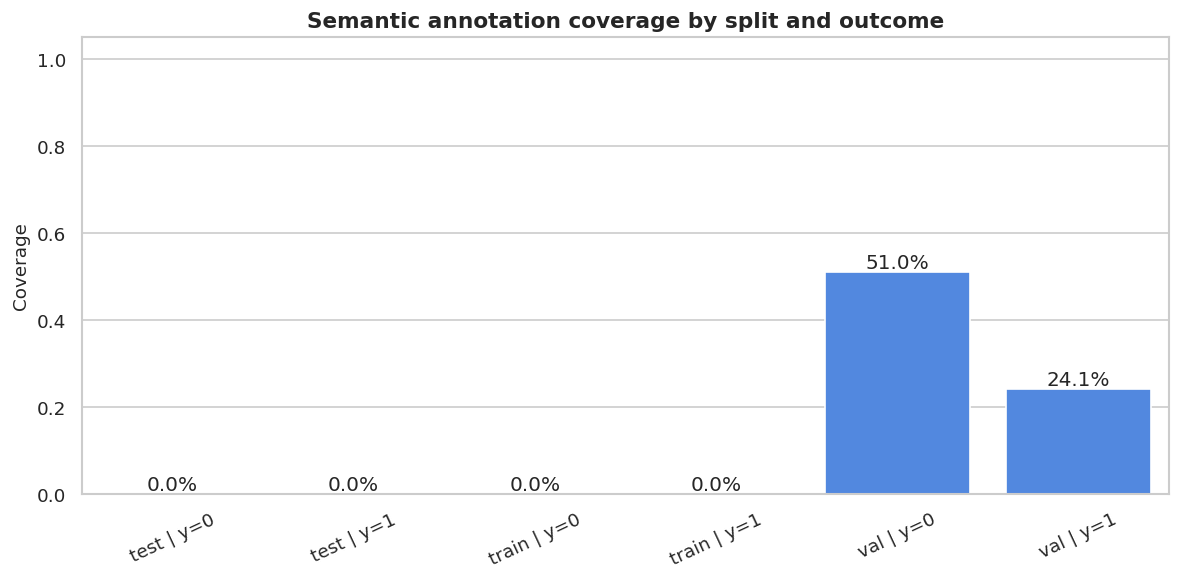

,field,missing_rate
0,primary_label,0.0
1,short_reason,0.0
2,input_tokens,0.0
3,output_tokens,0.0
4,latency_seconds,0.0
5,attempts,0.0
6,source_subreddit,0.0
7,target_subreddit,0.0
8,text_quality_flag,0.0
9,unk_ratio,0.0


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/03_field_missingness.csv


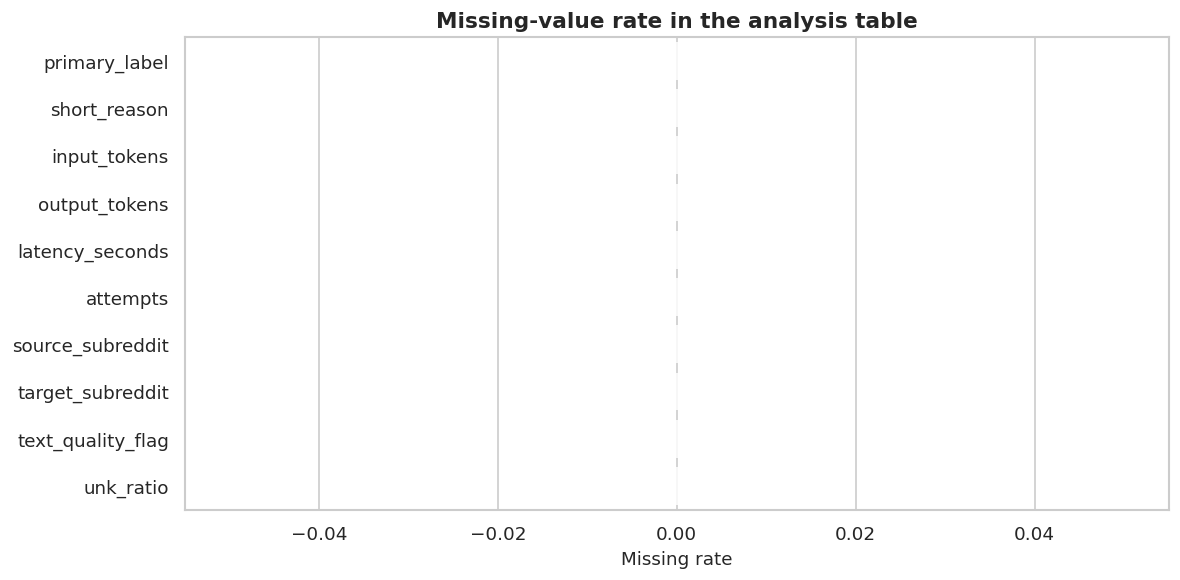

PosixPath('/content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/figures/02_field_missingness.png')

In [115]:
# Cell 13: Coverage, completeness, schema quality, and missingness
expected = (
    queue_df.groupby(["split", "y"], dropna=False)
    .size().rename("expected_rows").reset_index()
)
observed = (
    analysis_df.groupby(["split", "y"], dropna=False)
    .size().rename("annotated_rows").reset_index()
)
coverage_table = expected.merge(observed, on=["split", "y"], how="left")
coverage_table["annotated_rows"] = coverage_table["annotated_rows"].fillna(0).astype(int)
coverage_table["remaining_rows"] = (
    coverage_table["expected_rows"] - coverage_table["annotated_rows"]
)
coverage_table["coverage"] = (
    coverage_table["annotated_rows"] / coverage_table["expected_rows"]
)
save_table(coverage_table, "01_coverage_by_split_and_outcome")

quality_rows = [
    {"check": "queue_rows", "value": len(queue_df)},
    {"check": "annotated_unique_rows", "value": analysis_df["post_id"].nunique()},
    {"check": "remaining_rows", "value": len(queue_df) - analysis_df["post_id"].nunique()},
    {"check": "duplicate_post_ids", "value": analysis_df["post_id"].duplicated().sum()},
    {"check": "missing_primary_label", "value": analysis_df["primary_label"].isna().sum()},
    {"check": "invalid_primary_label", "value": (~analysis_df["primary_label"].isin(PRIMARY_LABELS)).sum()},
    {"check": "missing_short_reason", "value": analysis_df["short_reason"].fillna("").str.strip().eq("").sum()},
    {"check": "zero_boolean_labels", "value": analysis_df["boolean_count"].eq(0).sum()},
    {"check": "all_boolean_labels_true", "value": analysis_df["boolean_count"].eq(len(BOOLEAN_LABEL_COLUMNS)).sum()},
]
for col in BOOLEAN_LABEL_COLUMNS:
    quality_rows.append({"check": f"missing_{col}", "value": analysis_df[col].isna().sum()})
quality_table = pd.DataFrame(quality_rows)
save_table(quality_table, "02_schema_and_data_quality_checks")

plt.figure(figsize=(10, 5))
plot_df = coverage_table.copy()
plot_df["group"] = plot_df["split"].astype(str) + " | y=" + plot_df["y"].astype(str)
ax = sns.barplot(data=plot_df, x="group", y="coverage", color="#3B82F6")
ax.set_ylim(0, 1.05)
ax.set_title("Semantic annotation coverage by split and outcome")
ax.set_xlabel("")
ax.set_ylabel("Coverage")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", labels=[f"{v:.1%}" for v in plot_df["coverage"]])
save_figure("01_coverage_by_split_and_outcome")

missing_matrix = analysis_df[
    ["primary_label", "short_reason", "input_tokens", "output_tokens",
     "latency_seconds", "attempts", "source_subreddit", "target_subreddit",
     "text_quality_flag", "unk_ratio"]
].isna().mean().sort_values(ascending=False).rename("missing_rate").reset_index()
missing_matrix = missing_matrix.rename(columns={"index": "field"})
save_table(missing_matrix, "03_field_missingness")

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_matrix, x="missing_rate", y="field", color="#EF4444")
plt.title("Missing-value rate in the analysis table")
plt.xlabel("Missing rate")
plt.ylabel("")
save_figure("02_field_missingness")


,primary_label,rows,positives,outcome_rate,share,lift_vs_baseline,outcome_rate_ci_low,outcome_rate_ci_high
0,neutral_information_reference,2238,146,0.065237,0.425556,-0.017288,0.055733,0.076231
1,negative_grievance_reference,1093,89,0.081427,0.207834,-0.001098,0.066642,0.099145
2,audience_directed_engagement_reference,974,107,0.109856,0.185206,0.027331,0.091729,0.131049
3,norm_violation_reference,43,6,0.139535,0.008176,0.05701,0.065557,0.272636
4,cross_community_comparison_reference,321,33,0.102804,0.061038,0.020279,0.074142,0.140860
5,supportive_or_defensive_reference,38,5,0.131579,0.007226,0.049054,0.057539,0.273269
6,unclear_or_other,552,48,0.086957,0.104963,0.004431,0.066213,0.113409


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/04_primary_label_overall.csv


,split,primary_label,rows,outcome_rate,within_split_share
0,val,audience_directed_engagement_reference,974,0.109856,0.185206
1,val,cross_community_comparison_reference,321,0.102804,0.061038
2,val,negative_grievance_reference,1093,0.081427,0.207834
3,val,neutral_information_reference,2238,0.065237,0.425556
4,val,norm_violation_reference,43,0.139535,0.008176
5,val,supportive_or_defensive_reference,38,0.131579,0.007226
6,val,unclear_or_other,552,0.086957,0.104963


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/05_primary_label_by_split.csv


y,primary_label,0,1
0,neutral_information_reference,0.433575,0.336406
1,negative_grievance_reference,0.208083,0.205069
2,audience_directed_engagement_reference,0.179689,0.246544
3,norm_violation_reference,0.007668,0.013825
4,cross_community_comparison_reference,0.059689,0.076037
5,supportive_or_defensive_reference,0.006839,0.011521
6,unclear_or_other,0.104456,0.110599


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/06_primary_label_share_within_outcome.csv


,test,chi_square,degrees_of_freedom,p_value,cramers_v,n,minimum_expected_count
0,primary_label_vs_outcome_chi_square,23.401347,6,0.000673,0.066707,5259,3.135957


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/07_primary_label_chi_square_test.csv


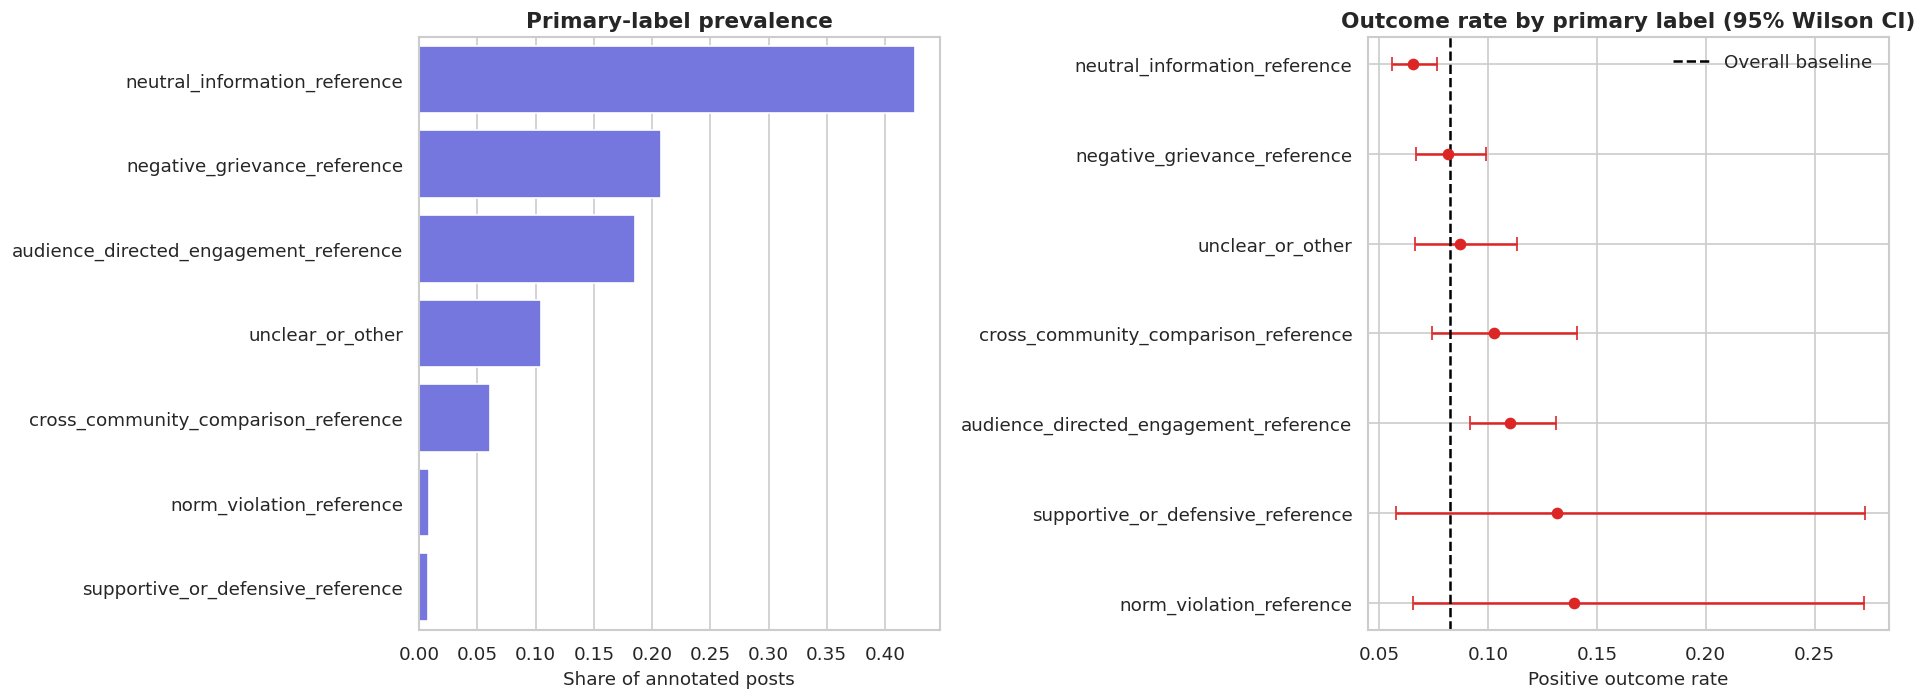

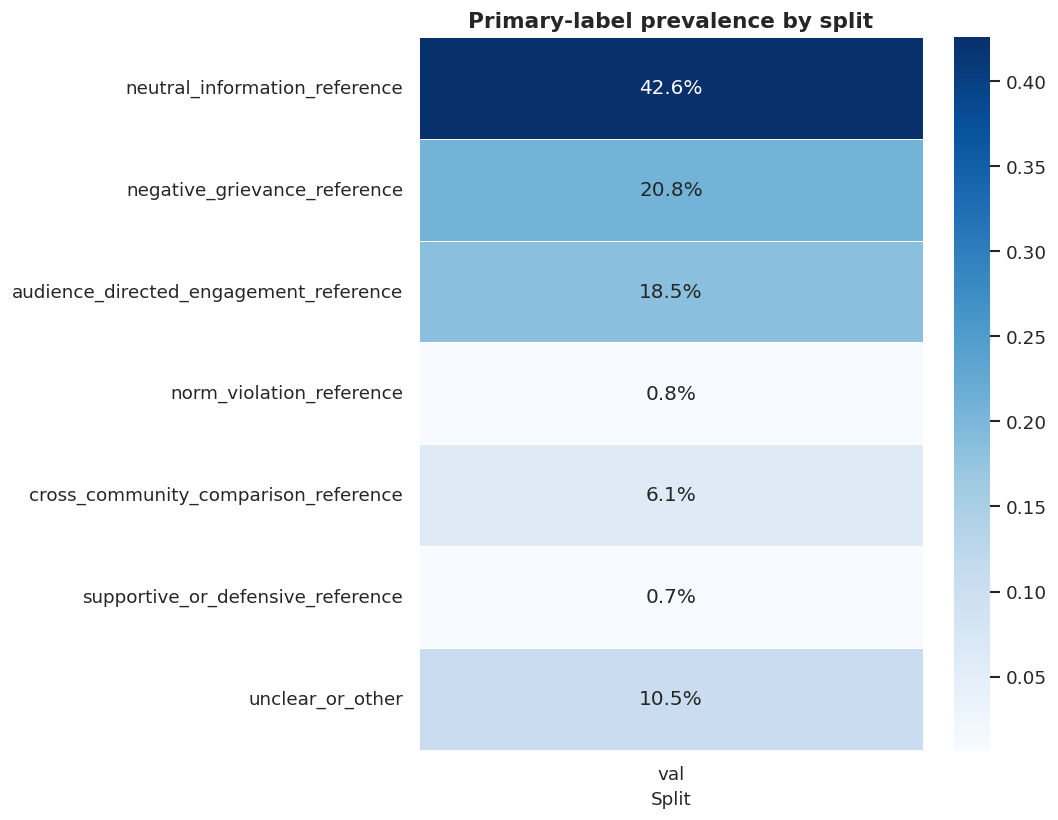

PosixPath('/content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/figures/04_primary_label_prevalence_by_split_heatmap.png')

In [116]:
# Cell 14: Primary-label distributions and outcome associations
primary_counts = (
    analysis_df.groupby("primary_label", observed=False)
    .agg(
        rows=("post_id", "size"),
        positives=("y", "sum"),
        outcome_rate=("y", "mean"),
    )
    .reindex(PRIMARY_LABELS)
    .reset_index()
)
primary_counts[["rows", "positives"]] = primary_counts[
    ["rows", "positives"]
].fillna(0)
primary_counts["share"] = primary_counts["rows"] / len(analysis_df)
primary_counts["lift_vs_baseline"] = primary_counts["outcome_rate"] - baseline_rate
ci = [wilson_interval(int(p), int(n)) for p, n in zip(primary_counts["positives"], primary_counts["rows"])]
primary_counts["outcome_rate_ci_low"] = [x[0] for x in ci]
primary_counts["outcome_rate_ci_high"] = [x[1] for x in ci]
save_table(primary_counts, "04_primary_label_overall")

primary_by_split = (
    analysis_df.groupby(["split", "primary_label"], observed=False)
    .agg(rows=("post_id", "size"), outcome_rate=("y", "mean"))
    .reset_index()
)
primary_by_split["within_split_share"] = (
    primary_by_split["rows"] / primary_by_split.groupby("split")["rows"].transform("sum")
)
save_table(primary_by_split, "05_primary_label_by_split")

primary_by_outcome = pd.crosstab(
    analysis_df["primary_label"], analysis_df["y"], normalize="columns"
).reindex(PRIMARY_LABELS).fillna(0).reset_index()
save_table(primary_by_outcome, "06_primary_label_share_within_outcome")

contingency = pd.crosstab(analysis_df["primary_label"], analysis_df["y"]).reindex(PRIMARY_LABELS).fillna(0)
chi2, p_value, dof, expected_counts = chi2_contingency(contingency)
primary_test = pd.DataFrame([{
    "test": "primary_label_vs_outcome_chi_square",
    "chi_square": chi2,
    "degrees_of_freedom": dof,
    "p_value": p_value,
    "cramers_v": cramers_v(contingency.values),
    "n": int(contingency.values.sum()),
    "minimum_expected_count": float(np.min(expected_counts)),
}])
save_table(primary_test, "07_primary_label_chi_square_test")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=primary_counts.sort_values("share", ascending=False),
    x="share", y="primary_label", color="#6366F1", ax=axes[0],
)
axes[0].set_title("Primary-label prevalence")
axes[0].set_xlabel("Share of annotated posts")
axes[0].set_ylabel("")
ordered = primary_counts.sort_values("outcome_rate", ascending=False)
axes[1].errorbar(
    ordered["outcome_rate"],
    ordered["primary_label"],
    xerr=[
        ordered["outcome_rate"] - ordered["outcome_rate_ci_low"],
        ordered["outcome_rate_ci_high"] - ordered["outcome_rate"],
    ],
    fmt="o", color="#DC2626", capsize=4,
)
axes[1].axvline(baseline_rate, color="black", linestyle="--", label="Overall baseline")
axes[1].set_title("Outcome rate by primary label (95% Wilson CI)")
axes[1].set_xlabel("Positive outcome rate")
axes[1].set_ylabel("")
axes[1].legend()
save_figure("03_primary_label_prevalence_and_outcome_rate")

heat = primary_by_split.pivot(index="primary_label", columns="split", values="within_split_share").reindex(PRIMARY_LABELS)
plt.figure(figsize=(9, 7))
sns.heatmap(heat, annot=True, fmt=".1%", cmap="Blues", linewidths=.5)
plt.title("Primary-label prevalence by split")
plt.xlabel("Split")
plt.ylabel("")
save_figure("04_primary_label_prevalence_by_split_heatmap")


,label,true_rows,false_rows,prevalence,positive_rows_when_true,outcome_rate_when_true,outcome_rate_true_ci_low,outcome_rate_true_ci_high
6,neutral_information_reference,2238,3021,0.425556,146,0.065237,0.055733,0.076231
1,audience_directed_engagement,1201,4058,0.228370,125,0.104080,0.088054,0.122631
0,negative_grievance,1117,4142,0.212398,90,0.080573,0.066012,0.098009
3,cross_community_comparison,613,4646,0.116562,63,0.102773,0.081156,0.129338
4,intergroup_boundary_framing,215,5044,0.040882,18,0.083721,0.053612,0.128444
2,norm_violation_framing,154,5105,0.029283,10,0.064935,0.035651,0.115396
5,supportive_or_defensive_framing,124,5135,0.023579,18,0.145161,0.093837,0.217811


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/08_boolean_label_prevalence.csv


,label,n_true,n_false,outcome_rate_true,outcome_rate_false,risk_difference,risk_difference_ci_low,risk_difference_ci_high,relative_risk,odds_ratio_corrected,odds_ratio_ci_low,odds_ratio_ci_high,fisher_exact_odds_ratio,fisher_exact_p_value,mutual_information_nats,fdr_bh_p_value,significant_fdr_0_05
5,supportive_or_defensive_framing,124,5135,0.145161,0.081013,0.064149,0.003800,0.128081,1.791835,1.968354,1.189399,3.257455,1.926297,0.018884,5.225065e-04,0.044063,True
1,audience_directed_engagement,1201,4058,0.104080,0.076146,0.027934,0.009276,0.047238,1.366849,1.412350,1.135468,1.756750,1.409466,0.002783,8.639250e-04,0.009740,True
3,cross_community_comparison,613,4646,0.102773,0.079854,0.022920,-0.002321,0.049111,1.287020,1.327530,1.002762,1.757483,1.319897,0.060485,3.366874e-04,0.105848,False
4,intergroup_boundary_framing,215,5044,0.083721,0.082474,0.001247,-0.034773,0.041125,1.015116,1.040950,0.639636,1.694052,1.016497,0.899454,4.007788e-07,0.899454,False
0,negative_grievance,1117,4142,0.080573,0.083052,-0.002479,-0.020012,0.015638,0.970155,0.971157,0.762751,1.236507,0.967539,0.854167,6.823314e-06,0.899454,False
2,norm_violation_framing,154,5105,0.064935,0.083056,-0.018121,-0.055515,0.024366,0.781824,0.801362,0.424972,1.511113,0.766673,0.550809,6.598186e-05,0.771133,False
6,neutral_information_reference,2238,3021,0.065237,0.095333,-0.030096,-0.044860,-0.015515,0.684307,0.663354,0.539410,0.815777,0.662275,0.000092,1.494851e-03,0.000642,True


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/09_boolean_outcome_associations.csv


split,label,val
0,negative_grievance,0.212398
1,audience_directed_engagement,0.228370
2,norm_violation_framing,0.029283
3,cross_community_comparison,0.116562
4,intergroup_boundary_framing,0.040882
5,supportive_or_defensive_framing,0.023579
6,neutral_information_reference,0.425556


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/10_boolean_prevalence_by_split.csv


y,label,0,1
0,negative_grievance,0.212850,0.207373
1,audience_directed_engagement,0.223005,0.288018
2,norm_violation_framing,0.029845,0.023041
3,cross_community_comparison,0.113990,0.145161
4,intergroup_boundary_framing,0.040829,0.041475
5,supportive_or_defensive_framing,0.021969,0.041475
6,neutral_information_reference,0.433575,0.336406


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/11_boolean_prevalence_by_outcome.csv


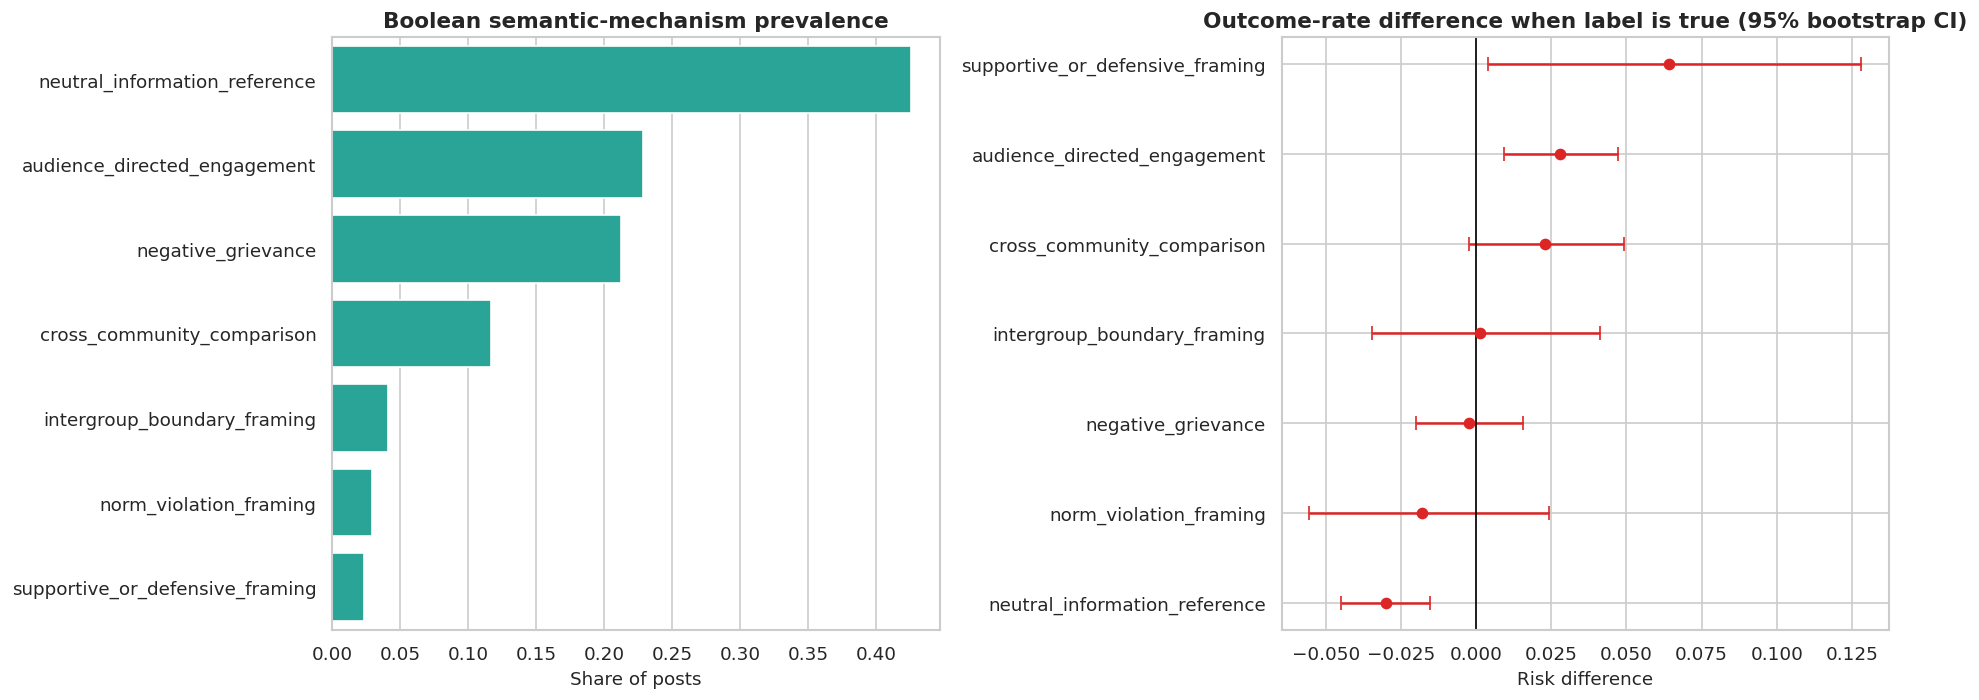

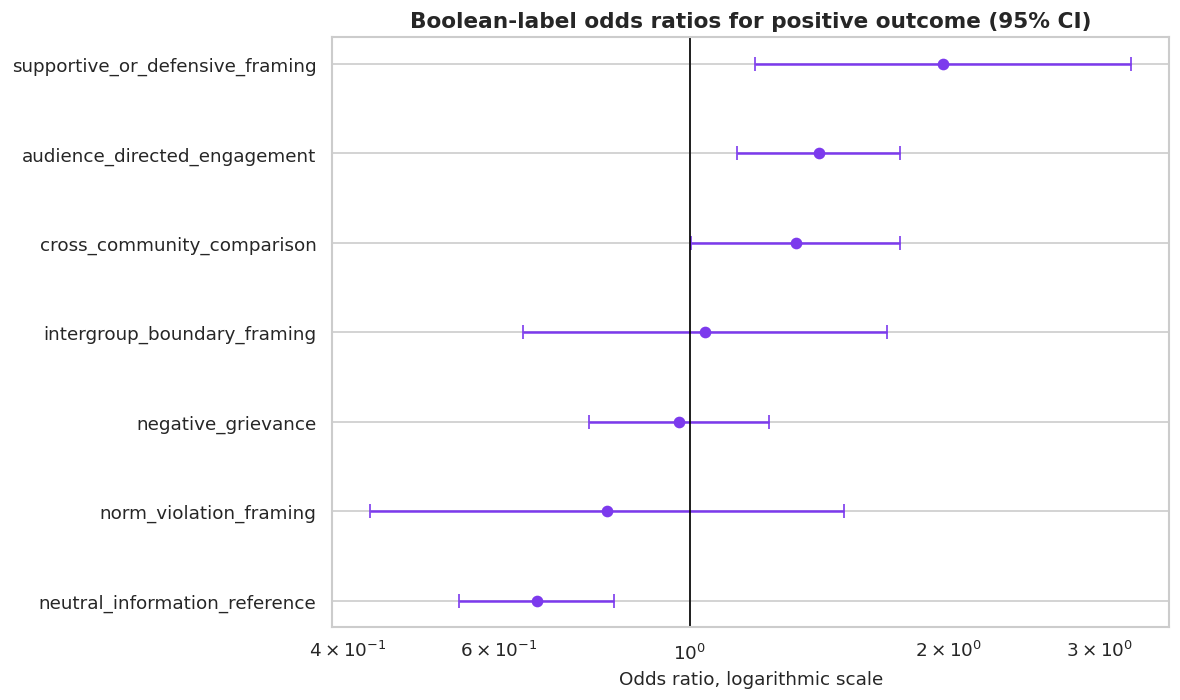

PosixPath('/content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/figures/06_boolean_outcome_odds_ratio_forest.png')

In [117]:
# Cell 15: Boolean-label prevalence, effect sizes, tests, and confidence intervals
prevalence_rows = []
association_rows = []
mi_values = mutual_info_classif(
    analysis_df[BOOLEAN_LABEL_COLUMNS].astype(int),
    analysis_df["y"].astype(int),
    discrete_features=True,
    random_state=ANALYSIS_RANDOM_SEED,
)

for idx, label in enumerate(BOOLEAN_LABEL_COLUMNS):
    mask = analysis_df[label].astype(bool)
    n_true = int(mask.sum())
    n_false = int((~mask).sum())
    pos_true = int(analysis_df.loc[mask, "y"].sum())
    pos_false = int(analysis_df.loc[~mask, "y"].sum())
    rate_true = pos_true / n_true if n_true else np.nan
    rate_false = pos_false / n_false if n_false else np.nan
    diff = rate_true - rate_false
    risk_ratio = rate_true / rate_false if rate_false > 0 else np.inf

    # Haldane-Anscombe correction stabilizes the odds ratio and CI for zero cells.
    a, b, c, d = pos_true + .5, n_true - pos_true + .5, pos_false + .5, n_false - pos_false + .5
    odds_ratio = (a * d) / (b * c)
    log_or_se = math.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
    or_ci_low = math.exp(math.log(odds_ratio) - 1.96 * log_or_se)
    or_ci_high = math.exp(math.log(odds_ratio) + 1.96 * log_or_se)
    fisher_or, fisher_p = fisher_exact([[pos_true, n_true - pos_true], [pos_false, n_false - pos_false]])
    diff_ci_low, diff_ci_high = binary_rate_bootstrap(
        pos_true, n_true, pos_false, n_false, seed=ANALYSIS_RANDOM_SEED + idx
    )
    true_ci_low, true_ci_high = wilson_interval(pos_true, n_true)

    prevalence_rows.append({
        "label": label,
        "true_rows": n_true,
        "false_rows": n_false,
        "prevalence": n_true / len(analysis_df),
        "positive_rows_when_true": pos_true,
        "outcome_rate_when_true": rate_true,
        "outcome_rate_true_ci_low": true_ci_low,
        "outcome_rate_true_ci_high": true_ci_high,
    })
    association_rows.append({
        "label": label,
        "n_true": n_true,
        "n_false": n_false,
        "outcome_rate_true": rate_true,
        "outcome_rate_false": rate_false,
        "risk_difference": diff,
        "risk_difference_ci_low": diff_ci_low,
        "risk_difference_ci_high": diff_ci_high,
        "relative_risk": risk_ratio,
        "odds_ratio_corrected": odds_ratio,
        "odds_ratio_ci_low": or_ci_low,
        "odds_ratio_ci_high": or_ci_high,
        "fisher_exact_odds_ratio": fisher_or,
        "fisher_exact_p_value": fisher_p,
        "mutual_information_nats": mi_values[idx],
    })

boolean_prevalence = pd.DataFrame(prevalence_rows).sort_values("prevalence", ascending=False)
boolean_associations = pd.DataFrame(association_rows)
boolean_associations["fdr_bh_p_value"] = multipletests(
    boolean_associations["fisher_exact_p_value"], method="fdr_bh"
)[1]
boolean_associations["significant_fdr_0_05"] = boolean_associations["fdr_bh_p_value"] < 0.05
boolean_associations = boolean_associations.sort_values("risk_difference", ascending=False)
save_table(boolean_prevalence, "08_boolean_label_prevalence")
save_table(boolean_associations, "09_boolean_outcome_associations")

prevalence_by_split = (
    analysis_df.groupby("split")[BOOLEAN_LABEL_COLUMNS].mean().T
    .rename_axis("label").reset_index()
)
save_table(prevalence_by_split, "10_boolean_prevalence_by_split")

prevalence_by_outcome = (
    analysis_df.groupby("y")[BOOLEAN_LABEL_COLUMNS].mean().T
    .rename_axis("label").reset_index()
)
save_table(prevalence_by_outcome, "11_boolean_prevalence_by_outcome")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=boolean_prevalence, x="prevalence", y="label", color="#14B8A6", ax=axes[0])
axes[0].set_title("Boolean semantic-mechanism prevalence")
axes[0].set_xlabel("Share of posts")
axes[0].set_ylabel("")

ordered = boolean_associations.sort_values("risk_difference")
axes[1].errorbar(
    ordered["risk_difference"], ordered["label"],
    xerr=[
        ordered["risk_difference"] - ordered["risk_difference_ci_low"],
        ordered["risk_difference_ci_high"] - ordered["risk_difference"],
    ],
    fmt="o", color="#DC2626", capsize=4,
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Outcome-rate difference when label is true (95% bootstrap CI)")
axes[1].set_xlabel("Risk difference")
axes[1].set_ylabel("")
save_figure("05_boolean_prevalence_and_risk_difference")

plt.figure(figsize=(10, 6))
ordered = boolean_associations.sort_values("odds_ratio_corrected")
plt.errorbar(
    ordered["odds_ratio_corrected"], ordered["label"],
    xerr=[
        ordered["odds_ratio_corrected"] - ordered["odds_ratio_ci_low"],
        ordered["odds_ratio_ci_high"] - ordered["odds_ratio_corrected"],
    ],
    fmt="o", color="#7C3AED", capsize=4,
)
plt.axvline(1, color="black", linewidth=1)
plt.xscale("log")
plt.title("Boolean-label odds ratios for positive outcome (95% CI)")
plt.xlabel("Odds ratio, logarithmic scale")
plt.ylabel("")
save_figure("06_boolean_outcome_odds_ratio_forest")


,label,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference
0,negative_grievance,1117,156,115,201,181,13,0
1,audience_directed_engagement,156,1201,38,98,50,58,61
2,norm_violation_framing,115,38,154,13,9,1,0
3,cross_community_comparison,201,98,13,613,139,16,56
4,intergroup_boundary_framing,181,50,9,139,215,10,0
5,supportive_or_defensive_framing,13,58,1,16,10,124,14
6,neutral_information_reference,0,61,0,56,0,14,2238


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/12_boolean_cooccurrence_counts.csv


,label,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference
0,negative_grievance,1.000000,-0.109742,0.226916,0.102574,0.317741,-0.040866,-0.446968
1,audience_directed_engagement,-0.109742,1.000000,0.007606,-0.059274,0.002060,0.088611,-0.412356
2,norm_violation_framing,0.226916,0.007606,1.000000,-0.017399,0.015402,-0.019557,-0.149492
3,cross_community_comparison,0.102574,-0.059274,-0.017399,1.000000,0.340957,0.006039,-0.245526
4,intergroup_boundary_framing,0.317741,0.002060,0.015402,0.340957,1.000000,0.031204,-0.177700
5,supportive_or_defensive_framing,-0.040866,0.088611,-0.019557,0.006039,0.031204,1.000000,-0.098265
6,neutral_information_reference,-0.446968,-0.412356,-0.149492,-0.245526,-0.177700,-0.098265,1.000000


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/13_boolean_phi_correlations.csv


,label,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference
0,negative_grievance,1.000000,0.072155,0.099481,0.131458,0.157255,0.010586,0.000000
1,audience_directed_engagement,0.072155,1.000000,0.028853,0.057110,0.036603,0.045777,0.018058
2,norm_violation_framing,0.099481,0.028853,1.000000,0.017241,0.025000,0.003610,0.000000
3,cross_community_comparison,0.131458,0.057110,0.017241,1.000000,0.201742,0.022191,0.020036
4,intergroup_boundary_framing,0.157255,0.036603,0.025000,0.201742,1.000000,0.030395,0.000000
5,supportive_or_defensive_framing,0.010586,0.045777,0.003610,0.022191,0.030395,1.000000,0.005963
6,neutral_information_reference,0.000000,0.018058,0.000000,0.020036,0.000000,0.005963,1.000000


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/14_boolean_jaccard_similarity.csv


,label,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference
0,negative_grievance,4.708147,0.611549,3.515824,1.543781,3.963603,0.493596,0.000000
1,audience_directed_engagement,0.611549,4.378851,1.080496,0.700045,1.018337,2.048172,0.119352
2,norm_violation_framing,3.515824,1.080496,34.149351,0.724211,1.429508,0.275398,0.000000
3,cross_community_comparison,1.543781,0.700045,0.724211,8.579119,5.546500,1.106983,0.214670
4,intergroup_boundary_framing,3.963603,1.018337,1.429508,5.546500,24.460465,1.972618,0.000000
5,supportive_or_defensive_framing,0.493596,2.048172,0.275398,1.106983,1.972618,42.411290,0.265307
6,neutral_information_reference,0.000000,0.119352,0.000000,0.214670,0.000000,0.265307,2.349866


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/15_boolean_cooccurrence_lift.csv


,label_a,label_b,rows_both_true,support,positive_rows,outcome_rate,lift_vs_baseline,relative_to_baseline,jaccard,phi_correlation,cooccurrence_lift
2,negative_grievance,cross_community_comparison,201,0.038220,18,0.089552,0.007027,1.085150,0.131458,0.102574,1.543781
3,negative_grievance,intergroup_boundary_framing,181,0.034417,14,0.077348,-0.005177,0.937266,0.157255,0.317741,3.963603
0,negative_grievance,audience_directed_engagement,156,0.029663,12,0.076923,-0.005602,0.932116,0.072155,-0.109742,0.611549
15,cross_community_comparison,intergroup_boundary_framing,139,0.026431,13,0.093525,0.011000,1.133292,0.201742,0.340957,5.546500
1,negative_grievance,norm_violation_framing,115,0.021867,5,0.043478,-0.039047,0.526848,0.099481,0.226916,3.515824
7,audience_directed_engagement,cross_community_comparison,98,0.018635,14,0.142857,0.060332,1.731073,0.057110,-0.059274,0.700045
10,audience_directed_engagement,neutral_information_reference,61,0.011599,4,0.065574,-0.016951,0.794591,0.018058,-0.412356,0.119352
9,audience_directed_engagement,supportive_or_defensive_framing,58,0.011029,9,0.155172,0.072647,1.880304,0.045777,0.088611,2.048172
17,cross_community_comparison,neutral_information_reference,56,0.010648,5,0.089286,0.006761,1.081921,0.020036,-0.245526,0.214670
8,audience_directed_engagement,intergroup_boundary_framing,50,0.009508,6,0.120000,0.037475,1.454101,0.036603,0.002060,1.018337


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/16_boolean_pair_outcome_rates.csv


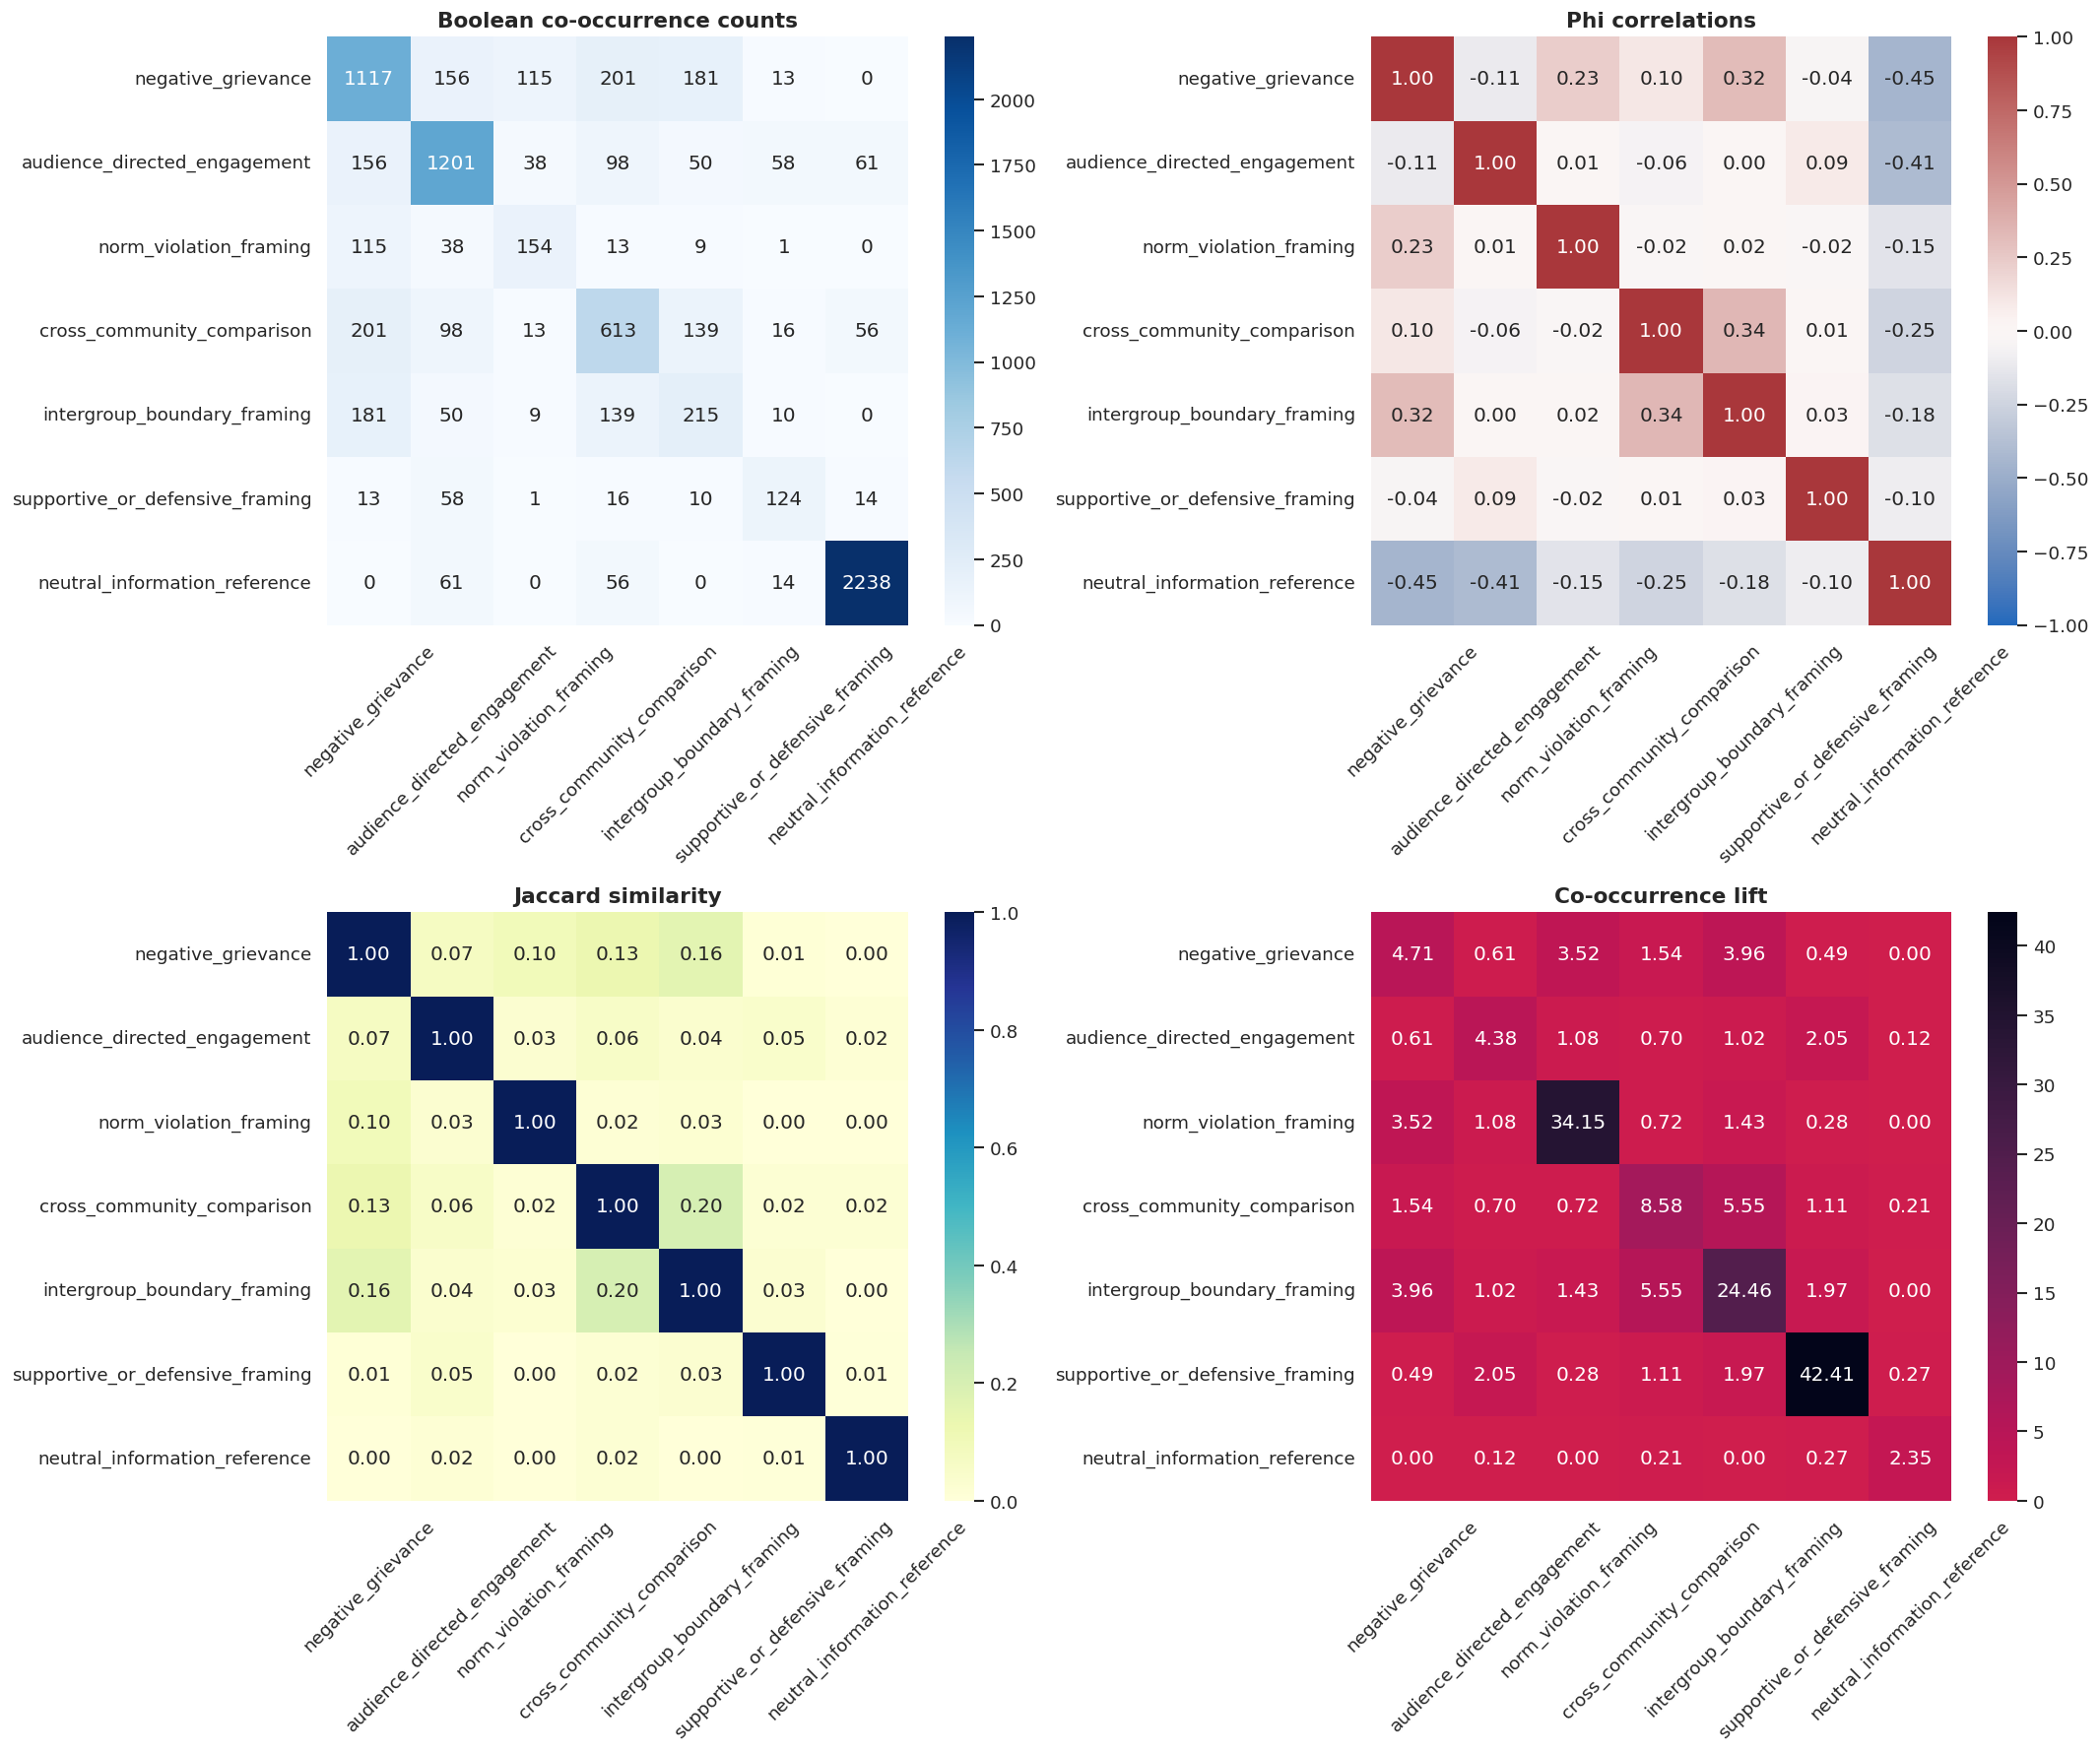

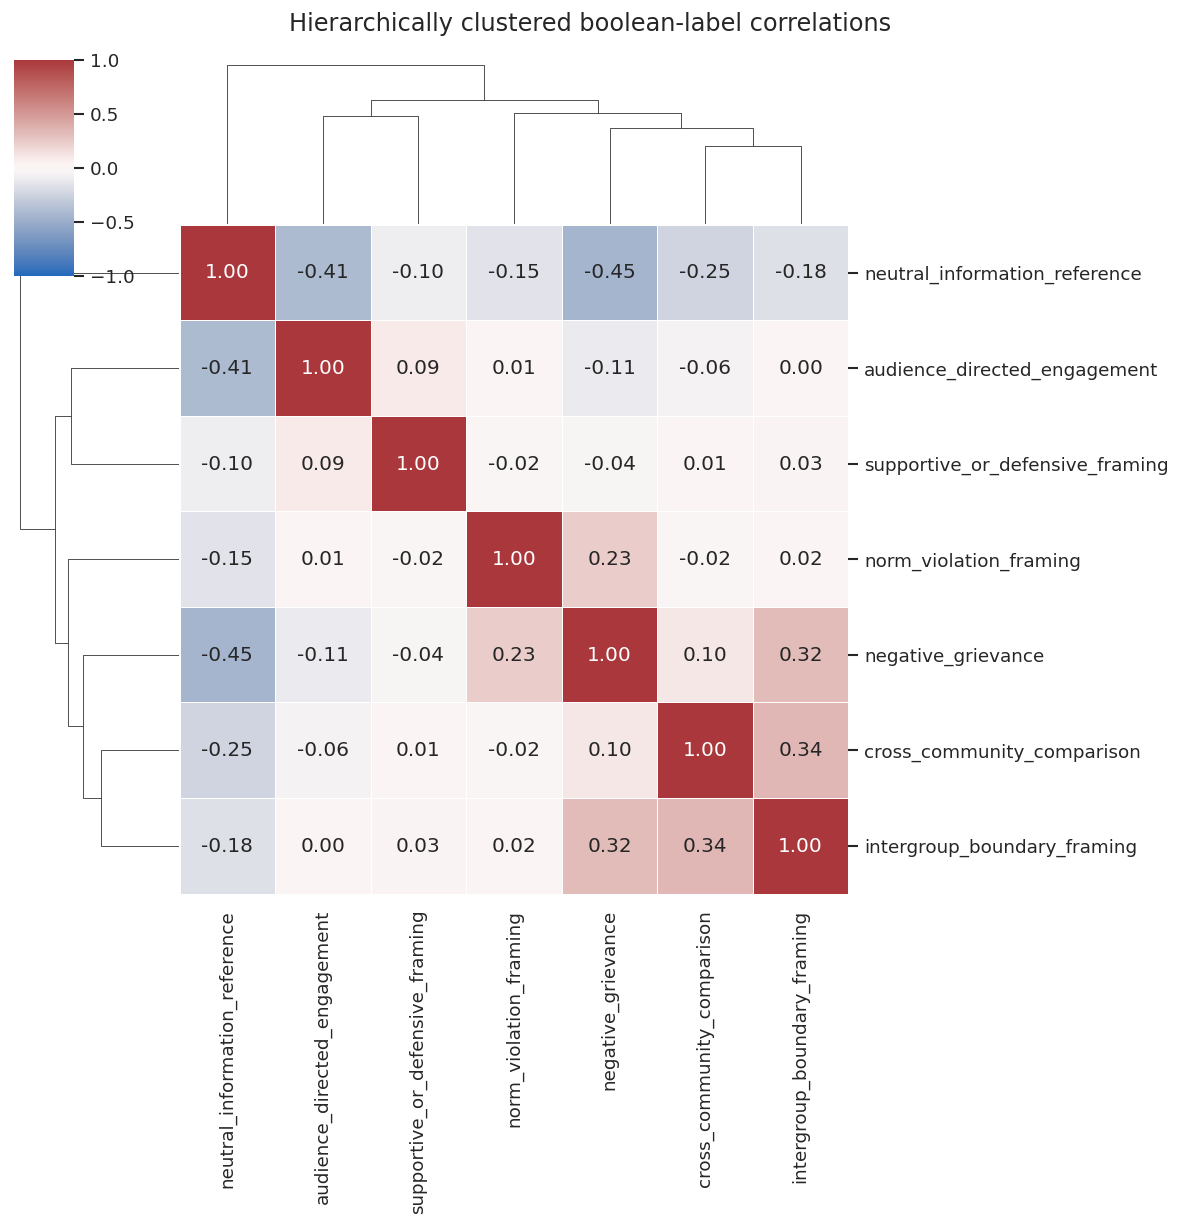

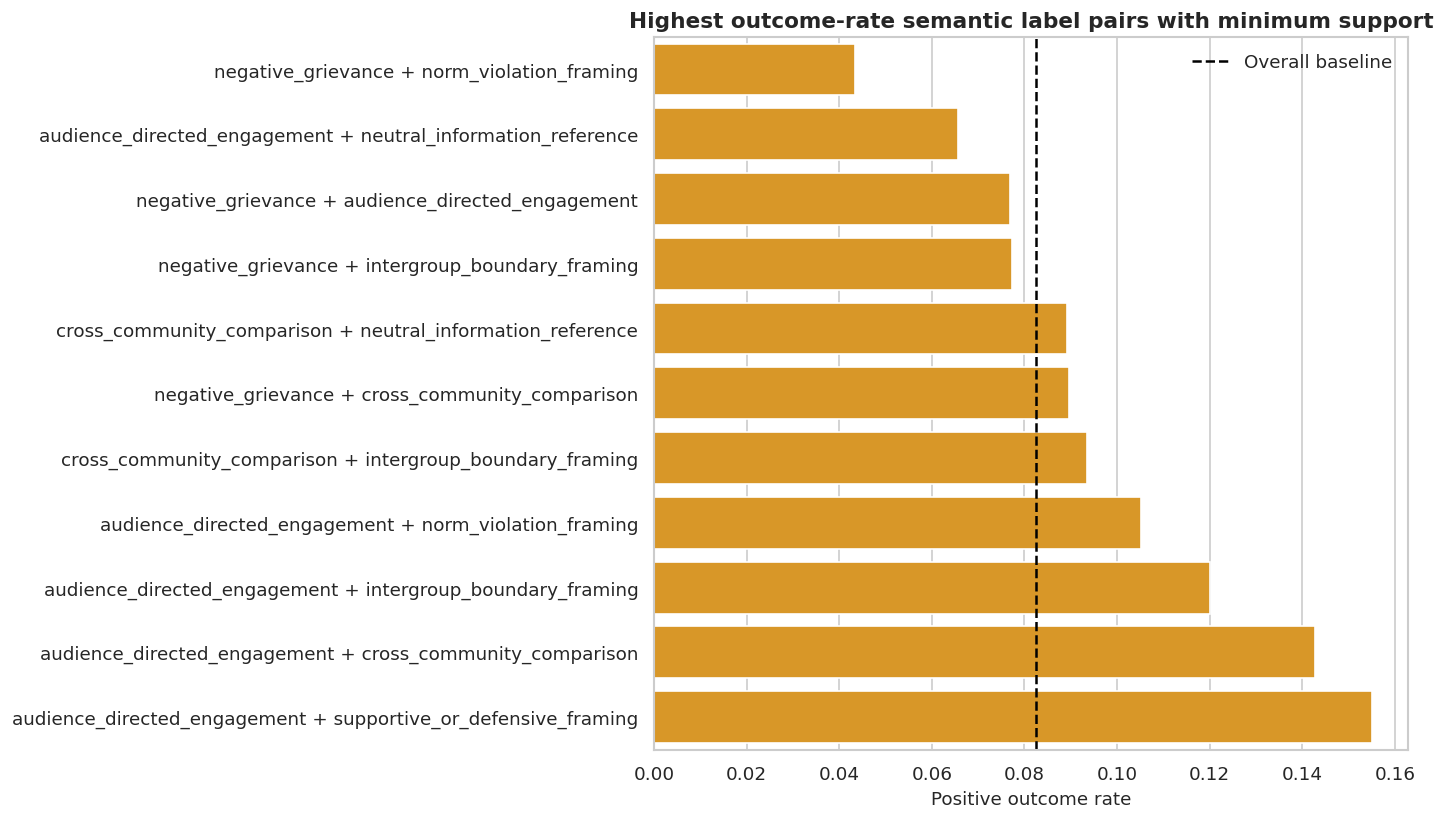

In [118]:
# Cell 16: Co-occurrence, correlations, Jaccard similarity, lift, and label pairs
bool_frame = analysis_df[BOOLEAN_LABEL_COLUMNS].astype(int)
cooccurrence = bool_frame.T.dot(bool_frame)
prevalence = bool_frame.mean()
phi = bool_frame.corr()
jaccard = pd.DataFrame(index=BOOLEAN_LABEL_COLUMNS, columns=BOOLEAN_LABEL_COLUMNS, dtype=float)
lift = pd.DataFrame(index=BOOLEAN_LABEL_COLUMNS, columns=BOOLEAN_LABEL_COLUMNS, dtype=float)
pair_rows = []

for left in BOOLEAN_LABEL_COLUMNS:
    for right in BOOLEAN_LABEL_COLUMNS:
        intersection = int((bool_frame[left] & bool_frame[right]).sum())
        union = int((bool_frame[left] | bool_frame[right]).sum())
        jaccard.loc[left, right] = intersection / union if union else np.nan
        joint = intersection / len(bool_frame)
        lift.loc[left, right] = joint / (prevalence[left] * prevalence[right]) if prevalence[left] * prevalence[right] else np.nan

for i, left in enumerate(BOOLEAN_LABEL_COLUMNS):
    for right in BOOLEAN_LABEL_COLUMNS[i + 1:]:
        both = analysis_df[left] & analysis_df[right]
        rows = int(both.sum())
        positives = int(analysis_df.loc[both, "y"].sum())
        rate = positives / rows if rows else np.nan
        pair_rows.append({
            "label_a": left,
            "label_b": right,
            "rows_both_true": rows,
            "support": rows / len(analysis_df),
            "positive_rows": positives,
            "outcome_rate": rate,
            "lift_vs_baseline": rate - baseline_rate if rows else np.nan,
            "relative_to_baseline": rate / baseline_rate if rows and baseline_rate else np.nan,
            "jaccard": jaccard.loc[left, right],
            "phi_correlation": phi.loc[left, right],
            "cooccurrence_lift": lift.loc[left, right],
        })

pair_table = pd.DataFrame(pair_rows).sort_values(["rows_both_true", "outcome_rate"], ascending=False)
save_table(cooccurrence.rename_axis("label").reset_index(), "12_boolean_cooccurrence_counts")
save_table(phi.rename_axis("label").reset_index(), "13_boolean_phi_correlations")
save_table(jaccard.rename_axis("label").reset_index(), "14_boolean_jaccard_similarity")
save_table(lift.rename_axis("label").reset_index(), "15_boolean_cooccurrence_lift")
save_table(pair_table, "16_boolean_pair_outcome_rates")

fig, axes = plt.subplots(2, 2, figsize=(18, 15))
sns.heatmap(cooccurrence, annot=True, fmt="g", cmap="Blues", ax=axes[0, 0])
axes[0, 0].set_title("Boolean co-occurrence counts")
sns.heatmap(phi, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=axes[0, 1])
axes[0, 1].set_title("Phi correlations")
sns.heatmap(jaccard, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=axes[1, 0])
axes[1, 0].set_title("Jaccard similarity")
sns.heatmap(lift, annot=True, fmt=".2f", cmap="rocket_r", center=1, ax=axes[1, 1])
axes[1, 1].set_title("Co-occurrence lift")
for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
save_figure("07_boolean_cooccurrence_matrix_suite")

cluster = sns.clustermap(
    phi.fillna(0), cmap="vlag", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", linewidths=.5, figsize=(10, 10),
)
cluster.fig.suptitle("Hierarchically clustered boolean-label correlations", y=1.02)
cluster_png = FIGURE_DIR / "07b_boolean_correlation_clustermap.png"
cluster_pdf = FIGURE_DIR / "07b_boolean_correlation_clustermap.pdf"
cluster.savefig(cluster_png, bbox_inches="tight")
cluster.savefig(cluster_pdf, bbox_inches="tight")
figure_registry.append({
    "name": "07b_boolean_correlation_clustermap",
    "png": str(cluster_png),
    "pdf": str(cluster_pdf),
})
plt.show()
plt.close(cluster.fig)

eligible_pairs = pair_table.loc[pair_table["rows_both_true"] >= max(20, int(len(analysis_df) * .001))].copy()
if not eligible_pairs.empty:
    eligible_pairs["pair"] = eligible_pairs["label_a"] + " + " + eligible_pairs["label_b"]
    top_pairs = eligible_pairs.nlargest(15, "outcome_rate").sort_values("outcome_rate")
    plt.figure(figsize=(12, 7))
    sns.barplot(data=top_pairs, x="outcome_rate", y="pair", color="#F59E0B")
    plt.axvline(baseline_rate, color="black", linestyle="--", label="Overall baseline")
    plt.title("Highest outcome-rate semantic label pairs with minimum support")
    plt.xlabel("Positive outcome rate")
    plt.ylabel("")
    plt.legend()
    save_figure("08_top_boolean_pairs_by_outcome_rate")


,boolean_count,rows,positives,outcome_rate,share,outcome_rate_ci_low,outcome_rate_ci_high
0,0,552,48,0.086957,0.104963,0.066213,0.113409
1,1,3982,328,0.082371,0.757178,0.074229,0.091318
2,2,536,36,0.067164,0.101921,0.048906,0.091582
3,3,151,19,0.125828,0.028713,0.082054,0.188168
4,4,35,2,0.057143,0.006655,0.015813,0.186071
5,5,3,1,0.333333,0.000570,0.061492,0.792340


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/17_boolean_cardinality.csv


,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference,rows,positives,outcome_rate,share,active_labels
1,False,False,False,False,False,False,True,2109,136,0.064486,0.401027,neutral_information_reference
11,False,True,False,False,False,False,False,869,94,0.10817,0.165241,audience_directed_engagement
23,True,False,False,False,False,False,False,666,59,0.088589,0.126640,negative_grievance
0,False,False,False,False,False,False,False,552,48,0.086957,0.104963,none
4,False,False,False,True,False,False,False,268,29,0.108209,0.050960,cross_community_comparison
28,True,False,False,True,True,False,False,79,7,0.088608,0.015022,negative_grievance + cross_community_compariso...
34,True,True,False,False,False,False,False,75,4,0.053333,0.014261,negative_grievance + audience_directed_engagement
26,True,False,False,True,False,False,False,71,6,0.084507,0.013501,negative_grievance + cross_community_comparison
30,True,False,True,False,False,False,False,70,1,0.014286,0.013311,negative_grievance + norm_violation_framing
12,False,True,False,False,False,False,True,59,3,0.050847,0.011219,audience_directed_engagement + neutral_informa...


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/18_all_observed_boolean_combinations.csv


,rule,primary_rows,inconsistent_rows,inconsistent_rate_within_primary
6,neutral primary with at least one conflict-ori...,2238,115,0.021867
0,neutral_information_reference implies neutral_...,2238,1,0.000447
1,negative_grievance_reference implies negative_...,1093,0,0.000000
2,audience_directed_engagement_reference implies...,974,0,0.000000
3,norm_violation_reference implies norm_violatio...,43,0,0.000000
4,cross_community_comparison_reference implies c...,321,0,0.000000
5,supportive_or_defensive_reference implies supp...,38,0,0.000000


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/19_primary_boolean_consistency.csv


,audit_group,post_id,split,y,source_subreddit,target_subreddit,primary_label,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference,short_reason,title_for_llm,body_for_llm,text_quality_flag,unk_ratio
0,neutral_information_reference_without_neutral_...,3x7tu2,val,0,redditdads,starcitizen,neutral_information_reference,False,False,False,False,False,True,False,The post is a personal anecdote about Star Cit...,reason to buy a pledge if you havent before is...,<UNK> <UNK> x tu papa grumps https,usable_low_unknown,0.060606
1,neutral_primary_with_conflict_boolean,5ub3oa,val,0,explainlikeimfive,news,neutral_information_reference,False,True,False,False,False,False,True,The user is asking for an explanation and reso...,eli,<UNK> explainlikeimfive ub oa <UNK> um this is...,usable_low_unknown,0.010363
2,neutral_primary_with_conflict_boolean,40u2y9,val,0,bugs,bitcoin,neutral_information_reference,False,False,False,True,False,False,True,The user is reporting a technical issue with c...,unable to collapse certain comments,<UNK> bugs u y carsten ger dear all i noticed ...,usable_low_unknown,0.032787
3,neutral_primary_with_conflict_boolean,5cl1bk,val,0,flyers,wildhockey,neutral_information_reference,False,False,False,True,False,False,True,The post provides information about an upcomin...,from the wild perspective tonight s game,<UNK> flyers cl bk <UNK> hi everyone i m u <UN...,usable_low_unknown,0.008427
4,neutral_primary_with_conflict_boolean,4t3n7e,val,0,breastfeeding,babybumps,neutral_information_reference,False,True,False,False,False,False,True,The post shares information about a free breas...,free breastfeeding course from medela s breast...,<UNK> breastfeeding t n e peachpit i hope this...,usable_low_unknown,0.019455
5,neutral_primary_with_conflict_boolean,3kp08x,val,0,bardmains,leagueoflegends,neutral_information_reference,False,True,False,False,False,False,True,The post discusses ideas for new Bard skins an...,concept ideas for new bard skins,<UNK> <UNK> kp x <UNK> i think bard has a lot ...,usable_low_unknown,0.037037


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/20_consistency_audit_sample_entries.csv


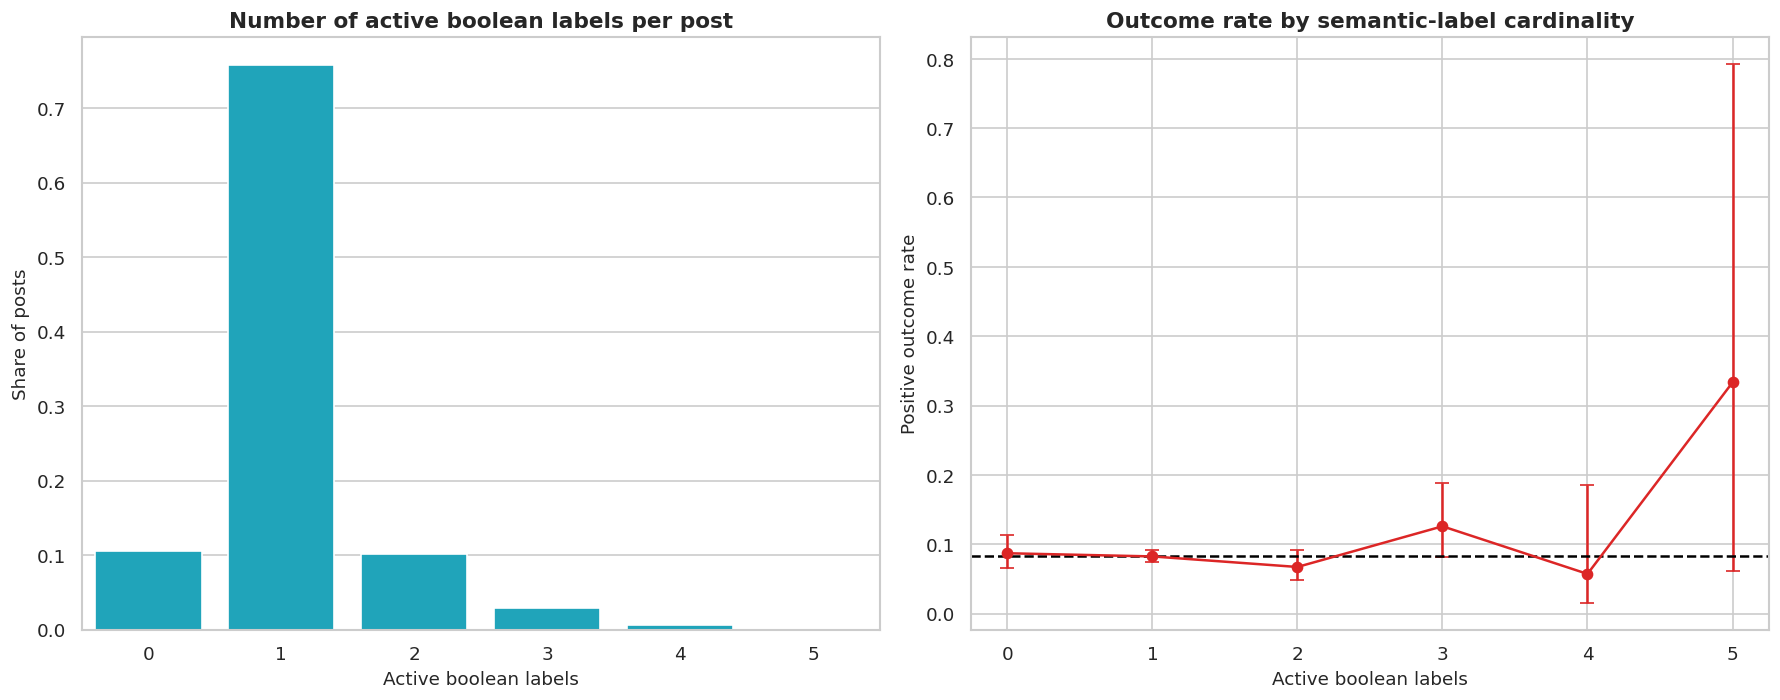

PosixPath('/content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/figures/09_boolean_cardinality_distribution_and_outcome.png')

In [119]:
# Cell 17: Label cardinality, primary/boolean consistency, and unusual combinations
cardinality = (
    analysis_df.groupby("boolean_count")
    .agg(rows=("post_id", "size"), positives=("y", "sum"), outcome_rate=("y", "mean"))
    .reset_index()
)
cardinality["share"] = cardinality["rows"] / len(analysis_df)
intervals = [wilson_interval(int(p), int(n)) for p, n in zip(cardinality["positives"], cardinality["rows"])]
cardinality["outcome_rate_ci_low"] = [x[0] for x in intervals]
cardinality["outcome_rate_ci_high"] = [x[1] for x in intervals]
save_table(cardinality, "17_boolean_cardinality")

combination = (
    analysis_df.groupby(BOOLEAN_LABEL_COLUMNS, dropna=False)
    .agg(rows=("post_id", "size"), positives=("y", "sum"), outcome_rate=("y", "mean"))
    .reset_index()
    .sort_values("rows", ascending=False)
)
combination["share"] = combination["rows"] / len(analysis_df)
combination["active_labels"] = combination.apply(
    lambda row: " + ".join([c for c in BOOLEAN_LABEL_COLUMNS if bool(row[c])]) or "none",
    axis=1,
)
save_table(combination, "18_all_observed_boolean_combinations", display_rows=30)

expected_primary_boolean = {
    "neutral_information_reference": "neutral_information_reference",
    "negative_grievance_reference": "negative_grievance",
    "audience_directed_engagement_reference": "audience_directed_engagement",
    "norm_violation_reference": "norm_violation_framing",
    "cross_community_comparison_reference": "cross_community_comparison",
    "supportive_or_defensive_reference": "supportive_or_defensive_framing",
}
consistency_rows = []
inconsistent_masks = {}
for primary, boolean_col in expected_primary_boolean.items():
    primary_mask = analysis_df["primary_label"].eq(primary)
    inconsistent = primary_mask & ~analysis_df[boolean_col]
    inconsistent_masks[f"{primary}_without_{boolean_col}"] = inconsistent
    consistency_rows.append({
        "rule": f"{primary} implies {boolean_col}=True",
        "primary_rows": int(primary_mask.sum()),
        "inconsistent_rows": int(inconsistent.sum()),
        "inconsistent_rate_within_primary": float(inconsistent.sum() / primary_mask.sum()) if primary_mask.sum() else np.nan,
    })

neutral_conflict_cols = [
    "negative_grievance", "audience_directed_engagement", "norm_violation_framing",
    "cross_community_comparison", "intergroup_boundary_framing",
]
neutral_mixed = analysis_df["primary_label"].eq("neutral_information_reference") & analysis_df[neutral_conflict_cols].any(axis=1)
inconsistent_masks["neutral_primary_with_conflict_boolean"] = neutral_mixed
consistency_rows.append({
    "rule": "neutral primary with at least one conflict-oriented boolean",
    "primary_rows": int(analysis_df["primary_label"].eq("neutral_information_reference").sum()),
    "inconsistent_rows": int(neutral_mixed.sum()),
    "inconsistent_rate_within_primary": float(neutral_mixed.mean()),
})
consistency_table = pd.DataFrame(consistency_rows).sort_values("inconsistent_rows", ascending=False)
save_table(consistency_table, "19_primary_boolean_consistency")

audit_samples = []
rng = np.random.default_rng(ANALYSIS_RANDOM_SEED)
sample_columns = [
    "post_id", "split", "y", "source_subreddit", "target_subreddit",
    "primary_label", *BOOLEAN_LABEL_COLUMNS, "short_reason",
    "title_for_llm", "body_for_llm", "text_quality_flag", "unk_ratio",
]
sample_columns = [c for c in sample_columns if c in analysis_df.columns]
for rule, mask in inconsistent_masks.items():
    candidates = analysis_df.loc[mask, sample_columns]
    if candidates.empty:
        continue
    sampled = candidates.sample(min(SAMPLE_ROWS_PER_GROUP, len(candidates)), random_state=int(rng.integers(1, 1_000_000)))
    sampled.insert(0, "audit_group", rule)
    audit_samples.append(sampled)
consistency_samples = pd.concat(audit_samples, ignore_index=True) if audit_samples else pd.DataFrame(columns=["audit_group", *sample_columns])
save_table(consistency_samples, "20_consistency_audit_sample_entries", parquet=False, display_rows=50)
consistency_samples.to_json(
    SAMPLE_DIR / "consistency_audit_sample_entries.jsonl",
    orient="records", lines=True, force_ascii=False,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=cardinality, x="boolean_count", y="share", color="#06B6D4", ax=axes[0])
axes[0].set_title("Number of active boolean labels per post")
axes[0].set_xlabel("Active boolean labels")
axes[0].set_ylabel("Share of posts")
axes[1].errorbar(
    cardinality["boolean_count"], cardinality["outcome_rate"],
    yerr=[
        cardinality["outcome_rate"] - cardinality["outcome_rate_ci_low"],
        cardinality["outcome_rate_ci_high"] - cardinality["outcome_rate"],
    ],
    fmt="-o", color="#DC2626", capsize=4,
)
axes[1].axhline(baseline_rate, color="black", linestyle="--")
axes[1].set_title("Outcome rate by semantic-label cardinality")
axes[1].set_xlabel("Active boolean labels")
axes[1].set_ylabel("Positive outcome rate")
save_figure("09_boolean_cardinality_distribution_and_outcome")


,split,rows,positives,outcome_rate
0,val,5259,434,0.082525


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/21_outcome_rate_by_split.csv


split,primary_label,val
0,neutral_information_reference,0.425556
1,negative_grievance_reference,0.207834
2,audience_directed_engagement_reference,0.185206
3,norm_violation_reference,0.008176
4,cross_community_comparison_reference,0.061038
5,supportive_or_defensive_reference,0.007226
6,unclear_or_other,0.104963


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/22_primary_prevalence_by_split.csv


split,label,val
0,negative_grievance,0.212398
1,audience_directed_engagement,0.228370
2,norm_violation_framing,0.029283
3,cross_community_comparison,0.116562
4,intergroup_boundary_framing,0.040882
5,supportive_or_defensive_framing,0.023579
6,neutral_information_reference,0.425556


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/23_boolean_prevalence_by_split.csv


,feature,feature_type,train_rate,val_rate,test_rate,max_minus_min,chi_square,p_value,cramers_v,fdr_bh_p_value
0,negative_grievance,boolean,NaN,0.212398,NaN,0.0,0.0,1.0,NaN,1.0
1,audience_directed_engagement,boolean,NaN,0.228370,NaN,0.0,0.0,1.0,NaN,1.0
2,norm_violation_framing,boolean,NaN,0.029283,NaN,0.0,0.0,1.0,NaN,1.0
3,cross_community_comparison,boolean,NaN,0.116562,NaN,0.0,0.0,1.0,NaN,1.0
4,intergroup_boundary_framing,boolean,NaN,0.040882,NaN,0.0,0.0,1.0,NaN,1.0
5,supportive_or_defensive_framing,boolean,NaN,0.023579,NaN,0.0,0.0,1.0,NaN,1.0
6,neutral_information_reference,boolean,NaN,0.425556,NaN,0.0,0.0,1.0,NaN,1.0


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/24_boolean_split_stability_tests.csv


""


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/25_primary_label_jensen_shannon_distance.csv


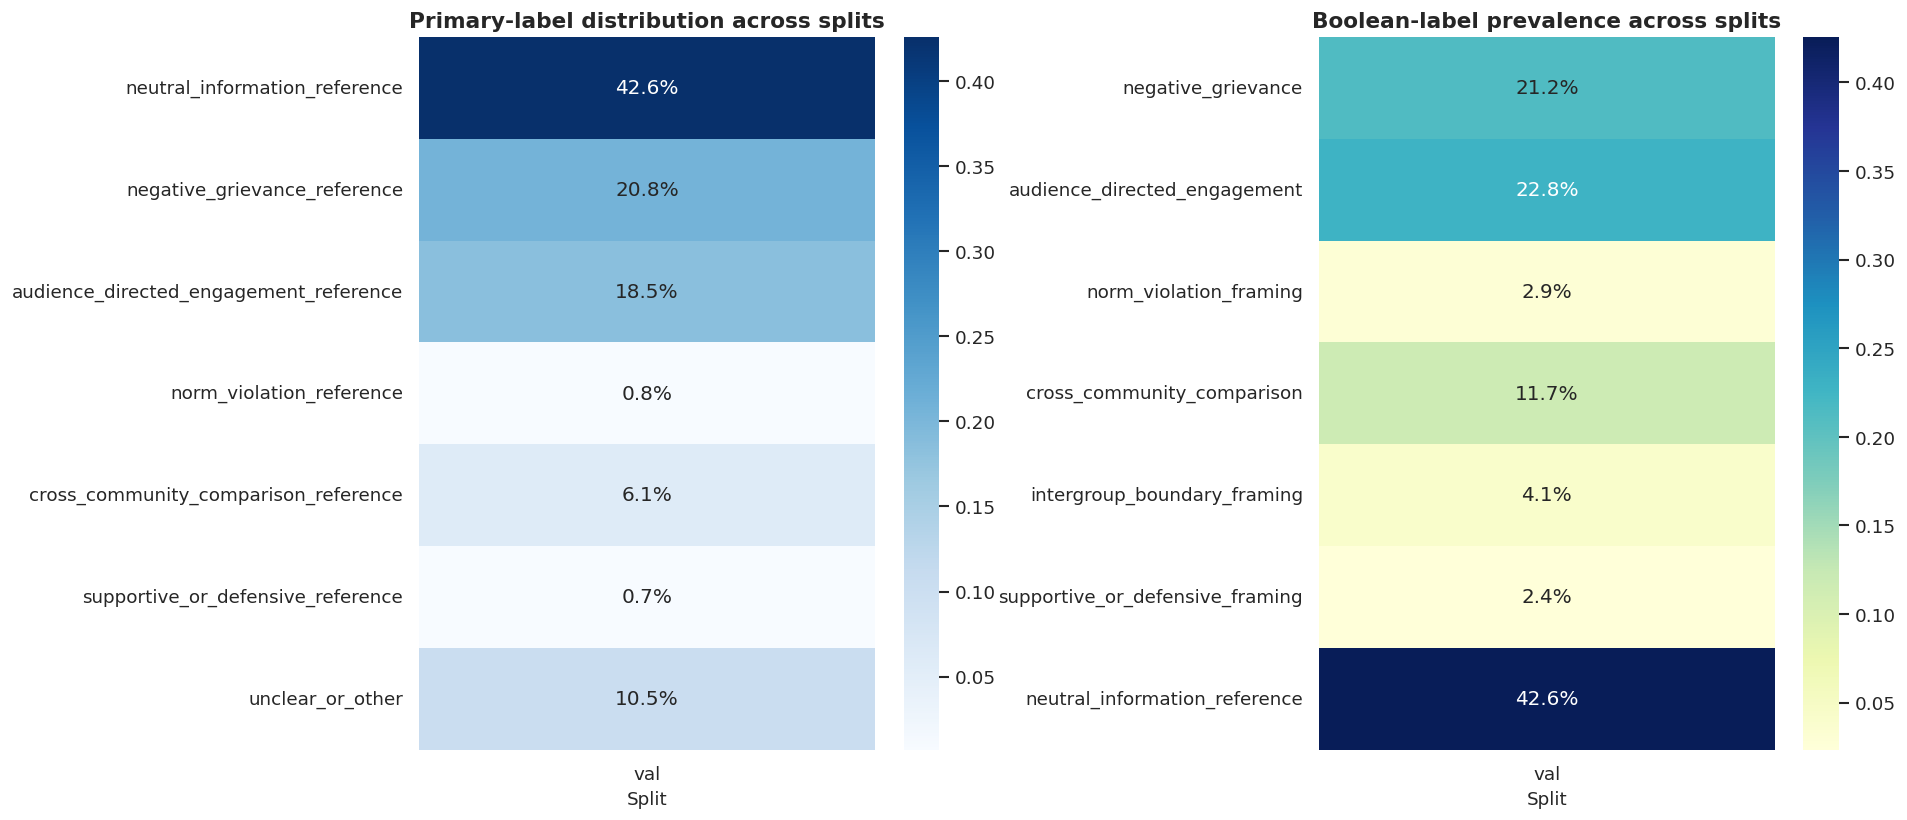

PosixPath('/content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/figures/10_split_distribution_stability_heatmaps.png')

In [120]:
# Cell 18: Train/validation/test stability and distribution-shift diagnostics
split_sizes = analysis_df["split"].value_counts()
split_primary = pd.crosstab(analysis_df["primary_label"], analysis_df["split"], normalize="columns").reindex(PRIMARY_LABELS).fillna(0)
split_boolean = analysis_df.groupby("split")[BOOLEAN_LABEL_COLUMNS].mean().T
split_outcome = analysis_df.groupby("split")["y"].agg(["count", "sum", "mean"]).reset_index()
split_outcome = split_outcome.rename(columns={"count": "rows", "sum": "positives", "mean": "outcome_rate"})

stability_rows = []
for label in BOOLEAN_LABEL_COLUMNS:
    rates = split_boolean.loc[label]
    contingency = pd.crosstab(analysis_df["split"], analysis_df[label])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    stability_rows.append({
        "feature": label,
        "feature_type": "boolean",
        "train_rate": rates.get("train", np.nan),
        "val_rate": rates.get("val", np.nan),
        "test_rate": rates.get("test", np.nan),
        "max_minus_min": rates.max() - rates.min(),
        "chi_square": chi2,
        "p_value": p_value,
        "cramers_v": cramers_v(contingency.values),
    })

stability = pd.DataFrame(stability_rows)
stability["fdr_bh_p_value"] = multipletests(stability["p_value"], method="fdr_bh")[1]
save_table(split_outcome, "21_outcome_rate_by_split")
save_table(split_primary.rename_axis("primary_label").reset_index(), "22_primary_prevalence_by_split")
save_table(split_boolean.rename_axis("label").reset_index(), "23_boolean_prevalence_by_split")
save_table(stability, "24_boolean_split_stability_tests")

js_rows = []
splits = [s for s in ("train", "val", "test") if s in split_primary.columns]
for i, left in enumerate(splits):
    for right in splits[i + 1:]:
        js_rows.append({
            "distribution": "primary_label",
            "split_a": left,
            "split_b": right,
            "jensen_shannon_distance": float(jensenshannon(split_primary[left], split_primary[right], base=2)),
        })
save_table(pd.DataFrame(js_rows), "25_primary_label_jensen_shannon_distance")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(split_primary, annot=True, fmt=".1%", cmap="Blues", ax=axes[0])
axes[0].set_title("Primary-label distribution across splits")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("")
sns.heatmap(split_boolean, annot=True, fmt=".1%", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Boolean-label prevalence across splits")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("")
save_figure("10_split_distribution_stability_heatmaps")


,text_quality_flag,rows,positives,outcome_rate,mean_unk_ratio,mean_text_chars,mean_boolean_count,share
0,maybe_usable_medium_unknown,231,18,0.077922,0.399916,80.580087,0.519481,0.043925
1,poor_high_unknown,14,1,0.071429,0.704248,111.142857,0.071429,0.002662
2,usable_low_unknown,5014,415,0.082768,0.071906,533.356003,1.105106,0.953413


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/26_text_quality_summary.csv


,unk_ratio_band,rows,outcome_rate,mean_boolean_count
0,<=5%,2537,0.06622,1.225069
1,5-20%,2173,0.101703,1.019328
2,20-40%,448,0.084821,0.680804
3,40-60%,87,0.068966,0.379310
4,>60%,14,0.071429,0.071429


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/27_unknown_token_ratio_bands.csv


,text_length_band,rows,min_chars,median_chars,max_chars,outcome_rate,mean_boolean_count,mean_reason_words
0,0,526,37,74.0,95,0.098859,0.530418,17.787072
1,1,526,95,115.0,138,0.096958,0.866920,18.980989
2,2,526,138,164.0,199,0.121673,0.990494,20.190114
3,3,526,199,235.0,273,0.089354,1.058935,21.591255
4,4,526,273,324.0,381,0.085551,1.163498,23.138783
5,5,525,382,452.0,527,0.070476,1.201905,23.994286
6,6,526,528,621.0,735,0.074144,1.254753,24.922053
7,7,526,735,893.0,1012,0.072243,1.228137,25.473384
8,8,526,1012,1070.0,1109,0.057034,1.197719,25.121673
9,9,526,1109,1161.0,1446,0.058935,1.273764,25.372624


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/28_text_length_deciles.csv


,prompt_provenance,rows,outcome_rate,mean_boolean_count,share
0,legacy_exact_reconstruction,5259,0.082525,1.076631,1.0


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/29_prompt_provenance_summary.csv


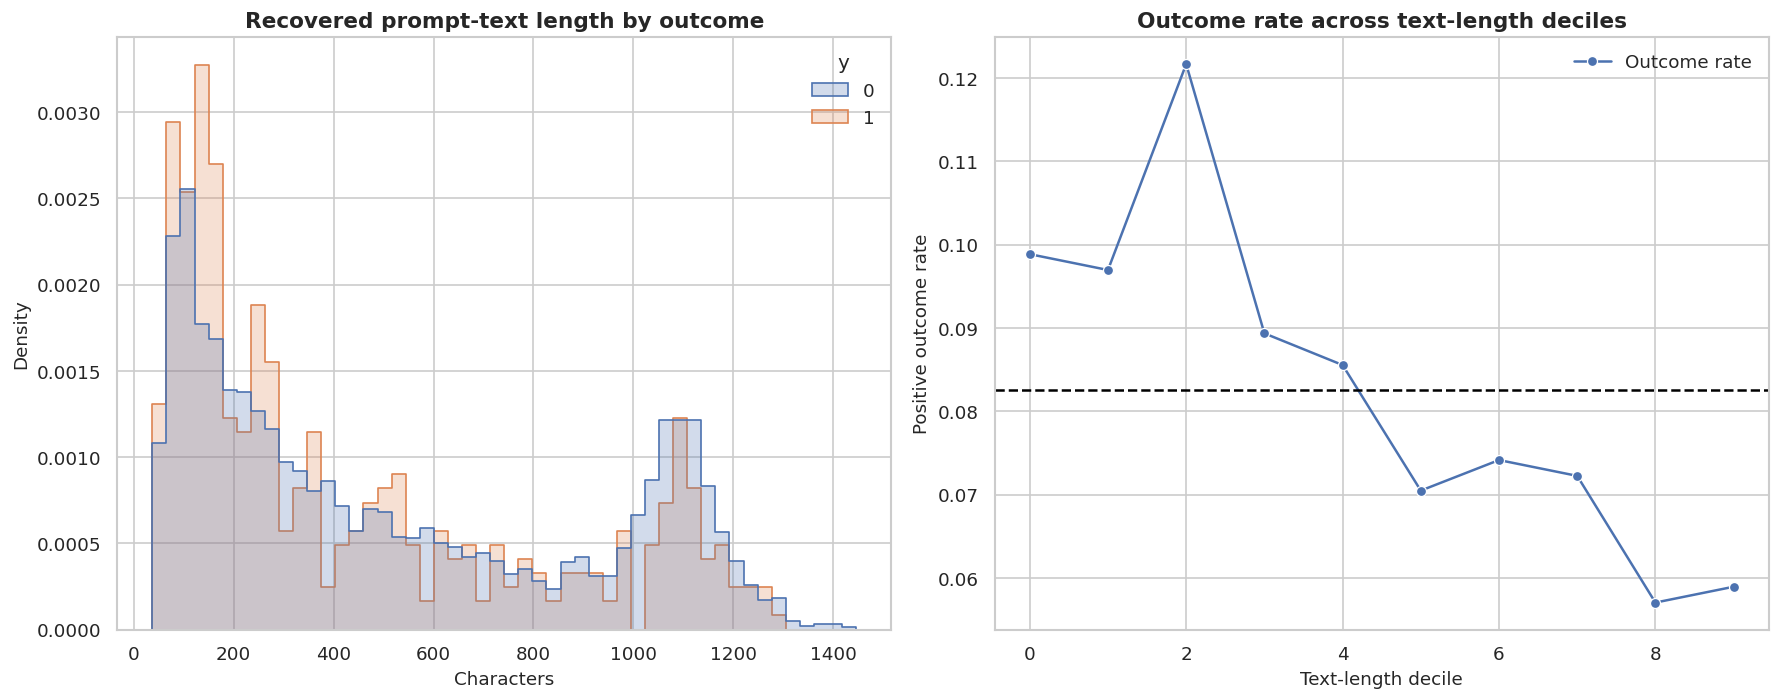

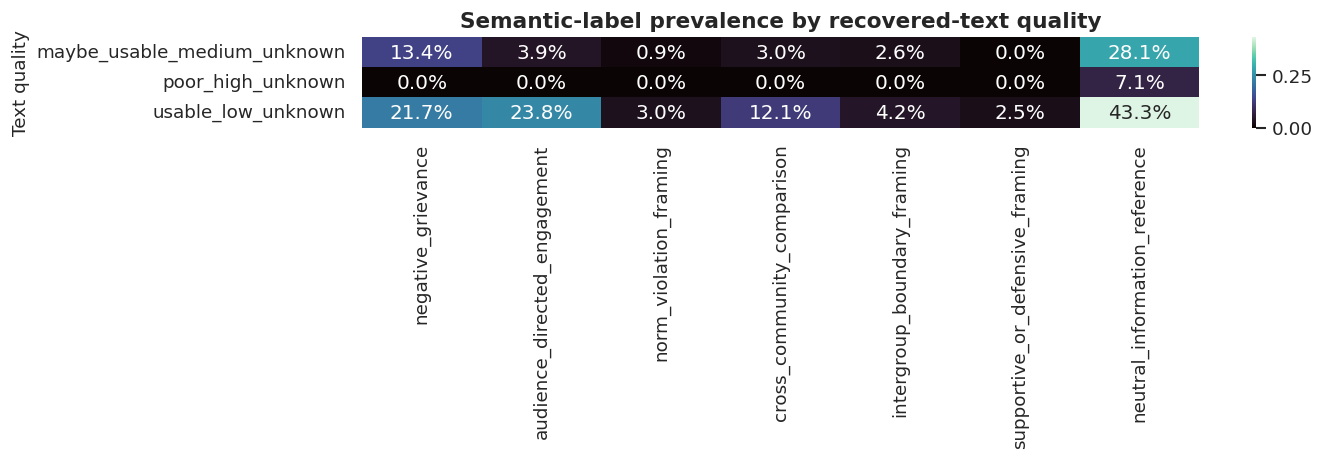

In [121]:
# Cell 19: Text quality, unknown-token ratio, prompt provenance, and length effects
quality_tables = []

if "text_quality_flag" in analysis_df:
    quality_summary = (
        analysis_df.groupby("text_quality_flag", dropna=False)
        .agg(
            rows=("post_id", "size"),
            positives=("y", "sum"),
            outcome_rate=("y", "mean"),
            mean_unk_ratio=("unk_ratio", "mean"),
            mean_text_chars=("text_chars", "mean"),
            mean_boolean_count=("boolean_count", "mean"),
        ).reset_index()
    )
    quality_summary["share"] = quality_summary["rows"] / len(analysis_df)
    save_table(quality_summary, "26_text_quality_summary")
    quality_tables.append(quality_summary)

if "unk_ratio" in analysis_df:
    analysis_df["unk_ratio_numeric"] = pd.to_numeric(analysis_df["unk_ratio"], errors="coerce")
    bins = [-np.inf, 0.05, 0.20, 0.40, 0.60, np.inf]
    labels = ["<=5%", "5-20%", "20-40%", "40-60%", ">60%"]
    analysis_df["unk_ratio_band"] = pd.cut(analysis_df["unk_ratio_numeric"], bins=bins, labels=labels)
    unk_summary = (
        analysis_df.groupby("unk_ratio_band", observed=False)
        .agg(rows=("post_id", "size"), outcome_rate=("y", "mean"), mean_boolean_count=("boolean_count", "mean"))
        .reset_index()
    )
    save_table(unk_summary, "27_unknown_token_ratio_bands")

analysis_df["text_length_band"] = pd.qcut(
    analysis_df["text_chars"].rank(method="first"),
    q=min(10, analysis_df["text_chars"].nunique()),
    labels=False,
    duplicates="drop",
)
text_length_summary = (
    analysis_df.groupby("text_length_band")
    .agg(
        rows=("post_id", "size"),
        min_chars=("text_chars", "min"),
        median_chars=("text_chars", "median"),
        max_chars=("text_chars", "max"),
        outcome_rate=("y", "mean"),
        mean_boolean_count=("boolean_count", "mean"),
        mean_reason_words=("reason_words", "mean"),
    ).reset_index()
)
save_table(text_length_summary, "28_text_length_deciles")

if "prompt_provenance" in analysis_df:
    provenance_summary = (
        analysis_df.groupby("prompt_provenance", dropna=False)
        .agg(rows=("post_id", "size"), outcome_rate=("y", "mean"), mean_boolean_count=("boolean_count", "mean"))
        .reset_index()
    )
    provenance_summary["share"] = provenance_summary["rows"] / len(analysis_df)
    save_table(provenance_summary, "29_prompt_provenance_summary")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(data=analysis_df, x="text_chars", bins=50, hue="y", element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Recovered prompt-text length by outcome")
axes[0].set_xlabel("Characters")
sns.lineplot(data=text_length_summary, x="text_length_band", y="outcome_rate", marker="o", ax=axes[1], label="Outcome rate")
axes[1].axhline(baseline_rate, color="black", linestyle="--", label="Overall baseline")
axes[1].set_title("Outcome rate across text-length deciles")
axes[1].set_xlabel("Text-length decile")
axes[1].set_ylabel("Positive outcome rate")
save_figure("11_text_length_distribution_and_outcome")

if "text_quality_flag" in analysis_df:
    quality_bool = analysis_df.groupby("text_quality_flag")[BOOLEAN_LABEL_COLUMNS].mean()
    plt.figure(figsize=(12, max(4, .7 * len(quality_bool))))
    sns.heatmap(quality_bool, annot=True, fmt=".1%", cmap="mako")
    plt.title("Semantic-label prevalence by recovered-text quality")
    plt.xlabel("")
    plt.ylabel("Text quality")
    save_figure("12_semantic_prevalence_by_text_quality")


,source_subreddit,rows,positives,outcome_rate,mean_boolean_count,share,outcome_lift
568,copypasta,92,2,0.021739,1.293478,0.017494,-0.060786
2067,shitliberalssay,88,8,0.090909,1.045455,0.016733,0.008384
2591,writingprompts,57,10,0.175439,0.719298,0.010839,0.092913
2216,subredditdrama,54,9,0.166667,1.018519,0.010268,0.084141
1713,outoftheloop,48,4,0.083333,0.895833,0.009127,0.000808
1254,justunsubbed,46,0,0.0,1.456522,0.008747,-0.082525
491,circlebroke,37,4,0.108108,1.594595,0.007036,0.025583
843,explainlikeimfive,31,6,0.193548,0.612903,0.005895,0.111023
2295,techsupport,27,0,0.0,1.074074,0.005134,-0.082525
2368,tipofmypenis,27,0,0.0,0.777778,0.005134,-0.082525


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/30_source_community_summary.csv


,target_subreddit,rows,positives,outcome_rate,mean_boolean_count,share,outcome_lift
131,askreddit,126,9,0.071429,0.920635,0.023959,-0.011097
2040,writingprompts,78,0,0.0,0.628205,0.014832,-0.082525
2031,worldnews,62,7,0.112903,1.193548,0.011789,0.030378
1012,leagueoflegends,55,4,0.072727,1.145455,0.010458,-0.009798
1881,todayilearned,54,6,0.111111,0.944444,0.010268,0.028586
727,funny,48,3,0.0625,0.958333,0.009127,-0.020025
1968,videos,43,4,0.093023,1.255814,0.008176,0.010498
1395,pics,42,2,0.047619,0.857143,0.007986,-0.034906
1841,the_donald,40,0,0.0,1.650000,0.007606,-0.082525
319,cfb,34,0,0.0,1.000000,0.006465,-0.082525


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/31_target_community_summary.csv


,source_subreddit,target_subreddit,rows,positives,outcome_rate,mean_boolean_count,outcome_lift
599,bluejackets,hockey,14,0,0.0,1.000000,-0.082525
2468,longhornnation,cfb,13,0,0.0,1.000000,-0.082525
1842,ggfreeforall,kotakuinaction,9,0,0.0,1.333333,-0.082525
2042,iama,books,9,1,0.111111,1.000000,0.028586
1255,destinythegame,crucibleplaybook,9,0,0.0,1.222222,-0.082525
3554,shakuswag,anime_irl,9,1,0.111111,0.444444,0.028586
3307,rantgrumps,gamegrumps,9,3,0.333333,1.222222,0.250808
1028,copypasta,askreddit,9,0,0.0,1.222222,-0.082525
1037,copypasta,cringeanarchy,8,1,0.125,1.625000,0.042475
1118,crucibleplaybook,destinythegame,7,0,0.0,1.000000,-0.082525


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/32_source_target_dyad_summary.csv


,source_subreddit,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference
0,askhistorians,0.000000,0.086957,0.000000,0.086957,0.000000,0.000000,0.869565
1,bestofoutrageculture,0.846154,0.038462,0.000000,0.153846,0.269231,0.000000,0.000000
2,bugs,0.157895,0.052632,0.000000,0.052632,0.000000,0.000000,0.736842
3,buildapc,0.000000,0.142857,0.000000,0.047619,0.000000,0.000000,0.904762
4,circlebroke,0.864865,0.081081,0.000000,0.378378,0.243243,0.027027,0.000000
5,circlebroke2,0.727273,0.045455,0.000000,0.227273,0.090909,0.000000,0.000000
6,circlejerkcopypasta,0.625000,0.125000,0.000000,0.208333,0.250000,0.166667,0.000000
7,conspiracy,0.800000,0.050000,0.150000,0.050000,0.050000,0.000000,0.100000
8,copypasta,0.695652,0.130435,0.032609,0.184783,0.163043,0.043478,0.043478
9,explainlikeimfive,0.000000,0.064516,0.000000,0.000000,0.000000,0.000000,0.548387


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/33_top_source_semantic_prevalence.csv


,target_subreddit,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference
0,askreddit,0.206349,0.206349,0.023810,0.047619,0.039683,0.015873,0.380952
1,books,0.153846,0.307692,0.000000,0.115385,0.000000,0.000000,0.461538
2,cfb,0.029412,0.000000,0.000000,0.235294,0.000000,0.000000,0.735294
3,destinythegame,0.000000,0.320000,0.000000,0.080000,0.000000,0.000000,0.680000
4,europe,0.240000,0.080000,0.200000,0.280000,0.080000,0.000000,0.240000
5,funny,0.333333,0.166667,0.020833,0.104167,0.041667,0.000000,0.291667
6,gaming,0.310345,0.206897,0.068966,0.241379,0.034483,0.000000,0.344828
7,hockey,0.107143,0.071429,0.000000,0.071429,0.000000,0.071429,0.750000
8,kotakuinaction,0.656250,0.187500,0.062500,0.312500,0.343750,0.000000,0.093750
9,leagueoflegends,0.181818,0.272727,0.018182,0.181818,0.036364,0.000000,0.454545


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/34_top_target_semantic_prevalence.csv


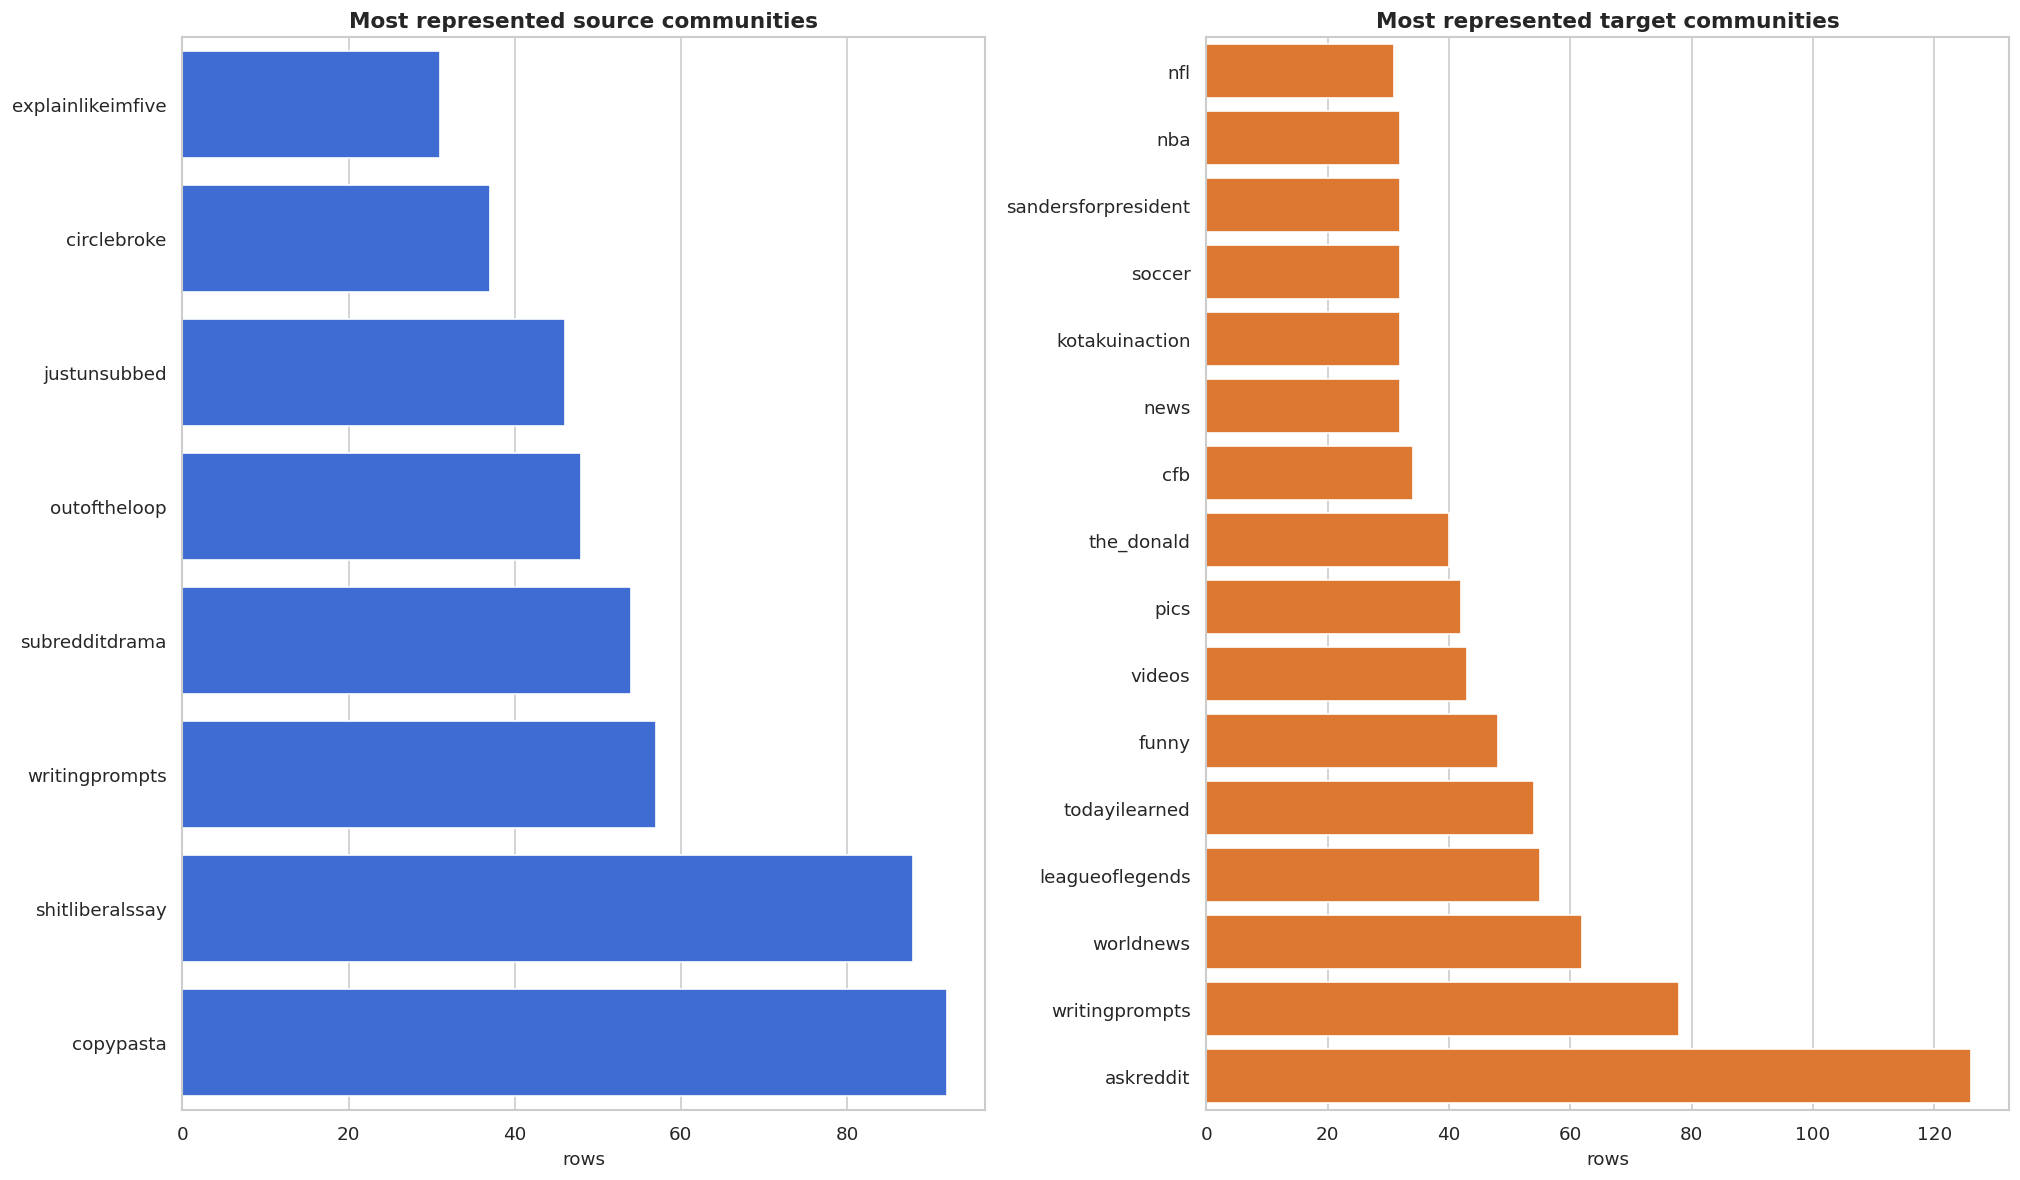

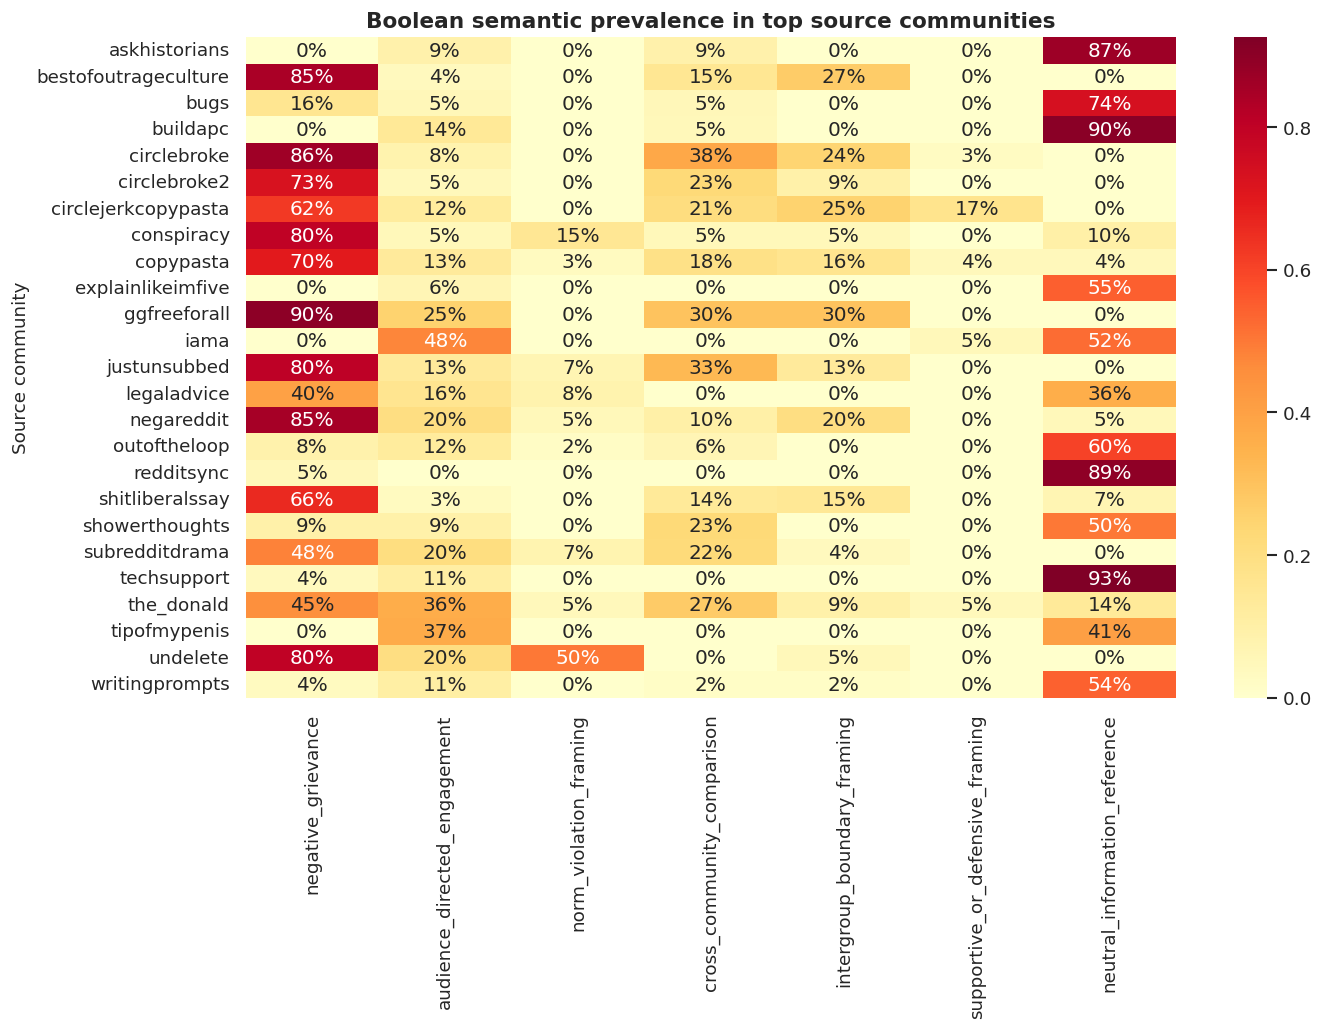

In [122]:
# Cell 20: Source, target, and source-target community findings
def community_summary(column, name):
    frame = (
        analysis_df.groupby(column, dropna=False)
        .agg(
            rows=("post_id", "size"),
            positives=("y", "sum"),
            outcome_rate=("y", "mean"),
            mean_boolean_count=("boolean_count", "mean"),
        )
        .reset_index()
    )
    frame["share"] = frame["rows"] / len(analysis_df)
    frame["outcome_lift"] = frame["outcome_rate"] - baseline_rate
    save_table(frame.sort_values("rows", ascending=False), name, display_rows=30)
    return frame

source_summary = community_summary("source_subreddit", "30_source_community_summary")
target_summary = community_summary("target_subreddit", "31_target_community_summary")
dyad_summary = (
    analysis_df.groupby(["source_subreddit", "target_subreddit"], dropna=False)
    .agg(
        rows=("post_id", "size"),
        positives=("y", "sum"),
        outcome_rate=("y", "mean"),
        mean_boolean_count=("boolean_count", "mean"),
    ).reset_index()
)
dyad_summary["outcome_lift"] = dyad_summary["outcome_rate"] - baseline_rate
save_table(dyad_summary.sort_values("rows", ascending=False), "32_source_target_dyad_summary", display_rows=40)

top_sources = source_summary.nlargest(TOP_COMMUNITIES, "rows")["source_subreddit"]
top_targets = target_summary.nlargest(TOP_COMMUNITIES, "rows")["target_subreddit"]
source_semantics = analysis_df.loc[analysis_df["source_subreddit"].isin(top_sources)].groupby("source_subreddit")[BOOLEAN_LABEL_COLUMNS].mean()
target_semantics = analysis_df.loc[analysis_df["target_subreddit"].isin(top_targets)].groupby("target_subreddit")[BOOLEAN_LABEL_COLUMNS].mean()
save_table(source_semantics.rename_axis("source_subreddit").reset_index(), "33_top_source_semantic_prevalence")
save_table(target_semantics.rename_axis("target_subreddit").reset_index(), "34_top_target_semantic_prevalence")

fig, axes = plt.subplots(1, 2, figsize=(17, 10))
source_plot = source_summary.loc[source_summary["rows"] >= MIN_COMMUNITY_SUPPORT].nlargest(20, "rows").sort_values("rows")
target_plot = target_summary.loc[target_summary["rows"] >= MIN_COMMUNITY_SUPPORT].nlargest(20, "rows").sort_values("rows")
sns.barplot(data=source_plot, x="rows", y="source_subreddit", color="#2563EB", ax=axes[0])
axes[0].set_title("Most represented source communities")
axes[0].set_ylabel("")
sns.barplot(data=target_plot, x="rows", y="target_subreddit", color="#F97316", ax=axes[1])
axes[1].set_title("Most represented target communities")
axes[1].set_ylabel("")
save_figure("13_top_source_and_target_communities")

eligible_dyads = dyad_summary.loc[dyad_summary["rows"] >= MIN_COMMUNITY_SUPPORT].copy()
if not eligible_dyads.empty:
    eligible_dyads["dyad"] = eligible_dyads["source_subreddit"].astype(str) + " -> " + eligible_dyads["target_subreddit"].astype(str)
    dyad_plot = eligible_dyads.nlargest(20, "outcome_rate").sort_values("outcome_rate")
    plt.figure(figsize=(13, 8))
    sns.barplot(data=dyad_plot, x="outcome_rate", y="dyad", color="#DC2626")
    plt.axvline(baseline_rate, color="black", linestyle="--", label="Overall baseline")
    plt.title(f"Highest-outcome source-target dyads (minimum {MIN_COMMUNITY_SUPPORT} rows)")
    plt.xlabel("Positive outcome rate")
    plt.ylabel("")
    plt.legend()
    save_figure("14_highest_outcome_source_target_dyads")

if not source_semantics.empty:
    plt.figure(figsize=(12, max(7, .35 * len(source_semantics))))
    sns.heatmap(source_semantics, cmap="YlOrRd", annot=True, fmt=".0%")
    plt.title("Boolean semantic prevalence in top source communities")
    plt.xlabel("")
    plt.ylabel("Source community")
    save_figure("15_top_source_community_semantic_heatmap")


,index,reason_words
0,count,5259.000000
1,mean,22.656969
2,std,6.424462
3,min,8.000000
4,5%,13.000000
5,25%,18.000000
6,50%,22.000000
7,75%,26.000000
8,95%,35.000000
9,99%,43.000000


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/35_short_reason_length_statistics.csv


,term,document_count,document_share
2108,post,4802,0.913101
951,engagement,1647,0.313177
522,community,1539,0.292641
1232,grievance,1233,0.234455
1854,negative,1155,0.219624
1416,information,1075,0.204411
1030,expressing,975,0.185396
1151,framing,960,0.182544
530,comparison,810,0.154022
184,asking,696,0.132345


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/36_short_reason_top_unigrams.csv


,term,document_count,document_share
2505,negative sentiment,607,0.115421
1395,expressing grievance,542,0.103061
2878,post expresses,490,0.093174
3915,target community,482,0.091652
1031,directing engagement,459,0.087279
2838,post asking,388,0.073778
2861,post describes,354,0.067313
2839,post asks,334,0.063510
1396,expressing grievances,269,0.051150
2964,post shares,244,0.046397


...

Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/39_representative_sample_entries.csv


,post_id,split,y,source_subreddit,target_subreddit,primary_label,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference,boolean_count,short_reason,title_for_llm,body_for_llm,text_quality_flag,unk_ratio
4548,5rarau,val,0,saudiarabia,economics,negative_grievance_reference,True,True,False,True,True,True,False,5,The post expresses personal distress and negat...,i am really getting depressed with reddit thes...,<UNK> saudiarabia <UNK> <UNK> hi all i am gues...,usable_low_unknown,0.020134
2772,4ph0zg,val,1,freefolk,subredditdrama,negative_grievance_reference,True,True,True,False,True,True,False,5,The post describes an attack on the source com...,i m blowing the horn free people under attack,<UNK> <UNK> ph zg <UNK> the https let me summa...,usable_low_unknown,0.017857
133,3hequ1,val,0,totesmessenger,tf2,negative_grievance_reference,True,True,True,True,True,False,False,5,The post complains about users from totesmesse...,about and,<UNK> <UNK> <UNK> <UNK> lately members of have...,usable_low_unknown,0.044444
2124,4eedl7,val,0,brokehugs,christianity,negative_grievance_reference,True,True,False,True,True,False,False,4,The post expresses outrage and ridicule toward...,church of norway approves blessings of same se...,<UNK> <UNK> <UNK> dolphins http if you want tl...,usable_low_unknown,0.006525
3782,59thar,val,1,the_donald,kotakuinaction,negative_grievance_reference,True,True,False,True,True,False,False,4,The post frames South Korea's political situat...,no coverage elsewhere major happenings in sout...,<UNK> the donald thar <UNK> if you re not up t...,usable_low_unknown,0.053892
3740,58ygy0,val,0,brookhavenms,wikileaks,negative_grievance_reference,True,True,False,True,True,False,False,4,The post alleges that the wikileaks subreddit ...,have we been compromised,<UNK> <UNK> <UNK> <UNK> many pol users and red...,usable_low_unknown,0.035714
2686,4o5dtm,val,0,askgaybros,the_donald,negative_grievance_reference,True,False,False,True,True,True,False,4,The post compares the_donald community positiv...,trump supporters showing their support for hum...,<UNK> <UNK> o dtm <UNK> https https i sli mg <...,usable_low_unknown,0.035971
3235,4yjy0b,val,0,ggfreeforall,kotakuinaction,negative_grievance_reference,True,True,False,True,True,False,False,4,The post discusses a thread in another communi...,the current top thread on kia is asking why a ...,<UNK> <UNK> <UNK> b <UNK> https the photo albu...,usable_low_unknown,0.018692
5236,67tr91,val,0,indianews,the_donald,negative_grievance_reference,True,False,True,True,True,False,False,4,The post expresses outrage and blames 'libtard...,bharat ho ya us libtards are insane,<UNK> <UNK> tr anon i was reading this ama of ...,usable_low_unknown,0.015873
680,3ppvs9,val,0,asianmasculinity,asianamerican,negative_grievance_reference,True,True,False,True,True,False,False,4,The post expresses strong negative sentiment t...,thank you for waking me up,<UNK> <UNK> ppvs <UNK> oh boy here we go first...,usable_low_unknown,0.004706


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/40_highest_semantic_cardinality_sample.csv


,post_id,split,y,source_subreddit,target_subreddit,primary_label,negative_grievance,audience_directed_engagement,norm_violation_framing,cross_community_comparison,intergroup_boundary_framing,supportive_or_defensive_framing,neutral_information_reference,boolean_count,short_reason,title_for_llm,body_for_llm,text_quality_flag,unk_ratio
13,3fwpno,val,0,truegaming,elitedangerous,neutral_information_reference,False,False,False,False,False,True,True,2,The post discusses features and issues in Elit...,payment models season passes and iterated feat...,<UNK> <UNK> <UNK> <UNK> tl dr do you play or f...,usable_low_unknown,0.006957
22,3fydns,val,0,justunsubbed,books,negative_grievance_reference,True,True,False,True,False,False,False,3,The user expresses frustration with the conten...,just unsubbed from,<UNK> <UNK> <UNK> <UNK> lately there have been...,usable_low_unknown,0.043011
139,3hhr52,val,1,randpaul,trees,audience_directed_engagement_reference,False,True,False,True,False,True,False,3,The post explicitly asks for followers from an...,help me get some followers over at,<UNK> <UNK> hhr <UNK> i posted this we need to...,usable_low_unknown,0.062500
186,3i69gv,val,0,laowinning,ccj888,negative_grievance_reference,True,True,True,True,False,False,False,4,The post accuses the target community of plagi...,tan guan plagiarizes <UNK> content to ccj,<UNK> <UNK> i gv <UNK> as you all know <UNK> i...,usable_low_unknown,0.058824
192,3i8m98,val,0,empirepowers_hre,empirepowers,audience_directed_engagement_reference,False,True,False,False,True,False,False,2,The post is a call for allies and permission t...,the free <UNK> of ulm seeks allies in a coalit...,<UNK> <UNK> hre i m <UNK> for reference we of ...,usable_low_unknown,0.023810
241,3j1qen,val,0,snakes,reptiles,audience_directed_engagement_reference,False,True,True,False,False,False,False,2,The user is offering a service to draw pets in...,i will draw your pet,<UNK> snakes j qen <UNK> here the original thr...,usable_low_unknown,0.009804
386,3ldtxb,val,0,karmacourt,asksocialscience,negative_grievance_reference,True,False,True,True,False,False,False,3,The post accuses the target subreddit of breac...,u <UNK> vs for breach of contract exe,<UNK> <UNK> <UNK> <UNK> so what happened lies ...,usable_low_unknown,0.028674
457,3meg5n,val,0,greenbaypackers,kansascitychiefs,audience_directed_engagement_reference,False,True,False,True,True,False,False,3,The post invites users from another subreddit ...,i a chiefs mod invite you to participate in ou...,<UNK> <UNK> meg n <UNK> we re having an erotic...,usable_low_unknown,0.015707
490,3myg6q,val,0,subredditcancer,undelete,negative_grievance_reference,True,False,True,False,True,False,False,3,The post complains about a thread removal due ...,removes my thread because sjw s complain to th...,<UNK> <UNK> myg q <UNK> thread where sjw s sta...,usable_low_unknown,0.060606
558,3nry5q,val,0,nygiants,nfl,negative_grievance_reference,True,True,True,True,False,False,False,4,The post complains about 'upvote parties' in t...,on these,<UNK> <UNK> nry q <UNK> was reading the weekly...,usable_low_unknown,0.036585


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/41_rare_semantic_combination_samples.csv


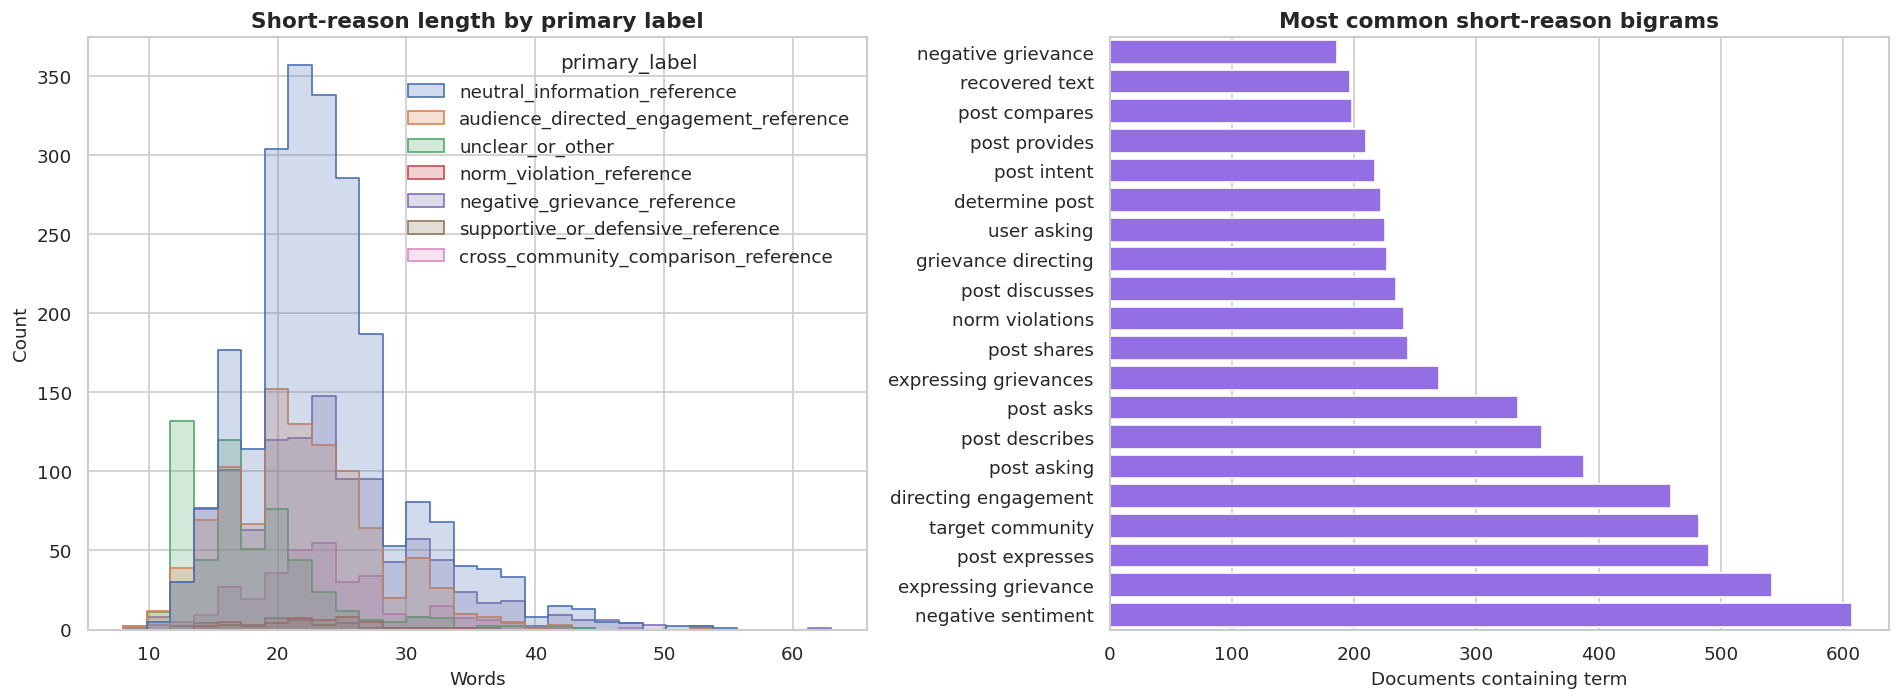

PosixPath('/content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/figures/16_short_reason_length_and_top_bigrams.png')

In [123]:
# Cell 21: Short-reason text analysis and representative sample entries
reason_stats = analysis_df["reason_words"].describe(percentiles=[.05, .25, .5, .75, .95, .99]).rename("reason_words").reset_index()
save_table(reason_stats, "35_short_reason_length_statistics")

def top_ngrams(texts, ngram_range=(1, 1), top_n=TOP_TERMS):
    texts = pd.Series(texts).fillna("").astype(str)
    if texts.str.strip().eq("").all():
        return pd.DataFrame(columns=["term", "document_count", "document_share"])
    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=ngram_range,
        min_df=max(2, int(len(texts) * .0002)),
        binary=True,
        max_features=5000,
    )
    try:
        matrix = vectorizer.fit_transform(texts)
    except ValueError:
        return pd.DataFrame(columns=["term", "document_count", "document_share"])
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    result = pd.DataFrame({
        "term": vectorizer.get_feature_names_out(),
        "document_count": counts,
    }).sort_values("document_count", ascending=False).head(top_n)
    result["document_share"] = result["document_count"] / len(texts)
    return result

reason_unigrams = top_ngrams(analysis_df["short_reason"], (1, 1))
reason_bigrams = top_ngrams(analysis_df["short_reason"], (2, 2))
save_table(reason_unigrams, "36_short_reason_top_unigrams")
save_table(reason_bigrams, "37_short_reason_top_bigrams")

term_by_primary = []
for label, group in analysis_df.groupby("primary_label"):
    terms = top_ngrams(group["short_reason"], (1, 2), top_n=15)
    terms.insert(0, "primary_label", label)
    term_by_primary.append(terms)
term_by_primary = pd.concat(term_by_primary, ignore_index=True)
save_table(term_by_primary, "38_short_reason_terms_by_primary_label", display_rows=60)

sample_columns = [
    "post_id", "split", "y", "source_subreddit", "target_subreddit",
    "primary_label", *BOOLEAN_LABEL_COLUMNS, "boolean_count",
    "short_reason", "title_for_llm", "body_for_llm",
    "text_quality_flag", "unk_ratio",
]
sample_columns = [c for c in sample_columns if c in analysis_df.columns]
samples = []
for primary, group in analysis_df.groupby("primary_label"):
    for outcome, subgroup in group.groupby("y"):
        if subgroup.empty:
            continue
        take = subgroup.sample(
            min(SAMPLE_ROWS_PER_GROUP, len(subgroup)),
            random_state=ANALYSIS_RANDOM_SEED,
        )[sample_columns].copy()
        take.insert(0, "sample_group", f"primary={primary} | y={outcome}")
        samples.append(take)
representative_samples = pd.concat(samples, ignore_index=True)
save_table(representative_samples, "39_representative_sample_entries", parquet=False, display_rows=100)
representative_samples.to_json(
    SAMPLE_DIR / "representative_sample_entries.jsonl",
    orient="records", lines=True, force_ascii=False,
)

highest_cardinality = analysis_df.nlargest(50, ["boolean_count", "reason_words"])[sample_columns]
save_table(highest_cardinality, "40_highest_semantic_cardinality_sample", parquet=False, display_rows=50)

rare_combinations = combination.loc[combination["rows"].between(2, 20), "active_labels"].head(20)
rare_samples = analysis_df.loc[
    analysis_df["active_labels"].isin(set(rare_combinations)),
    sample_columns,
].head(100)
save_table(rare_samples, "41_rare_semantic_combination_samples", parquet=False, display_rows=50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(data=analysis_df, x="reason_words", bins=30, hue="primary_label", element="step", ax=axes[0])
axes[0].set_title("Short-reason length by primary label")
axes[0].set_xlabel("Words")
top_terms_plot = reason_bigrams.head(20).sort_values("document_count")
sns.barplot(data=top_terms_plot, x="document_count", y="term", color="#8B5CF6", ax=axes[1])
axes[1].set_title("Most common short-reason bigrams")
axes[1].set_xlabel("Documents containing term")
axes[1].set_ylabel("")
save_figure("16_short_reason_length_and_top_bigrams")


,metric_rows,successful_rows,mean_latency_seconds,median_latency_seconds,p90_latency_seconds,p95_latency_seconds,p99_latency_seconds,mean_attempts,rows_with_retries,total_input_tokens,total_output_tokens,total_thoughts_tokens,total_billable_output_tokens,estimated_api_cost_usd,pricing_assumption_input_usd_per_million,pricing_assumption_output_and_thinking_usd_per_million
0,5259,5259,0.980848,0.802508,1.404458,2.059439,3.851609,1.011409,57,6222520,709384,0.0,709384.0,0.906006,0.1,0.4


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/42_api_resource_summary.csv


,timestamp_utc,requests,median_latency_seconds,p90_latency_seconds,mean_attempts,input_tokens,output_tokens,estimated_cost_usd
0,2026-06-22 20:00:00+00:00,1182,0.911042,2.521106,1.035533,1397711,159232,0.203464
1,2026-06-22 21:00:00+00:00,4077,0.780598,1.136117,1.004415,4824809,550152,0.702542


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables/43_api_metrics_hourly.csv


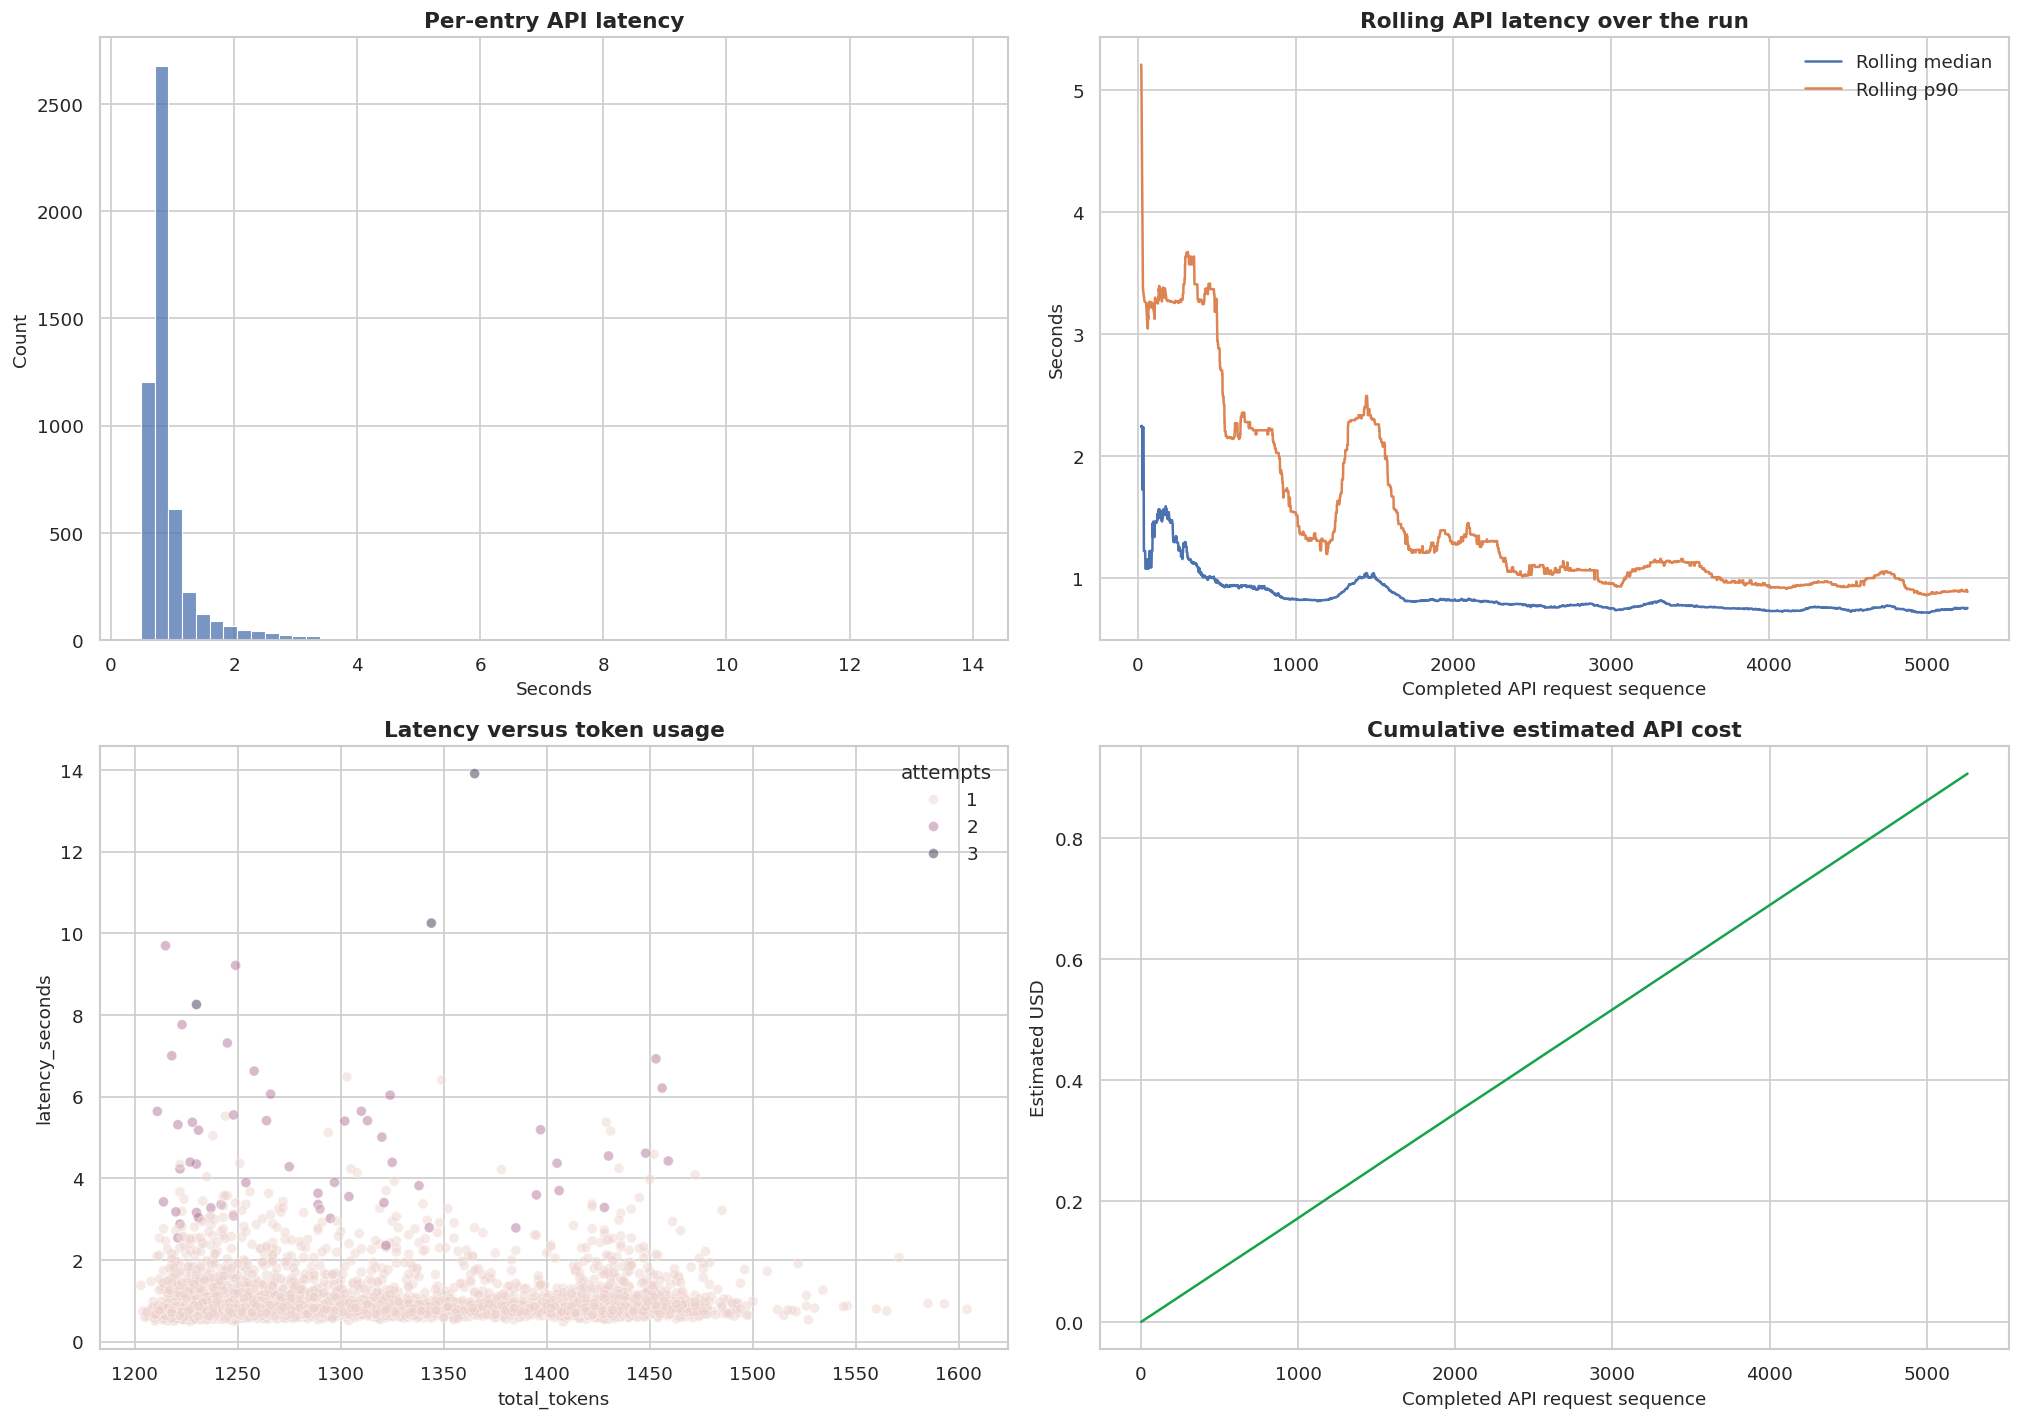

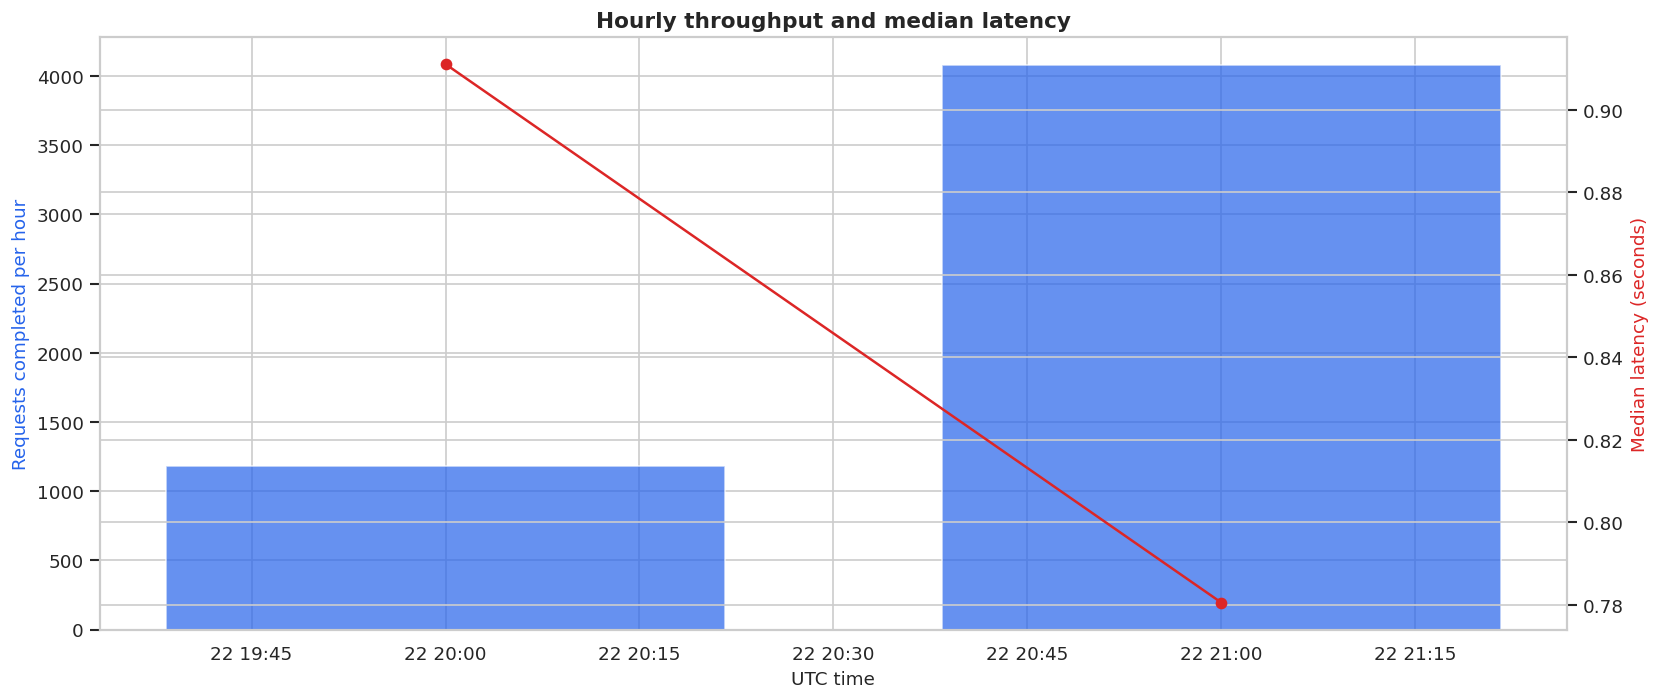

In [124]:
# Cell 22: API latency, throughput, retries, tokens, and estimated cost
metrics_path = cfg["resource_csv"]
if metrics_path.exists() and metrics_path.stat().st_size > 0:
    metrics_df = pd.read_csv(metrics_path, low_memory=False)
    metrics_df["timestamp_utc"] = pd.to_datetime(metrics_df["timestamp_utc"], errors="coerce", utc=True)
    numeric_metrics = [
        "attempts", "latency_seconds", "input_tokens", "output_tokens",
        "thoughts_tokens", "cached_content_tokens", "total_tokens",
        "rss_gb", "cpu_percent",
    ]
    for col in numeric_metrics:
        if col in metrics_df:
            metrics_df[col] = pd.to_numeric(metrics_df[col], errors="coerce")
    metrics_df = metrics_df.sort_values("timestamp_utc").reset_index(drop=True)
    metrics_df["sequence"] = np.arange(1, len(metrics_df) + 1)
    metrics_df["rolling_latency_median_250"] = metrics_df["latency_seconds"].rolling(250, min_periods=20).median()
    metrics_df["rolling_latency_p90_250"] = metrics_df["latency_seconds"].rolling(250, min_periods=20).quantile(.9)
    metrics_df["estimated_input_cost_usd"] = metrics_df["input_tokens"].fillna(0) / 1_000_000 * GEMINI_INPUT_USD_PER_MILLION
    metrics_df["billable_output_tokens"] = (
        metrics_df["output_tokens"].fillna(0)
        + metrics_df["thoughts_tokens"].fillna(0)
    )
    metrics_df["estimated_output_cost_usd"] = metrics_df["billable_output_tokens"] / 1_000_000 * GEMINI_OUTPUT_USD_PER_MILLION
    metrics_df["estimated_total_cost_usd"] = metrics_df["estimated_input_cost_usd"] + metrics_df["estimated_output_cost_usd"]
    metrics_df["cumulative_estimated_cost_usd"] = metrics_df["estimated_total_cost_usd"].cumsum()

    metric_summary = pd.DataFrame([{
        "metric_rows": len(metrics_df),
        "successful_rows": int(metrics_df["success"].astype(str).str.lower().eq("true").sum()),
        "mean_latency_seconds": metrics_df["latency_seconds"].mean(),
        "median_latency_seconds": metrics_df["latency_seconds"].median(),
        "p90_latency_seconds": metrics_df["latency_seconds"].quantile(.90),
        "p95_latency_seconds": metrics_df["latency_seconds"].quantile(.95),
        "p99_latency_seconds": metrics_df["latency_seconds"].quantile(.99),
        "mean_attempts": metrics_df["attempts"].mean(),
        "rows_with_retries": int(metrics_df["attempts"].gt(1).sum()),
        "total_input_tokens": metrics_df["input_tokens"].sum(),
        "total_output_tokens": metrics_df["output_tokens"].sum(),
        "total_thoughts_tokens": metrics_df["thoughts_tokens"].sum(),
        "total_billable_output_tokens": metrics_df["billable_output_tokens"].sum(),
        "estimated_api_cost_usd": metrics_df["estimated_total_cost_usd"].sum(),
        "pricing_assumption_input_usd_per_million": GEMINI_INPUT_USD_PER_MILLION,
        "pricing_assumption_output_and_thinking_usd_per_million": GEMINI_OUTPUT_USD_PER_MILLION,
    }])
    save_table(metric_summary, "42_api_resource_summary")

    hourly = (
        metrics_df.dropna(subset=["timestamp_utc"])
        .set_index("timestamp_utc")
        .resample("1h")
        .agg(
            requests=("post_id", "size"),
            median_latency_seconds=("latency_seconds", "median"),
            p90_latency_seconds=("latency_seconds", lambda s: s.quantile(.9)),
            mean_attempts=("attempts", "mean"),
            input_tokens=("input_tokens", "sum"),
            output_tokens=("output_tokens", "sum"),
            estimated_cost_usd=("estimated_total_cost_usd", "sum"),
        )
        .reset_index()
    )
    save_table(hourly, "43_api_metrics_hourly")

    fig, axes = plt.subplots(2, 2, figsize=(17, 12))
    sns.histplot(data=metrics_df, x="latency_seconds", bins=60, ax=axes[0, 0])
    axes[0, 0].set_title("Per-entry API latency")
    axes[0, 0].set_xlabel("Seconds")
    axes[0, 1].plot(metrics_df["sequence"], metrics_df["rolling_latency_median_250"], label="Rolling median")
    axes[0, 1].plot(metrics_df["sequence"], metrics_df["rolling_latency_p90_250"], label="Rolling p90")
    axes[0, 1].set_title("Rolling API latency over the run")
    axes[0, 1].set_xlabel("Completed API request sequence")
    axes[0, 1].set_ylabel("Seconds")
    axes[0, 1].legend()
    sns.scatterplot(
        data=metrics_df.sample(min(10000, len(metrics_df)), random_state=ANALYSIS_RANDOM_SEED),
        x="total_tokens", y="latency_seconds", hue="attempts", alpha=.45, ax=axes[1, 0],
    )
    axes[1, 0].set_title("Latency versus token usage")
    axes[1, 1].plot(metrics_df["sequence"], metrics_df["cumulative_estimated_cost_usd"], color="#16A34A")
    axes[1, 1].set_title("Cumulative estimated API cost")
    axes[1, 1].set_xlabel("Completed API request sequence")
    axes[1, 1].set_ylabel("Estimated USD")
    save_figure("17_api_latency_tokens_retries_and_cost")

    if not hourly.empty:
        fig, ax1 = plt.subplots(figsize=(14, 6))
        ax1.bar(hourly["timestamp_utc"], hourly["requests"], width=.03, color="#2563EB", alpha=.7)
        ax1.set_ylabel("Requests completed per hour", color="#2563EB")
        ax2 = ax1.twinx()
        ax2.plot(hourly["timestamp_utc"], hourly["median_latency_seconds"], color="#DC2626", marker="o")
        ax2.set_ylabel("Median latency (seconds)", color="#DC2626")
        ax1.set_title("Hourly throughput and median latency")
        ax1.set_xlabel("UTC time")
        save_figure("18_hourly_throughput_and_latency")
else:
    metrics_df = pd.DataFrame()
    print("No resource_metrics.csv is available. Legacy-imported rows normally have no API timing data.")


In [125]:
# Cell 23: Automatic key findings, Excel workbook, manifest, and report
key_findings = {
    "generated_at_utc": utc_now(),
    "provider": "gemini_2_5_flash_lite",
    "model": MODEL_ID,
    "annotated_rows": int(len(analysis_df)),
    "queue_rows": int(len(queue_df)),
    "coverage": float(len(analysis_df) / len(queue_df)),
    "positive_outcome_rate": baseline_rate,
    "most_common_primary_label": str(primary_counts.loc[primary_counts["rows"].idxmax(), "primary_label"]),
    "most_common_primary_label_share": float(primary_counts["share"].max()),
    "highest_outcome_primary_label": str(primary_counts.loc[primary_counts["outcome_rate"].idxmax(), "primary_label"]),
    "highest_outcome_primary_label_rate": float(primary_counts["outcome_rate"].max()),
    "most_prevalent_boolean_label": str(boolean_prevalence.iloc[0]["label"]),
    "most_prevalent_boolean_rate": float(boolean_prevalence.iloc[0]["prevalence"]),
    "largest_positive_boolean_risk_difference_label": str(boolean_associations.iloc[0]["label"]),
    "largest_positive_boolean_risk_difference": float(boolean_associations.iloc[0]["risk_difference"]),
    "largest_negative_boolean_risk_difference_label": str(boolean_associations.iloc[-1]["label"]),
    "largest_negative_boolean_risk_difference": float(boolean_associations.iloc[-1]["risk_difference"]),
    "primary_label_chi_square_p_value": float(primary_test.iloc[0]["p_value"]),
    "primary_label_cramers_v": float(primary_test.iloc[0]["cramers_v"]),
    "tables_created": len(table_registry),
    "figures_created": len(figure_registry),
}
atomic_json_dump(key_findings, REPORT_DIR / "key_findings.json")

# Excel workbook: each registered table gets a worksheet with a safe, unique name.
excel_path = ANALYSIS_DIR / "gemini_comprehensive_semantic_results.xlsx"
used_sheet_names = set()
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for name, frame in table_registry.items():
        base = re.sub(r"[^A-Za-z0-9_]", "_", name)[:31] or "table"
        sheet = base
        counter = 2
        while sheet in used_sheet_names:
            suffix = f"_{counter}"
            sheet = base[:31 - len(suffix)] + suffix
            counter += 1
        used_sheet_names.add(sheet)
        export_frame = frame.copy()
        for col in export_frame.columns:
            if pd.api.types.is_datetime64_any_dtype(export_frame[col]):
                export_frame[col] = export_frame[col].astype(str)
        export_frame.to_excel(writer, sheet_name=sheet, index=False)

figure_index = pd.DataFrame(figure_registry)
figure_index.to_csv(ANALYSIS_DIR / "figure_index.csv", index=False)
table_index = pd.DataFrame([
    {"name": name, "rows": len(frame), "columns": len(frame.columns), "csv": str(TABLE_DIR / f"{name}.csv")}
    for name, frame in table_registry.items()
])
table_index.to_csv(ANALYSIS_DIR / "table_index.csv", index=False)

report_lines = [
    "# Gemini 2.5 Flash-Lite semantic enhancement: comprehensive results",
    "",
    f"Generated: {key_findings['generated_at_utc']}",
    f"Coverage: {key_findings['annotated_rows']:,}/{key_findings['queue_rows']:,} ({key_findings['coverage']:.2%})",
    f"Positive outcome rate: {key_findings['positive_outcome_rate']:.2%}",
    "",
    "## Key findings",
    "",
    f"- Most common primary label: `{key_findings['most_common_primary_label']}` ({key_findings['most_common_primary_label_share']:.2%}).",
    f"- Highest-outcome primary label: `{key_findings['highest_outcome_primary_label']}` ({key_findings['highest_outcome_primary_label_rate']:.2%}).",
    f"- Most prevalent boolean label: `{key_findings['most_prevalent_boolean_label']}` ({key_findings['most_prevalent_boolean_rate']:.2%}).",
    f"- Largest positive boolean risk difference: `{key_findings['largest_positive_boolean_risk_difference_label']}` ({key_findings['largest_positive_boolean_risk_difference']:+.2%}).",
    f"- Largest negative boolean risk difference: `{key_findings['largest_negative_boolean_risk_difference_label']}` ({key_findings['largest_negative_boolean_risk_difference']:+.2%}).",
    f"- Primary-label association with outcome: Cramer's V={key_findings['primary_label_cramers_v']:.4f}, p={key_findings['primary_label_chi_square_p_value']:.4g}.",
    "",
    "## Outputs",
    "",
    f"- {len(table_registry)} detailed tables in `tables/`",
    f"- {len(figure_registry)} figures in PNG and PDF in `figures/`",
    "- Representative and consistency-audit entries in `sample_entries/`",
    "- Full Excel workbook: `gemini_comprehensive_semantic_results.xlsx`",
    "",
    "## Interpretation note",
    "",
    "These are descriptive and exploratory associations. Statistical significance does not imply causality, "
    "and held-out test results should not guide downstream model selection.",
]
report_path = REPORT_DIR / "comprehensive_results_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

analysis_manifest = {
    **key_findings,
    "analysis_directory": str(ANALYSIS_DIR),
    "excel_workbook": str(excel_path),
    "report": str(report_path),
    "table_index": str(ANALYSIS_DIR / "table_index.csv"),
    "figure_index": str(ANALYSIS_DIR / "figure_index.csv"),
    "sample_directory": str(SAMPLE_DIR),
    "pricing_note": (
        "Estimated API cost uses configurable notebook constants. "
        "Verify current Gemini pricing before reporting costs."
    ),
}
atomic_json_dump(analysis_manifest, ANALYSIS_DIR / "analysis_manifest.json")

display(Markdown("\n".join(report_lines)))
print("\nComprehensive analysis complete.")
print("Excel workbook:", excel_path)
print("Report:", report_path)
print("Tables:", TABLE_DIR)
print("Figures:", FIGURE_DIR)
print("Samples:", SAMPLE_DIR)


# Gemini 2.5 Flash-Lite semantic enhancement: comprehensive results

Generated: 2026-06-22T22:00:15.037494+00:00
Coverage: 5,259/116,224 (4.52%)
Positive outcome rate: 8.25%

## Key findings

- Most common primary label: `neutral_information_reference` (42.56%).
- Highest-outcome primary label: `norm_violation_reference` (13.95%).
- Most prevalent boolean label: `neutral_information_reference` (42.56%).
- Largest positive boolean risk difference: `supportive_or_defensive_framing` (+6.41%).
- Largest negative boolean risk difference: `neutral_information_reference` (-3.01%).
- Primary-label association with outcome: Cramer's V=0.0667, p=0.0006726.

## Outputs

- 43 detailed tables in `tables/`
- 18 figures in PNG and PDF in `figures/`
- Representative and consistency-audit entries in `sample_entries/`
- Full Excel workbook: `gemini_comprehensive_semantic_results.xlsx`

## Interpretation note

These are descriptive and exploratory associations. Statistical significance does not imply causality, and held-out test results should not guide downstream model selection.


Comprehensive analysis complete.
Excel workbook: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/gemini_comprehensive_semantic_results.xlsx
Report: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/reports/comprehensive_results_report.md
Tables: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/tables
Figures: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/gemini_2_5_flash_lite/comprehensive_analysis/figures
Samples: /content/drive/MyDrive/csonet2026_conflict_predict

In [126]:
# Cell 24: Final Gemini completion and provenance audit
provider = PROVIDER_ID
cfg = PROVIDERS[provider]
completed, malformed = completed_ids_for_provider(provider)
raw_rows, _ = read_valid_jsonl(cfg["raw_jsonl"])
verified_rows = [row for row in raw_rows if is_verified_success_record(row)]
preserved_legacy_ids = {
    normalize_post_id(row.get("post_id"))
    for row in verified_rows
    if row.get("imported_from_legacy") is True
}
preserved_legacy_ids.discard(None)
newly_generated_ids = {
    normalize_post_id(row.get("post_id"))
    for row in verified_rows
    if not row.get("imported_from_legacy", False)
}
newly_generated_ids.discard(None)

audit = {
    "provider": provider,
    "model": cfg["model"],
    "completed_verified_unique": len(completed),
    "preserved_legacy_unique": len(preserved_legacy_ids),
    "newly_generated_unique": len(newly_generated_ids),
    "remaining": EXPECTED_TOTAL - len(completed),
    "malformed_raw_lines": len(malformed),
    "complete": len(completed) == EXPECTED_TOTAL,
    "queue_rows": EXPECTED_TOTAL,
    "queue_sha256": queue_fingerprint,
    "system_prompt_sha256": SYSTEM_PROMPT_SHA256,
    "prompt_audit_sha256": PROMPT_AUDIT_SHA256,
    "prompt_equivalence_passed": PROMPT_EQUIVALENCE_AUDIT["passed"],
    "unverified_success_rows_excluded": sum(
        row.get("success") is True and not is_verified_success_record(row)
        for row in raw_rows
    ),
    "generated_at_utc": utc_now(),
}
atomic_json_dump(audit, RUN_ROOT / "gemini_only_full_dataset_audit.json")
display(pd.DataFrame([audit]))

if audit["complete"]:
    print(
        f"SUCCESS: Gemini 2.5 Flash-Lite completed verified semantic enhancement "
        f"for all {EXPECTED_TOTAL:,} entries."
    )
else:
    print(
        f"Gemini is incomplete: {audit['completed_verified_unique']:,} verified "
        f"completed and {audit['remaining']:,} remaining. Rerun Cell 10 to resume."
    )


,provider,model,completed_verified_unique,preserved_legacy_unique,newly_generated_unique,remaining,malformed_raw_lines,complete,queue_rows,queue_sha256,system_prompt_sha256,prompt_audit_sha256,prompt_equivalence_passed,unverified_success_rows_excluded,generated_at_utc
0,gemini_2_5_flash_lite,gemini-2.5-flash-lite,5259,0,5259,110965,0,False,116224,2e7b7615c68d0489b1ce5bfa01c315781b3d1194247a9f...,e29b7c5ef63ac511bb1e0c4cd43599acef3f7e230f74f6...,aba18f10e93f969e4a2fb692f8c579a6120c036d66c890...,True,0,2026-06-22T22:00:16.486002+00:00


Gemini is incomplete: 5,259 verified completed and 110,965 remaining. Rerun Cell 10 to resume.


## Output location

Gemini files are saved under the isolated directory:

```text
/content/drive/MyDrive/csonet2026_conflict_prediction/results/
llm_semantic_enrichment_full_dataset_gemini25flashlite_legacy_exact_detailed_results/
gemini_2_5_flash_lite/
```

This directory does not overlap the GPT output directory.

Important outputs:

- `semantic_labels_raw.jsonl`: append-only raw records
- `semantic_label_errors.jsonl`: failed rows and API errors
- `semantic_labels_parsed.(csv|parquet|pkl)`: verified parsed annotations
- `semantic_features.(csv|parquet|pkl)`: training-ready semantic features
- `resource_metrics.csv`: latency, retries, tokens, CPU and memory
- `manifest.json`: exact prompt, hash, schema, model, queue, audit and paths
- `legacy_provenance_audit/`: preserved/rejected/questionable legacy reports
- `comprehensive_analysis/`: detailed tables, figures, samples and reports

Do not run two notebooks concurrently against this same Gemini-only directory.

**Runtime:** Google Colab CPU with High-RAM. A GPU is unnecessary.
